# Hybrid framework dqn_v2 - Testing

In [1]:
METHOD = "HYBRID"

In [2]:
import os
import io
import random
import math
import torch
import json
import pickle
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter
from ultralytics import YOLO 
import torch.nn.functional as F
from tqdm import tqdm
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import probtools
from mylib import dqn_v2
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [4]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[56] 
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]

TARGET_OBJECT_CLASS_ID = indoor_objects.index(TARGET_OBJECT)

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

In [5]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free and occupied cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
grid_occ_cells, map_occ_cells, world_occ_coords = myutils.find_occupied_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

# Build binary int grid map (0: free, 1: occupied)
grid_binary_map = np.zeros(grid_map.shape[:2], dtype=np.int32)
for x, y in grid_occ_cells:
	if 0 <= x < grid_binary_map.shape[0] and 0 <= y < grid_binary_map.shape[1]:
		grid_binary_map[x, y] = 1

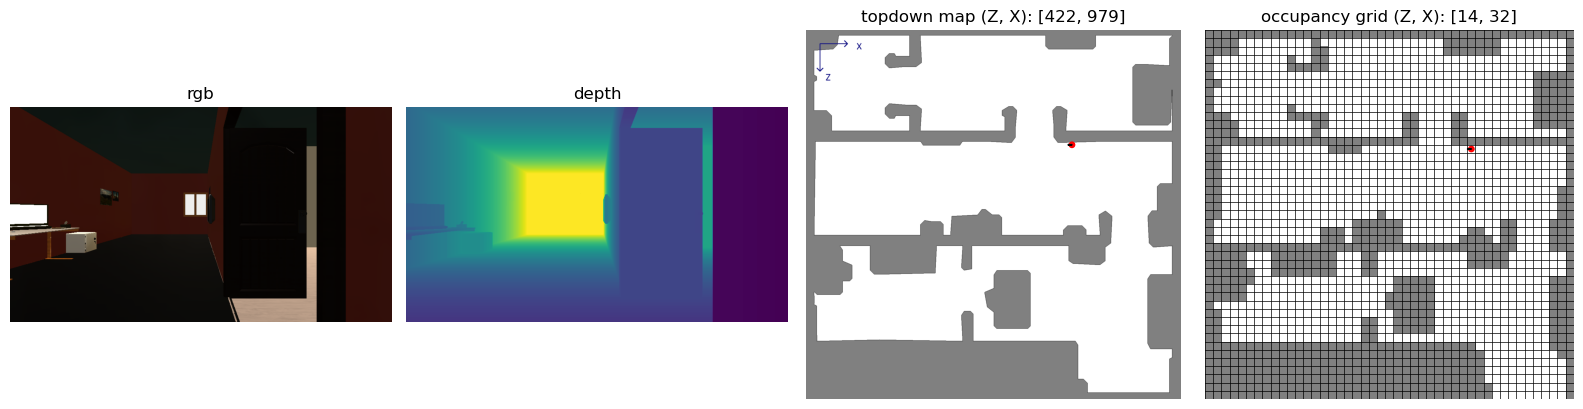

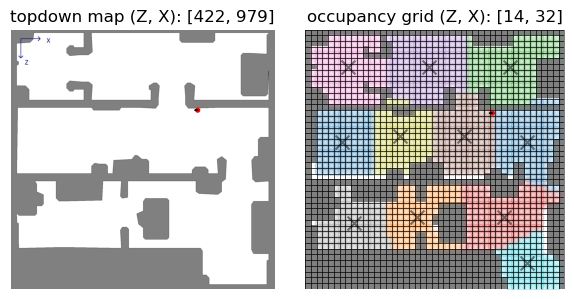

In [6]:
# Simulation parameters
MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform

# Define initial clusters
num_clusters = simtools.num_cluster_centers(num_free_cells, max_clusters=num_free_cells)
cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
cluster_centers_copy = cluster_centers.copy()

# Initialize belief map: NUM_CLASSES + 1 for the background 
belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb, depth = observations["color_sensor"], observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)
simtools.display_topdown_maps_with_clusters(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, cluster_map, cluster_centers)

In [7]:
starting_grid_positions = [[24, 25], [29, 36], [19, 27], [23, 26], [8, 20], [16, 30], [9, 15], [27, 41], [7, 30], [9, 1], [2, 28], [32, 14], [4, 38], [21, 35], [15, 12], [7, 34], [35, 35], [9, 5], [33, 20], [41, 38], [2, 25], [19, 5], [18, 3], [20, 39], [8, 12], [18, 37], [3, 37], [17, 39], [31, 36], [3, 25], [4, 32], [14, 30], [34, 37], [34, 36], [3, 1], [5, 19], [30, 14], [19, 17], [17, 7], [28, 24], [11, 10], [10, 34], [33, 14], [30, 13], [18, 21], [24, 35], [3, 39], [36, 21], [42, 39], [12, 27], [19, 31], [11, 28], [11, 15], [8, 14], [4, 33], [18, 16], [23, 24], [12, 9], [16, 33], [23, 41], [36, 22], [17, 36], [17, 31], [40, 40], [20, 23], [21, 12], [24, 12], [30, 9], [20, 16], [5, 35], [19, 21], [6, 32], [12, 10], [9, 36], [3, 11], [3, 28], [37, 6], [43, 39], [30, 19], [4, 36], [28, 37], [11, 34], [29, 34], [34, 19], [4, 43], [6, 36], [10, 38], [33, 37], [1, 19], [21, 23], [6, 39], [7, 26], [20, 40], [31, 9], [28, 30], [18, 26], [3, 35], [31, 30], [40, 38], [35, 34], ]
starting_orientations = [90, 90, 180, 0, 180, 90, 180, 90, 180, 270, 0, 90, 90, 270, 0, 0, 270, 180, 0, 180, 270, 270, 180, 270, 0, 180, 90, 270, 90, 180, 0, 180, 270, 0, 270, 90, 270, 270, 180, 270, 270, 270, 270, 0, 0, 90, 270, 0, 180, 0, 180, 0, 0, 0, 90, 180, 0, 0, 90, 0, 270, 270, 180, 180, 180, 90, 270, 270, 0, 90, 90, 0, 270, 90, 0, 180, 180, 0, 90, 180, 90, 270, 90, 270, 0, 90, 270, 270, 0, 180, 0, 90, 180, 180, 180, 180, 0, 180, 180, 270, ]

In [8]:
# Initialize dqn_v2 + target network
policy_net = dqn_v2.ObjectSearchQNetwork(in_channels=4, num_actions=num_free_cells).to(device)

if os.path.exists("dqn_v2_policy.pth"):
    policy_net.load_state_dict(torch.load("dqn_v2_policy.pth"))
    print("Loaded pretrained model from dqn_v2_policy.pth")

# Track performance
episode_lengths = []
episode_location_errors = []
episode_travelled_distances = []
episode_success_flags = []  
episode_rewards = []

Loaded pretrained model from dqn_v2_policy.pth



Target object <laptop> found after 199 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 199
Travelled distance: 45.13 m
Computed location error: 0.227 m
Episode reward: -0.99


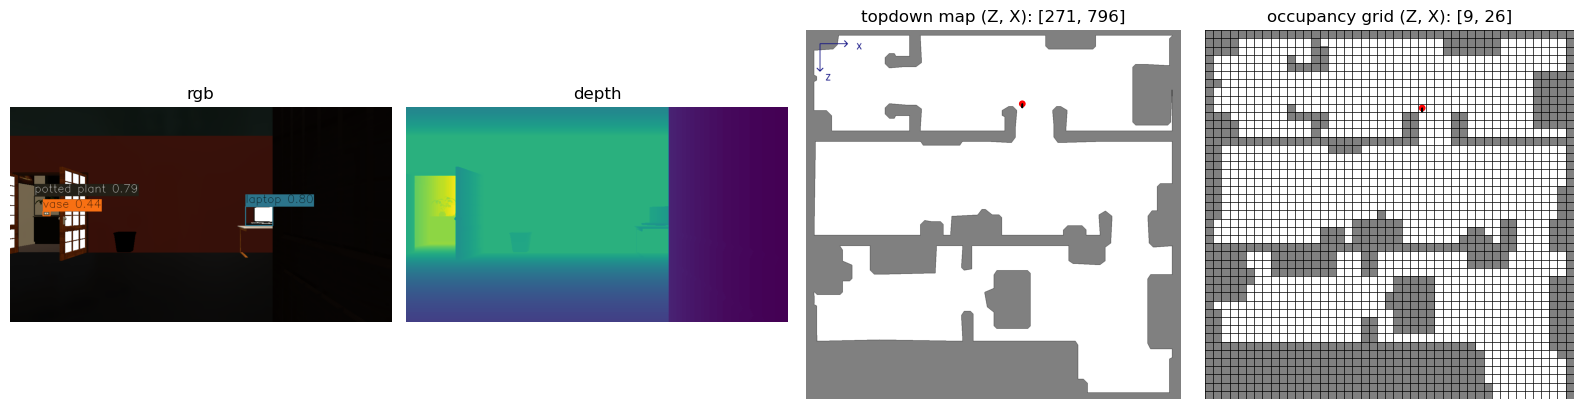


Target object <laptop> found after 152 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 152
Travelled distance: 36.32 m
Computed location error: 0.200 m
Episode reward: -0.52


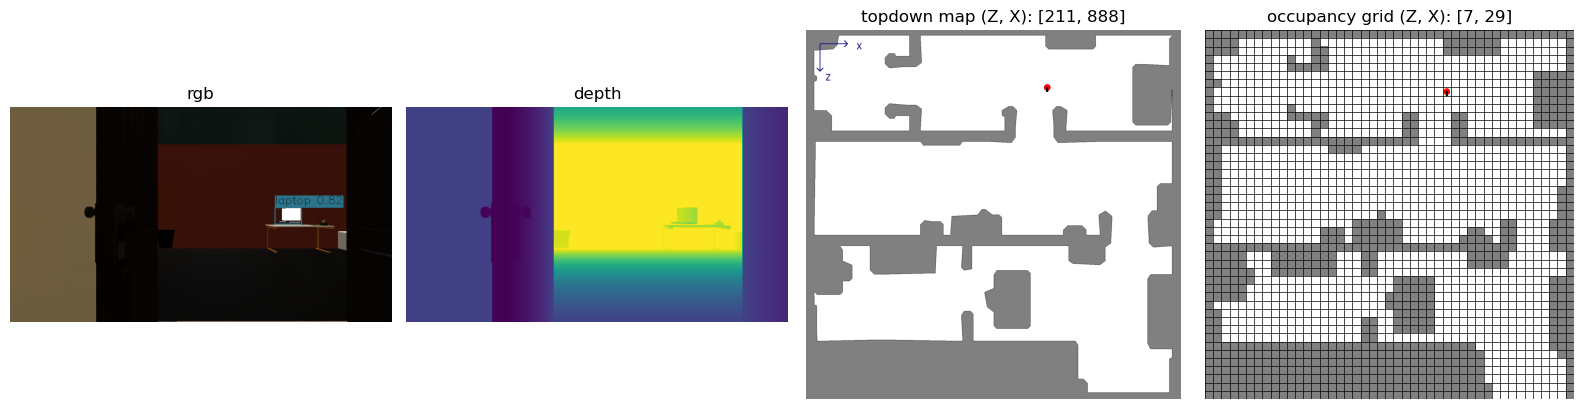


Target object <laptop> found after 181 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 181
Travelled distance: 43.01 m
Computed location error: 0.227 m
Episode reward: -0.81


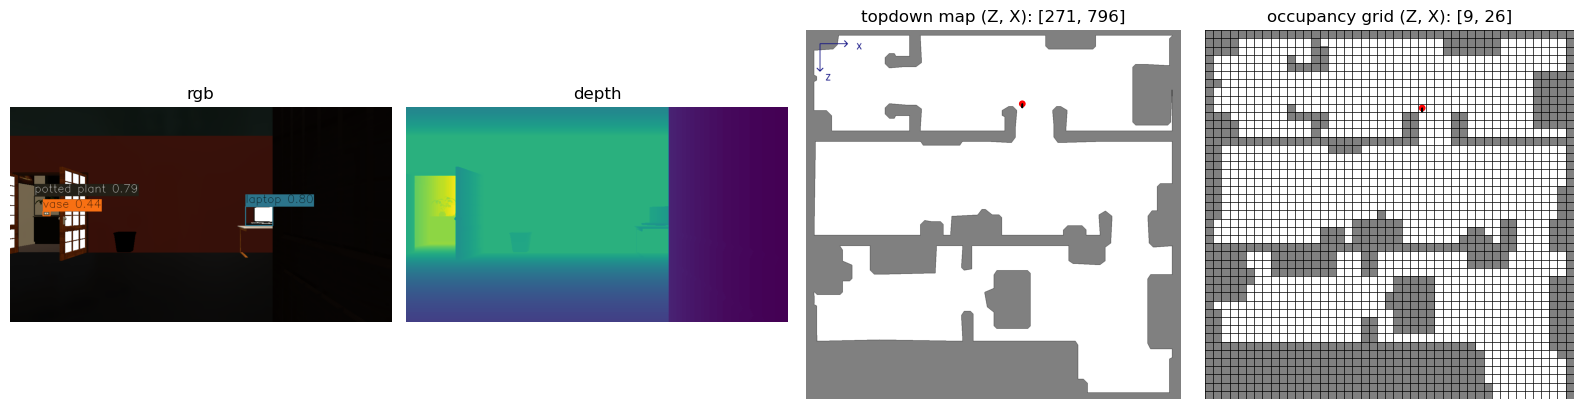


Target object <laptop> found after 43 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 43
Travelled distance: 9.42 m
Computed location error: 0.200 m
Episode reward: 0.57


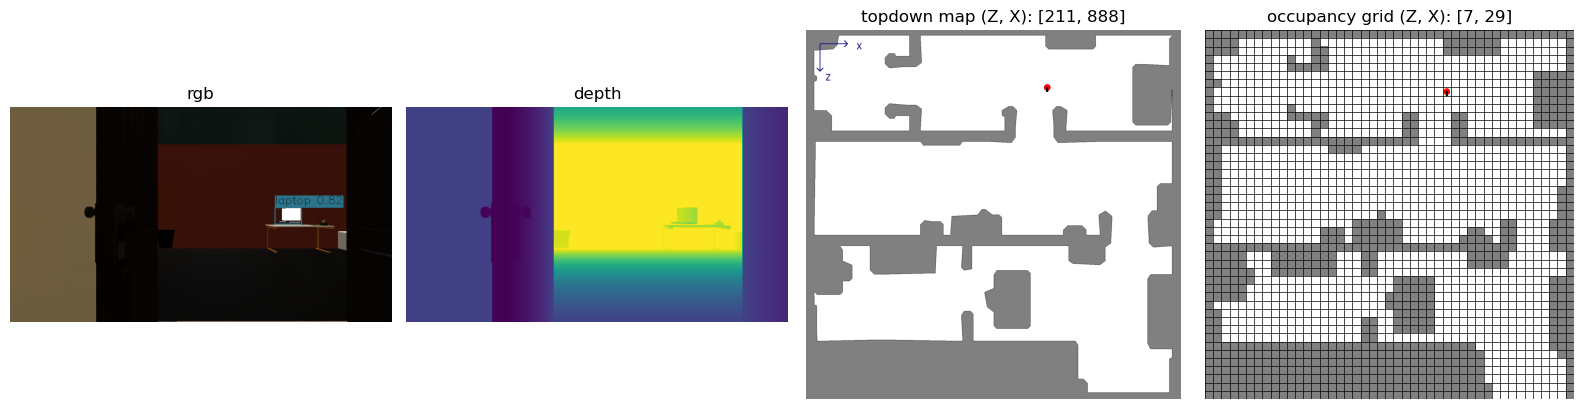


Target object <laptop> found after 9 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 9
Travelled distance: 2.14 m
Computed location error: 0.227 m
Episode reward: 0.91


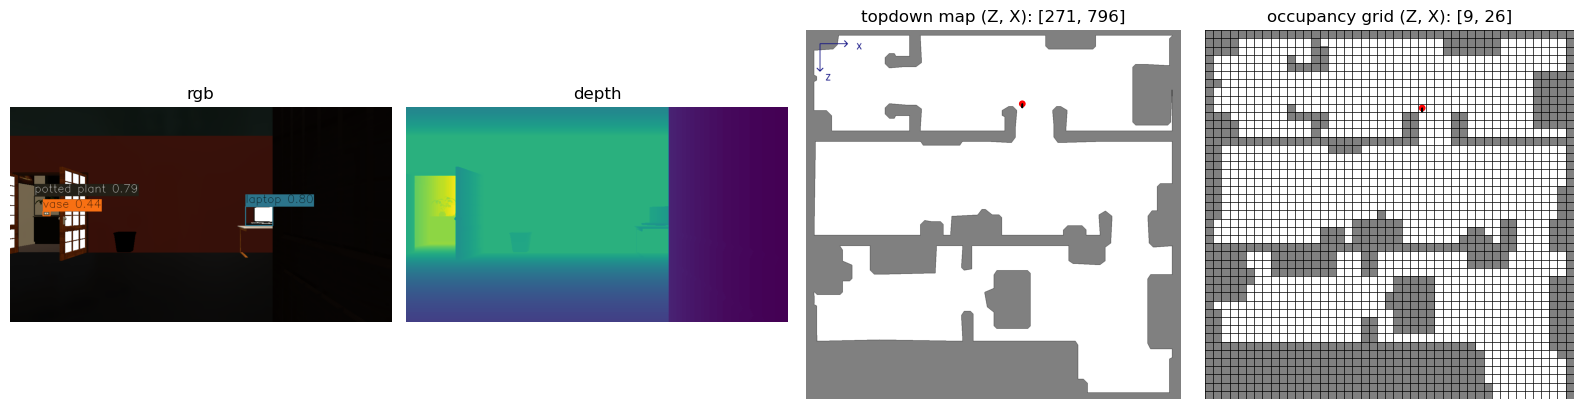


Target object <laptop> found after 182 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 182
Travelled distance: 43.00 m
Computed location error: 0.227 m
Episode reward: -0.82


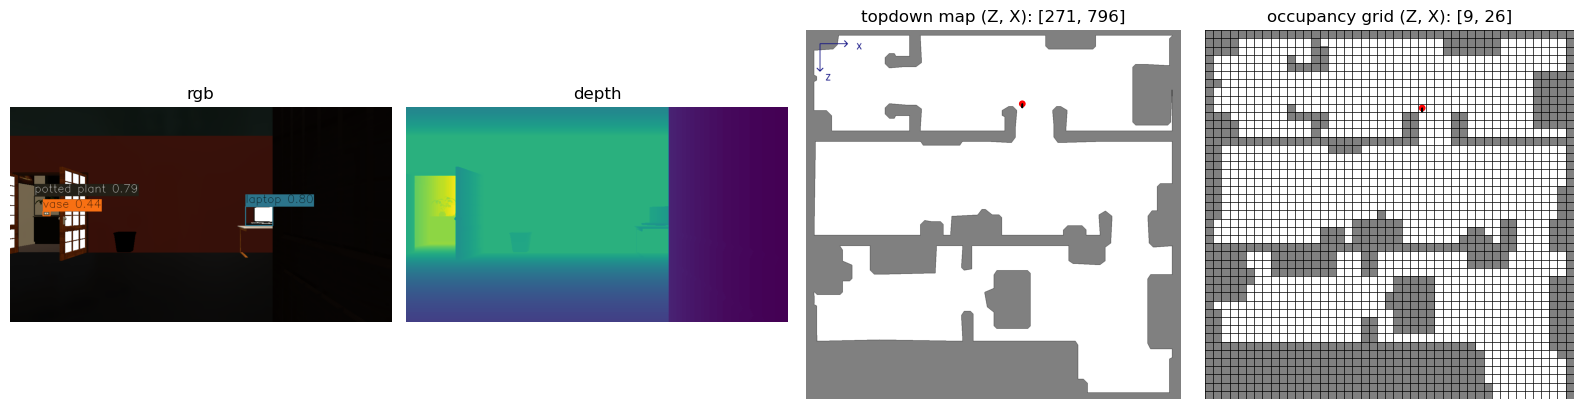


Target object <laptop> found after 13 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 13
Travelled distance: 3.37 m
Computed location error: 0.227 m
Episode reward: 0.87


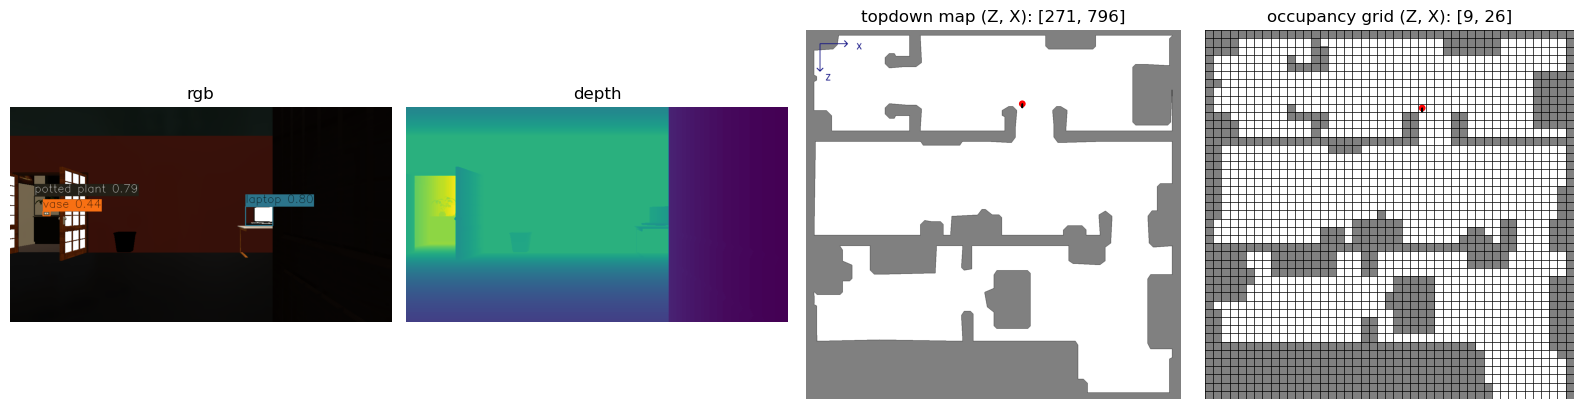


Target object <laptop> found after 161 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 161
Travelled distance: 38.46 m
Computed location error: 0.200 m
Episode reward: -0.61


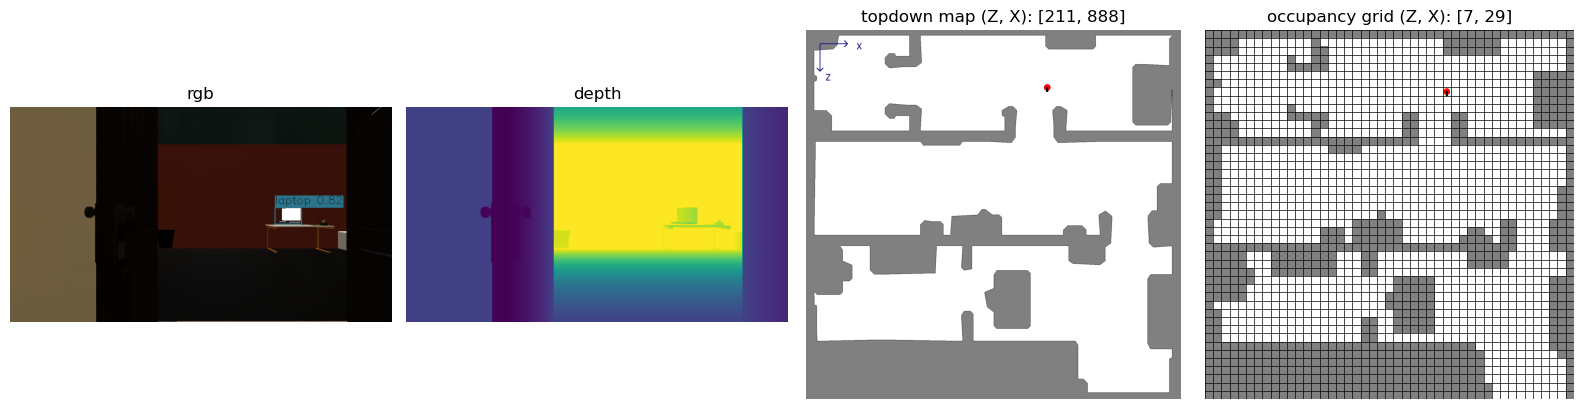


Target object <laptop> found after 3 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 3
Travelled distance: 0.31 m
Computed location error: 0.200 m
Episode reward: 0.97


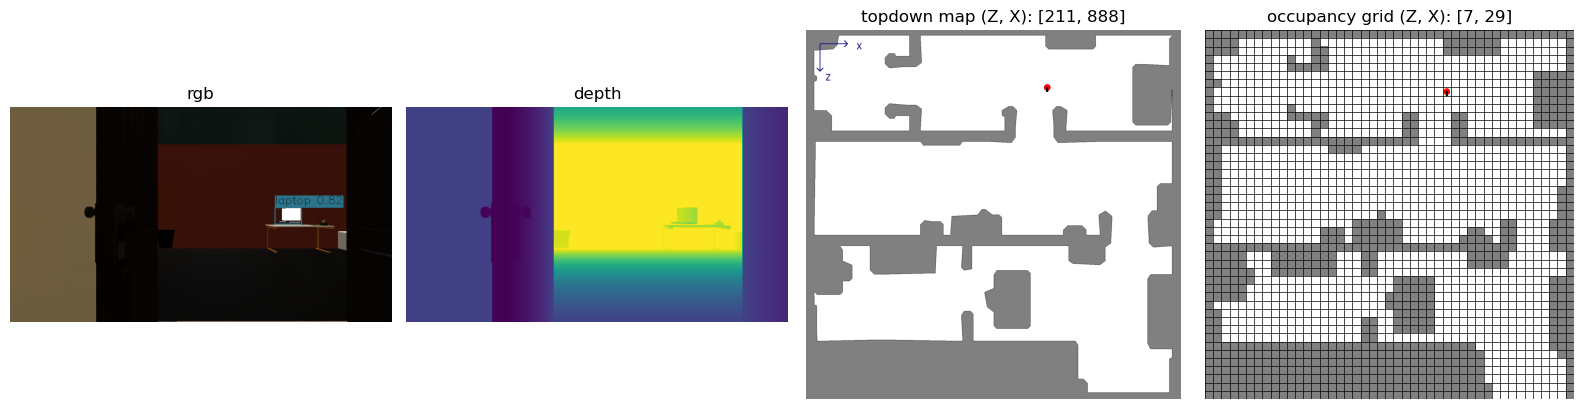


Target object <laptop> found after 32 actions!
Found location: [    -7.1323    0.028353      7.2366]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 32
Travelled distance: 8.88 m
Computed location error: 0.196 m
Episode reward: 0.68


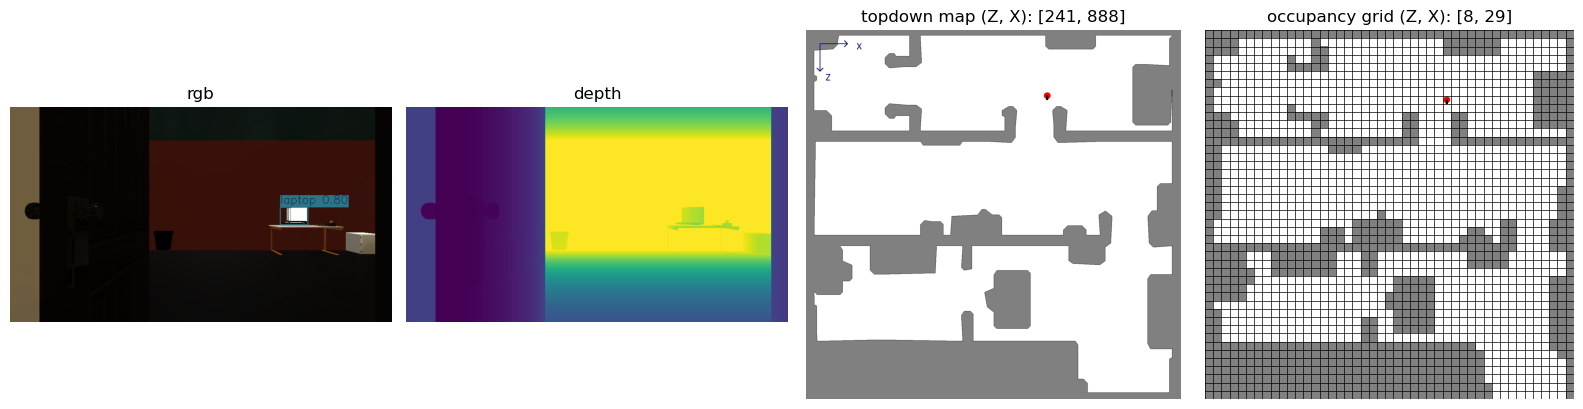


Target object <laptop> found after 8 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 8
Travelled distance: 1.21 m
Computed location error: 0.202 m
Episode reward: 0.92


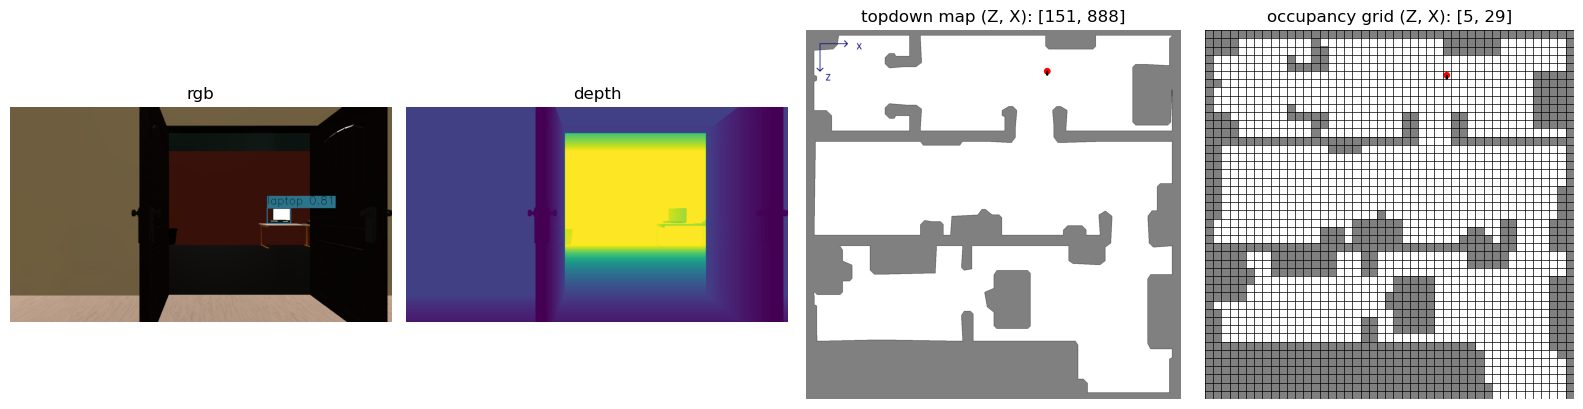


Target object <laptop> found after 192 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 192
Travelled distance: 44.24 m
Computed location error: 0.227 m
Episode reward: -0.92


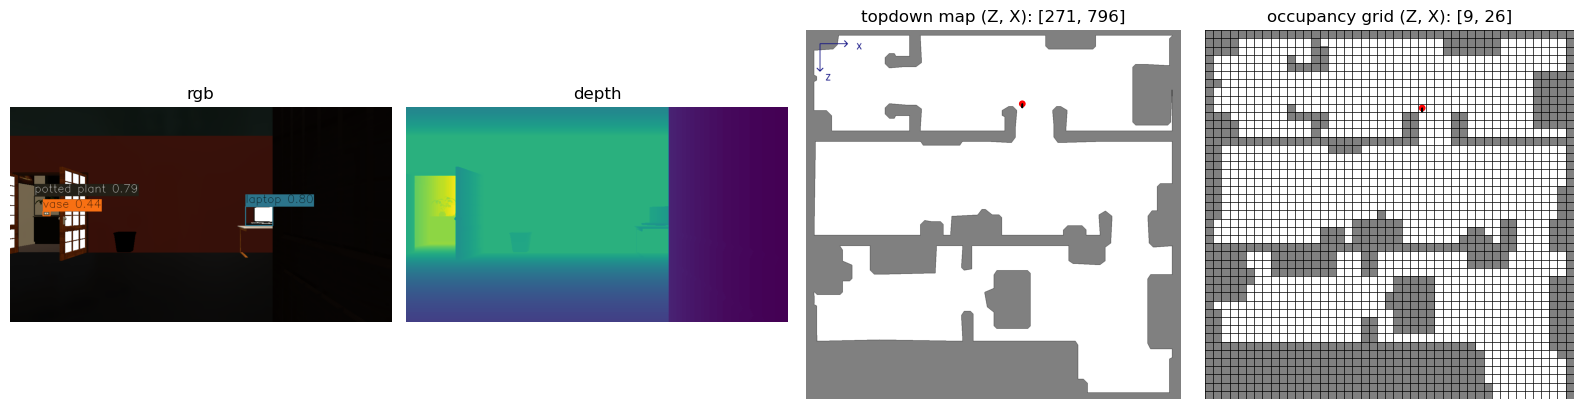


Target object <laptop> found after 11 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 11
Travelled distance: 3.06 m
Computed location error: 0.202 m
Episode reward: 0.89


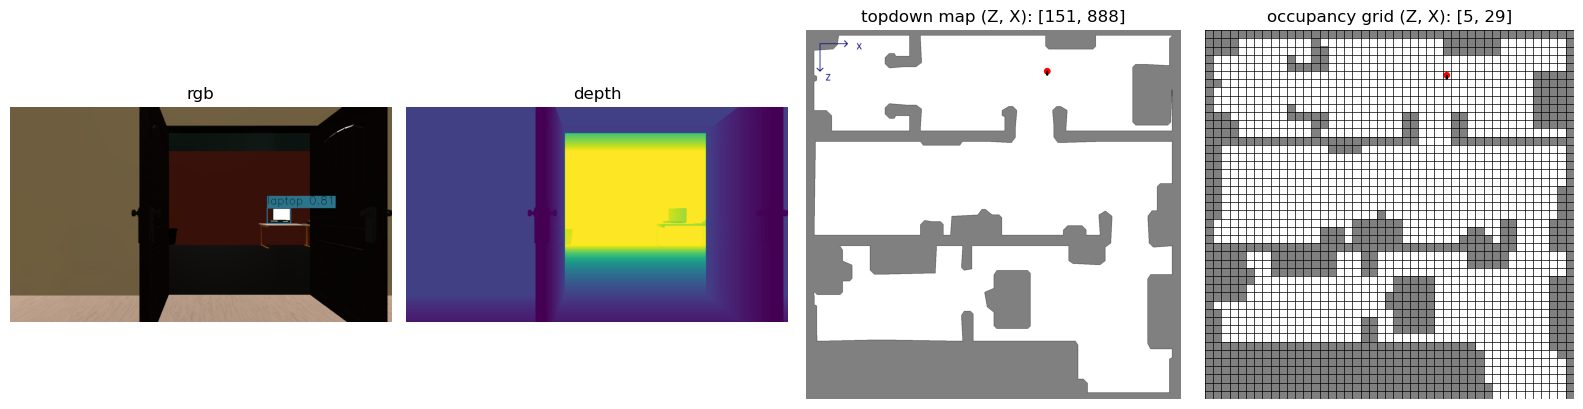


Target object <laptop> found after 170 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 170
Travelled distance: 39.96 m
Computed location error: 0.227 m
Episode reward: -0.70


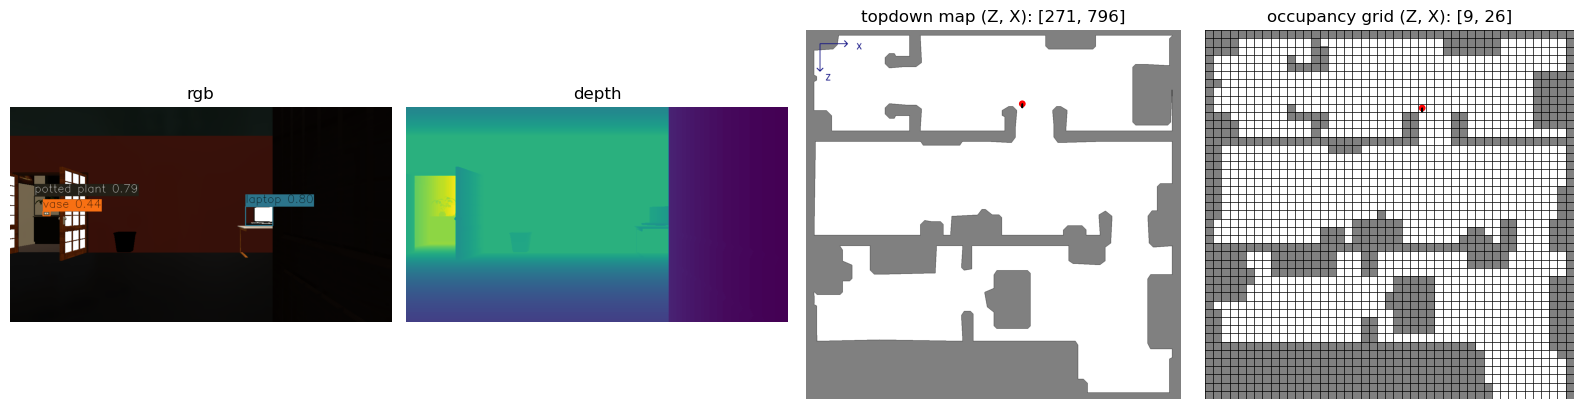


Target object <laptop> found after 200 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 200
Travelled distance: 48.81 m
Computed location error: 0.227 m
Episode reward: -1.00


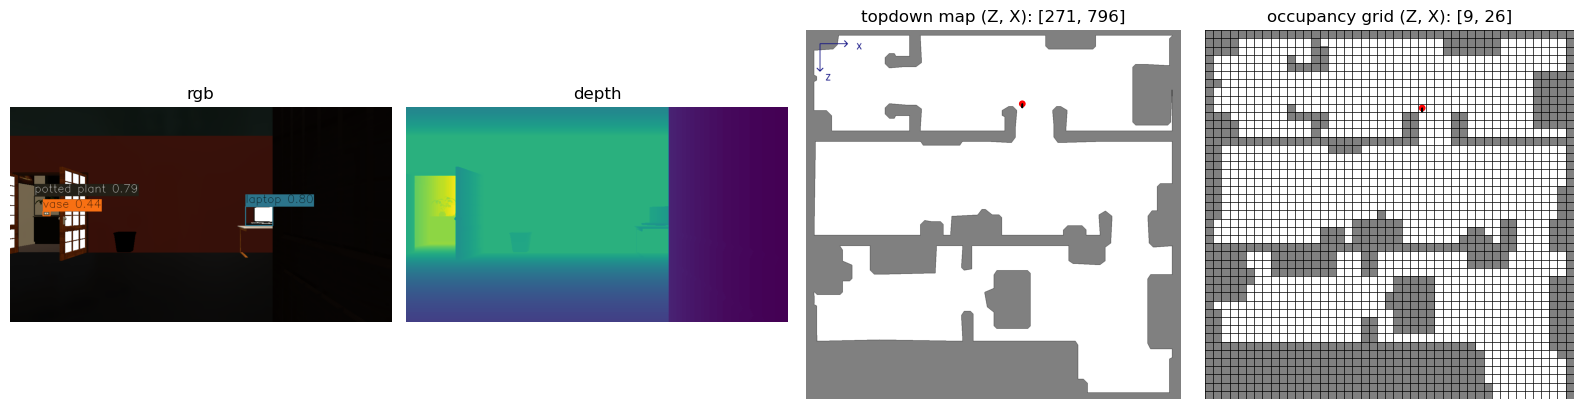


Target object <laptop> found after 31 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 31
Travelled distance: 7.04 m
Computed location error: 0.200 m
Episode reward: 0.69


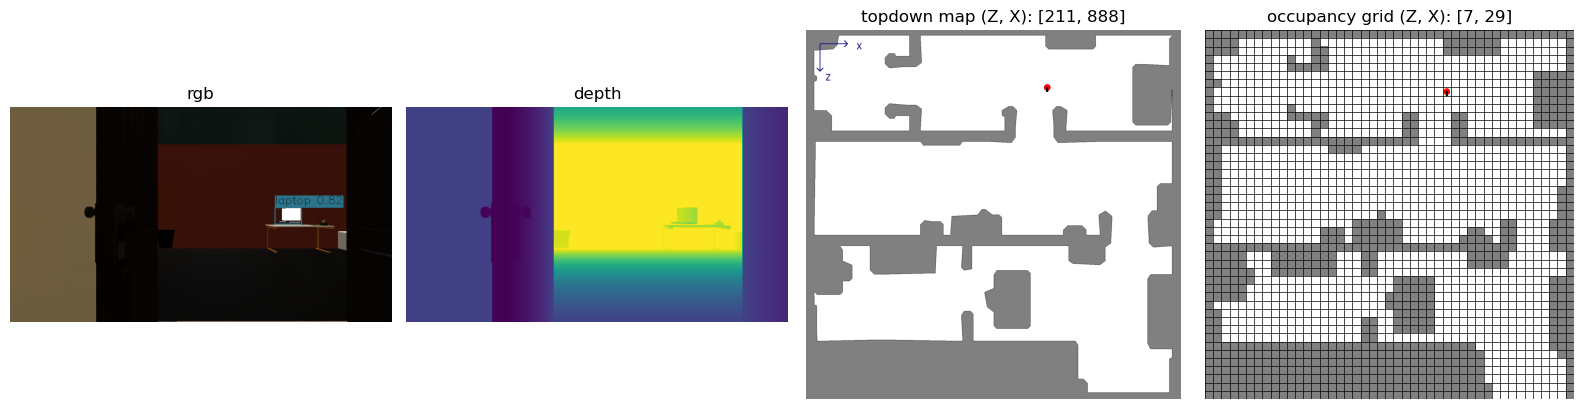


Target object <laptop> found after 182 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 182
Travelled distance: 42.42 m
Computed location error: 0.227 m
Episode reward: -0.82


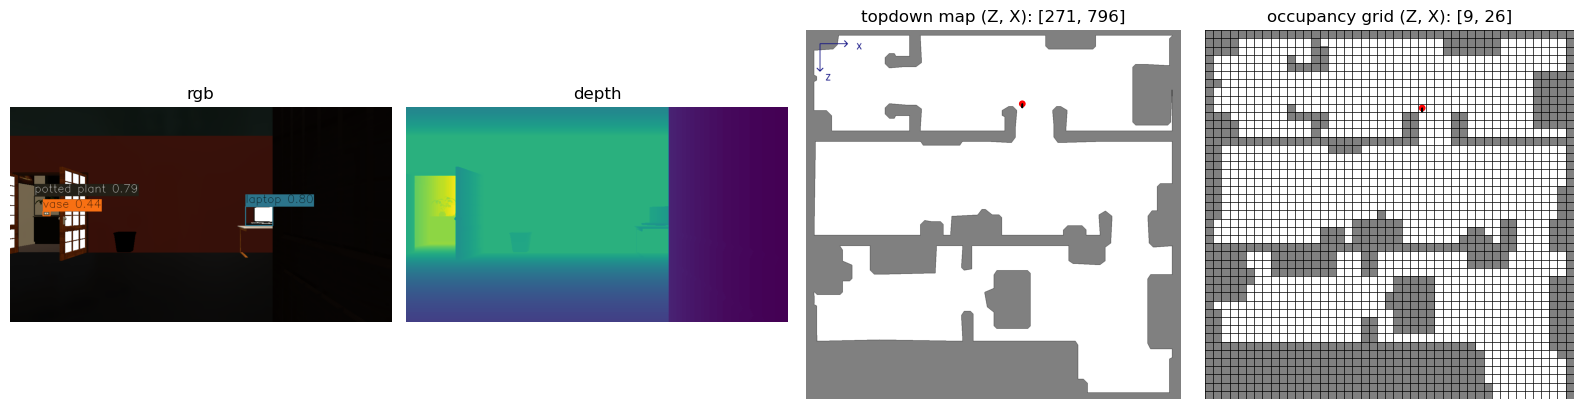


Target object <laptop> found after 72 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 72
Travelled distance: 17.13 m
Computed location error: 0.200 m
Episode reward: 0.28


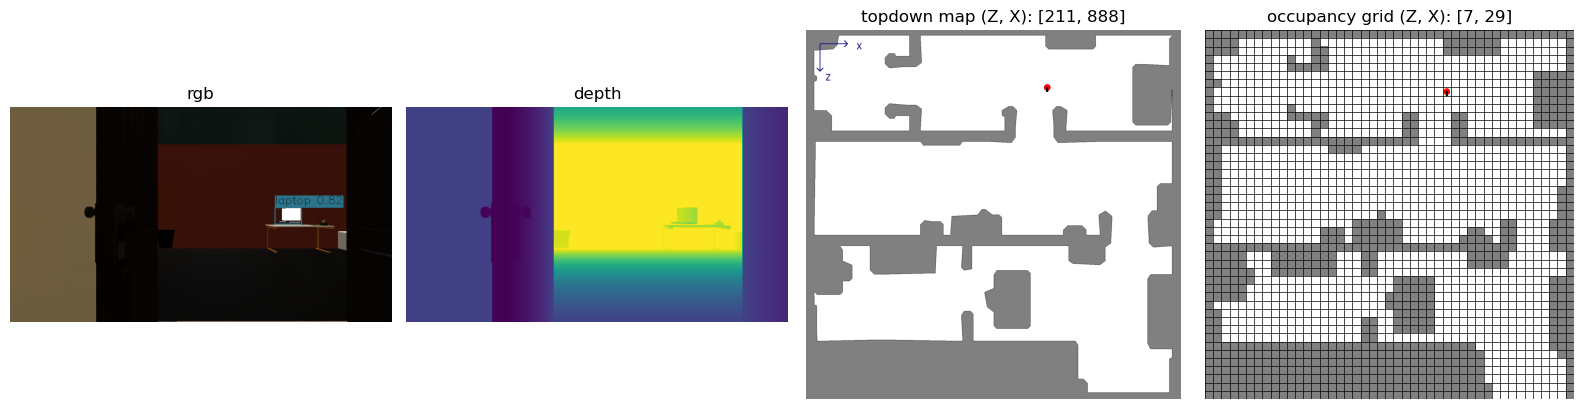


Target object <laptop> found after 93 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 93
Travelled distance: 19.49 m
Computed location error: 0.223 m
Episode reward: 0.07


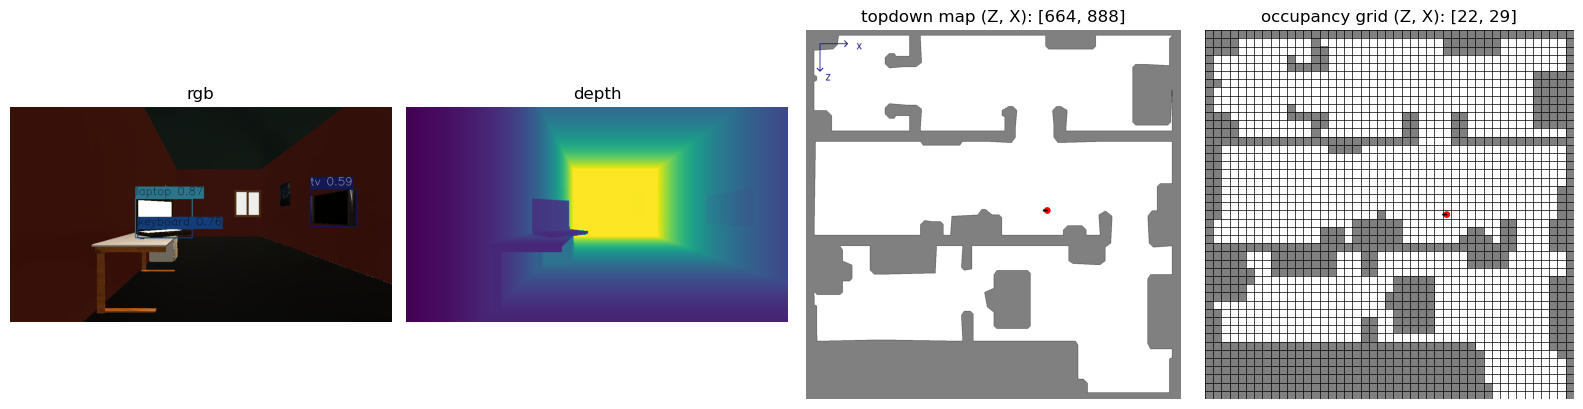


Target object <laptop> found after 31 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 31
Travelled distance: 8.50 m
Computed location error: 0.223 m
Episode reward: 0.69


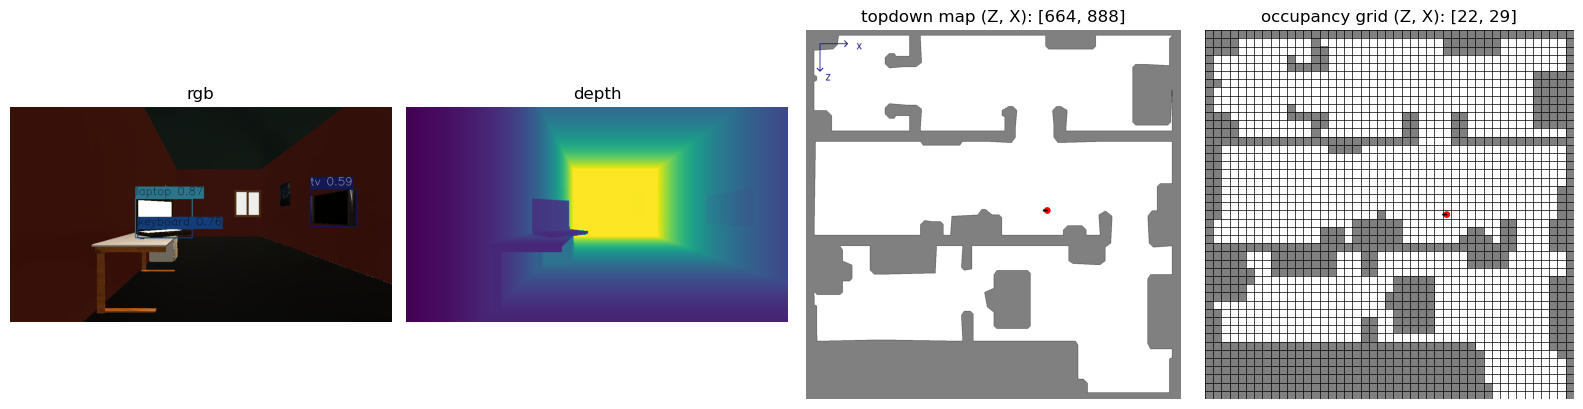


Target object <laptop> found after 10 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 10
Travelled distance: 2.13 m
Computed location error: 0.202 m
Episode reward: 0.90


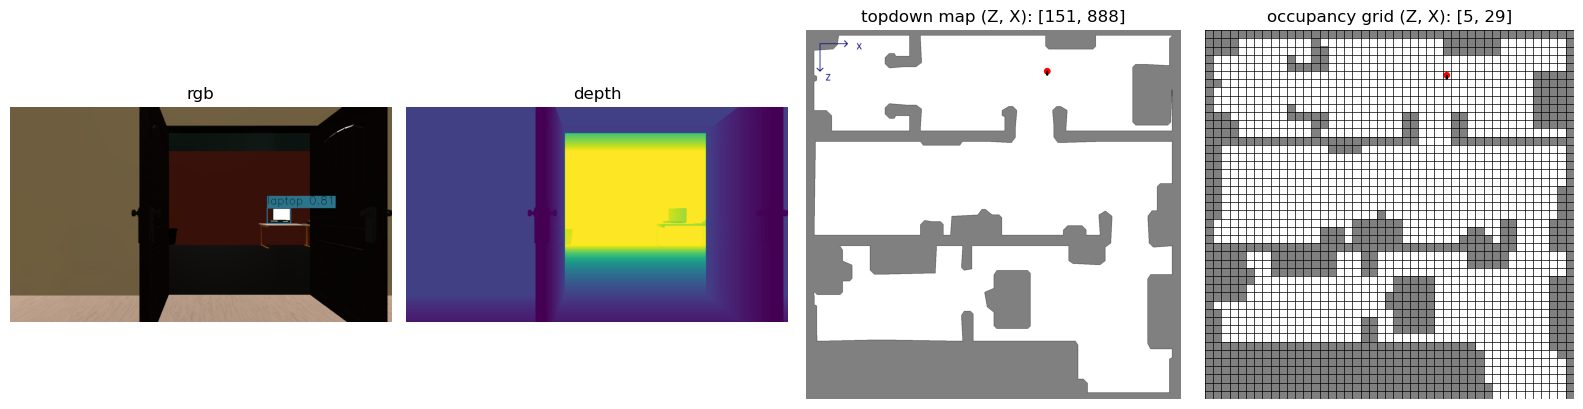


Target object <laptop> found after 202 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 202
Travelled distance: 49.75 m
Computed location error: 0.227 m
Episode reward: -1.02


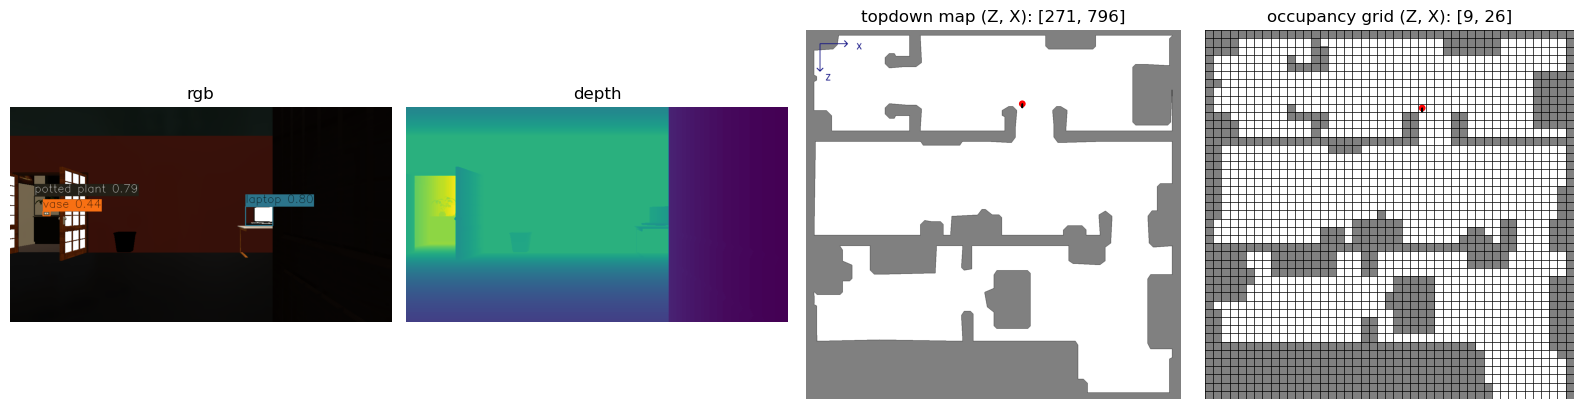


Target object <laptop> found after 206 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 206
Travelled distance: 50.66 m
Computed location error: 0.227 m
Episode reward: -1.06


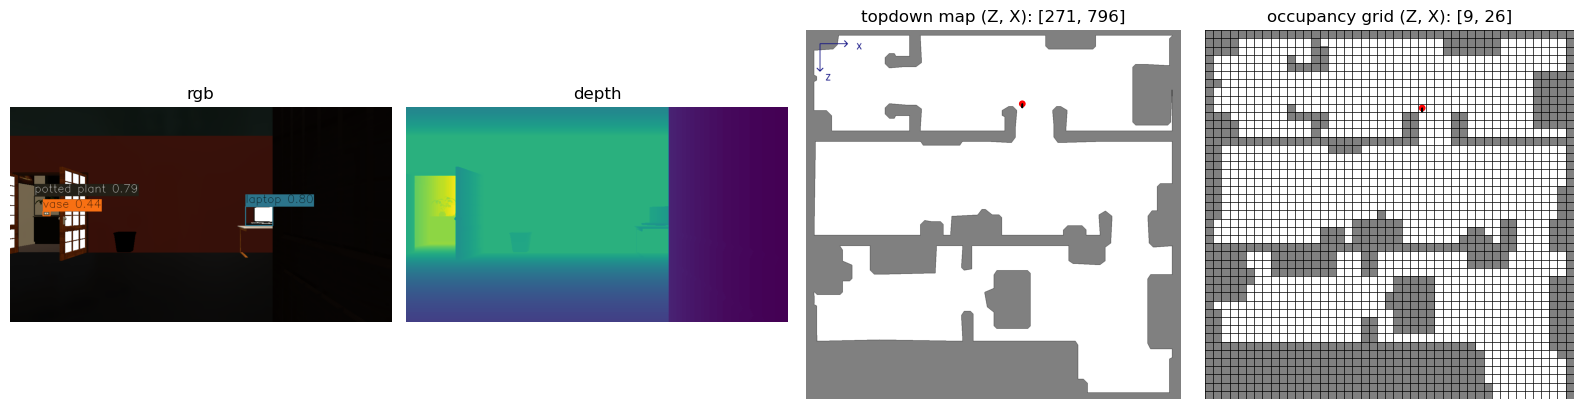


Target object <laptop> found after 191 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 191
Travelled distance: 45.16 m
Computed location error: 0.227 m
Episode reward: -0.91


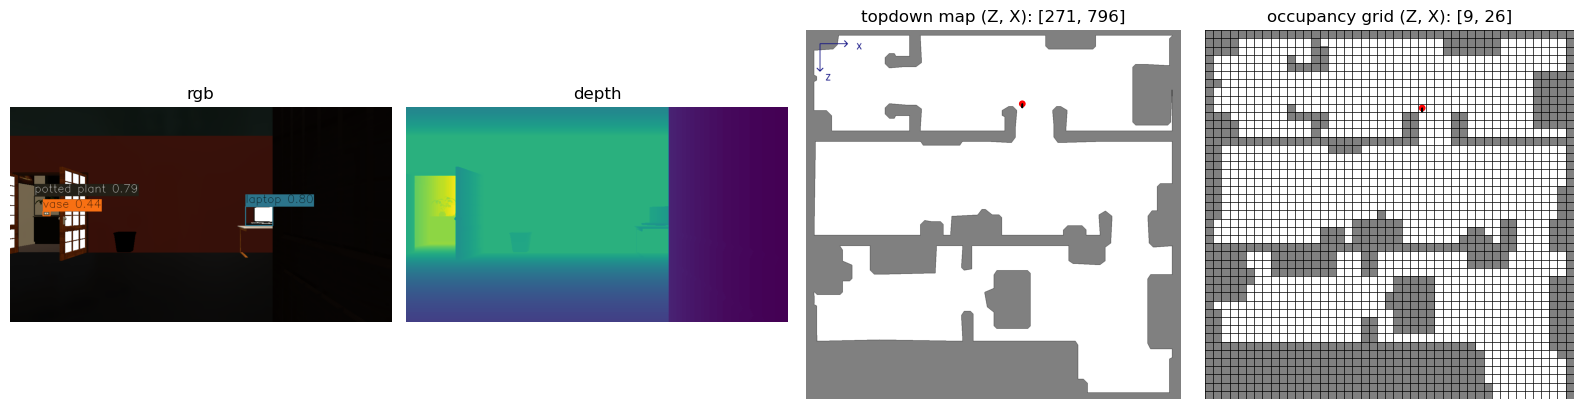


Target object <laptop> found after 19 actions!
Found location: [    -7.1323    0.028353      7.2366]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 19
Travelled distance: 5.21 m
Computed location error: 0.196 m
Episode reward: 0.81


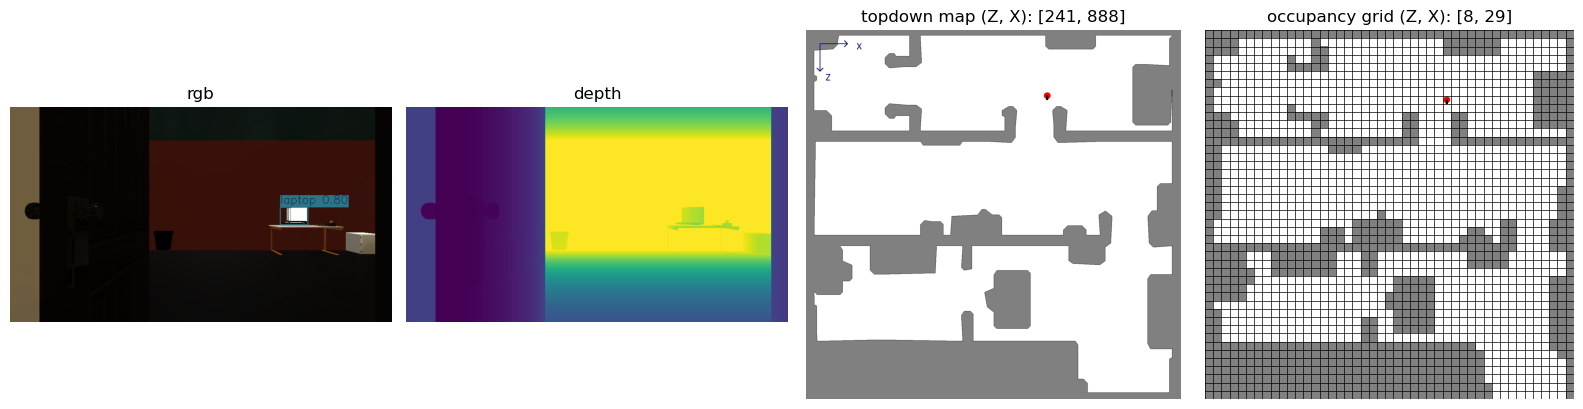


Target object <laptop> found after 187 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 187
Travelled distance: 44.24 m
Computed location error: 0.200 m
Episode reward: -0.87


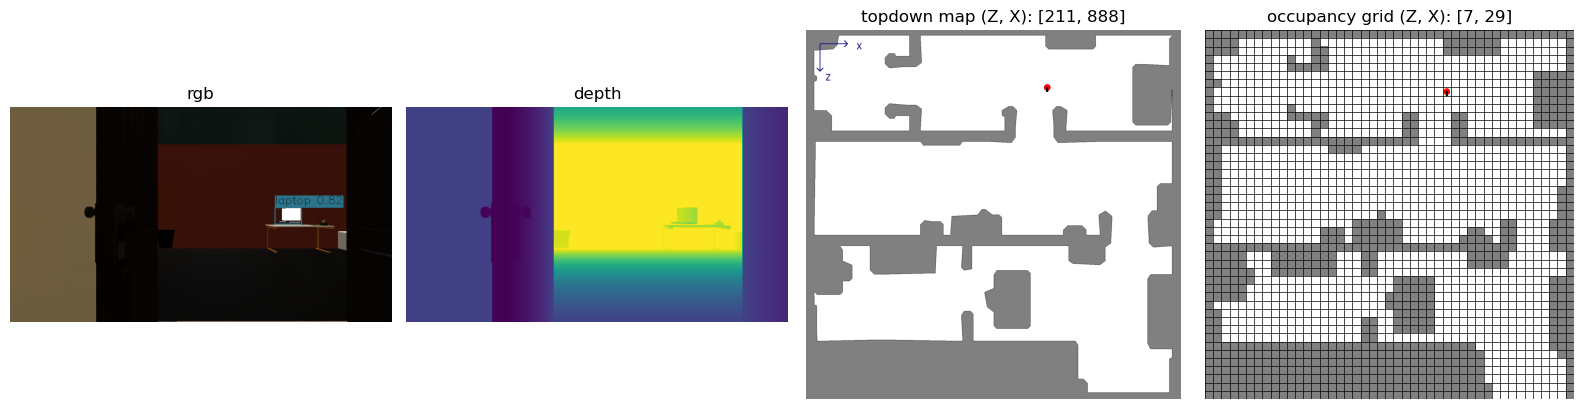


Target object <laptop> found after 11 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 11
Travelled distance: 3.05 m
Computed location error: 0.202 m
Episode reward: 0.89


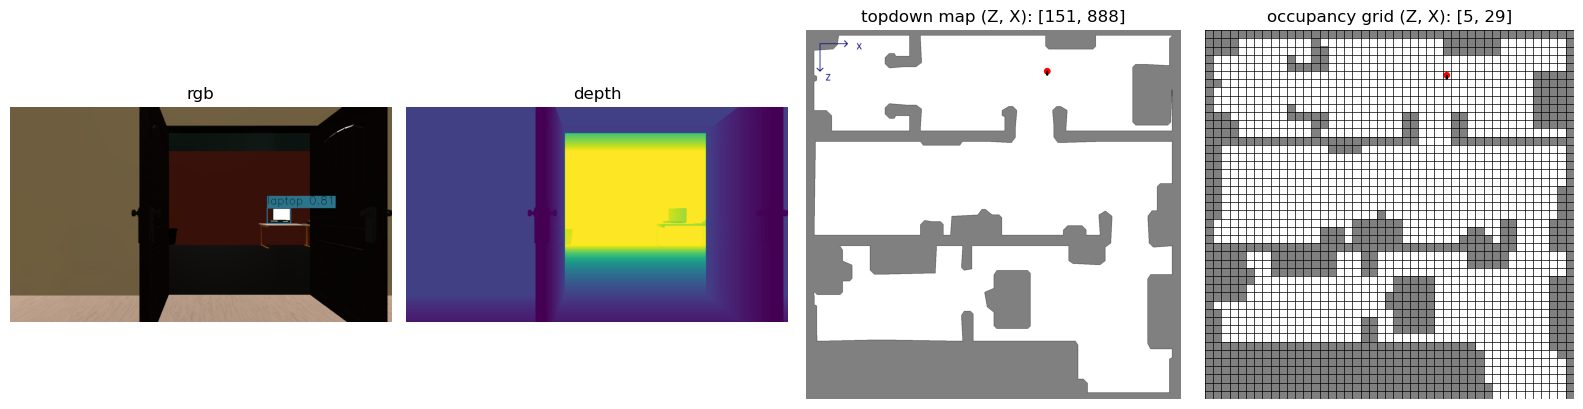


Target object <laptop> found after 174 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 174
Travelled distance: 40.55 m
Computed location error: 0.227 m
Episode reward: -0.74


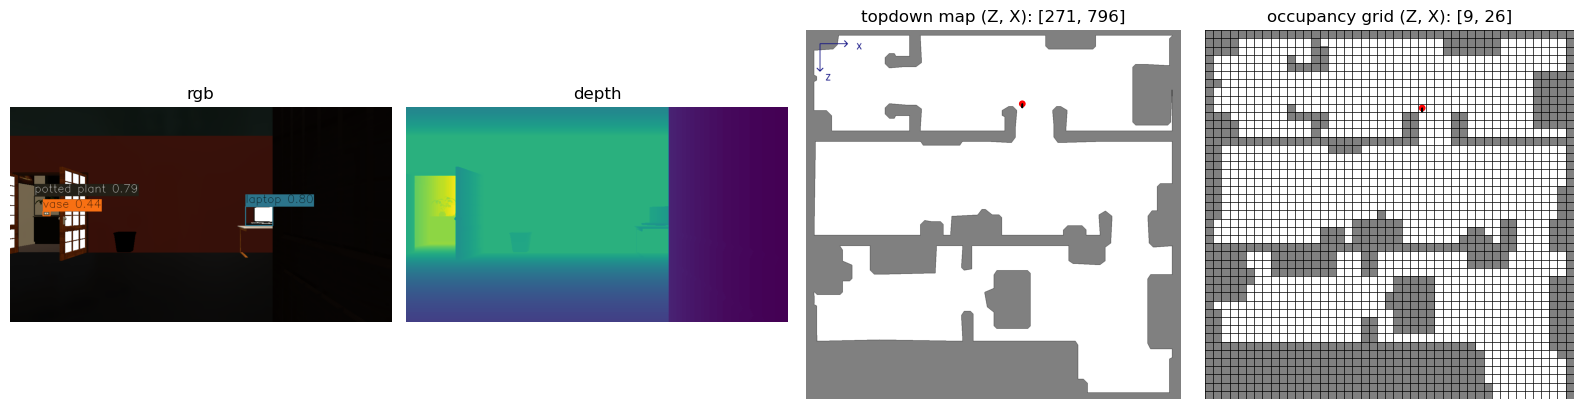


Target object <laptop> found after 156 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 156
Travelled distance: 36.93 m
Computed location error: 0.200 m
Episode reward: -0.56


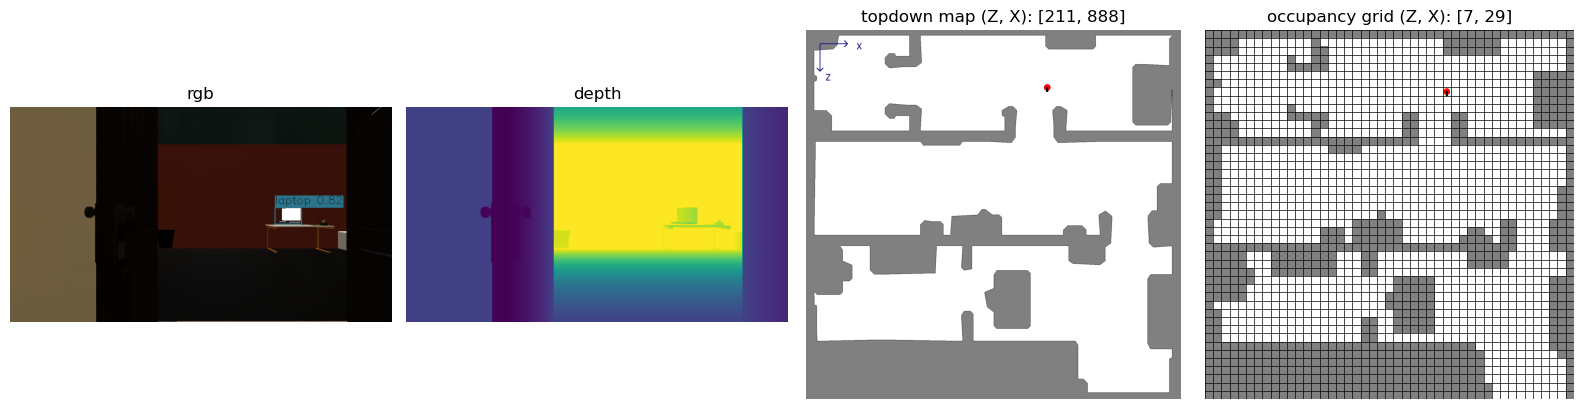


Target object <laptop> found after 8 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 8
Travelled distance: 1.83 m
Computed location error: 0.202 m
Episode reward: 0.92


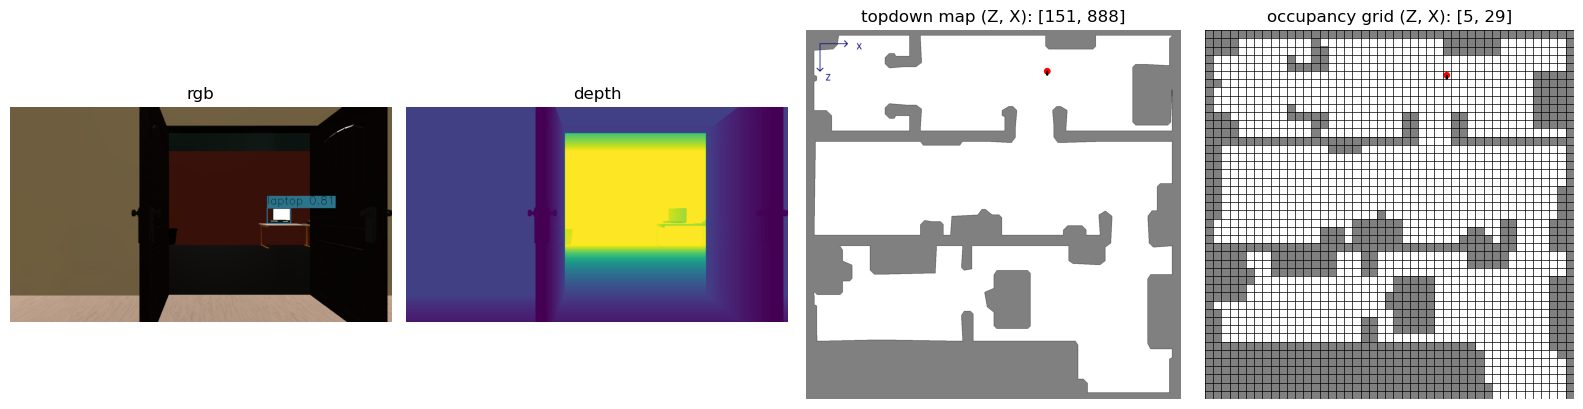


Target object <laptop> found after 30 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 30
Travelled distance: 6.73 m
Computed location error: 0.200 m
Episode reward: 0.70


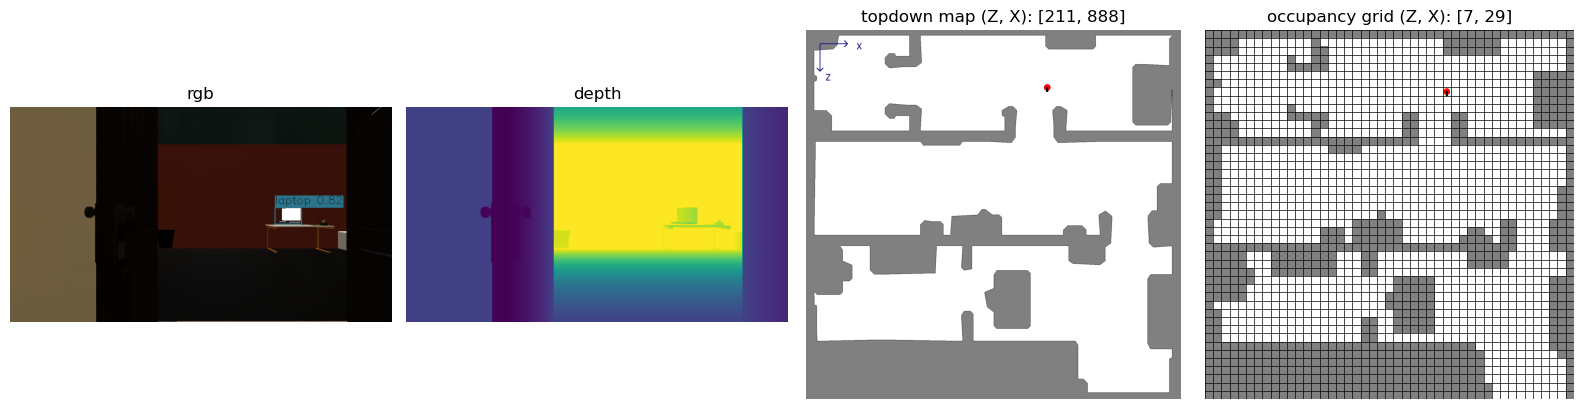


Target object <laptop> found after 197 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 197
Travelled distance: 45.42 m
Computed location error: 0.227 m
Episode reward: -0.97


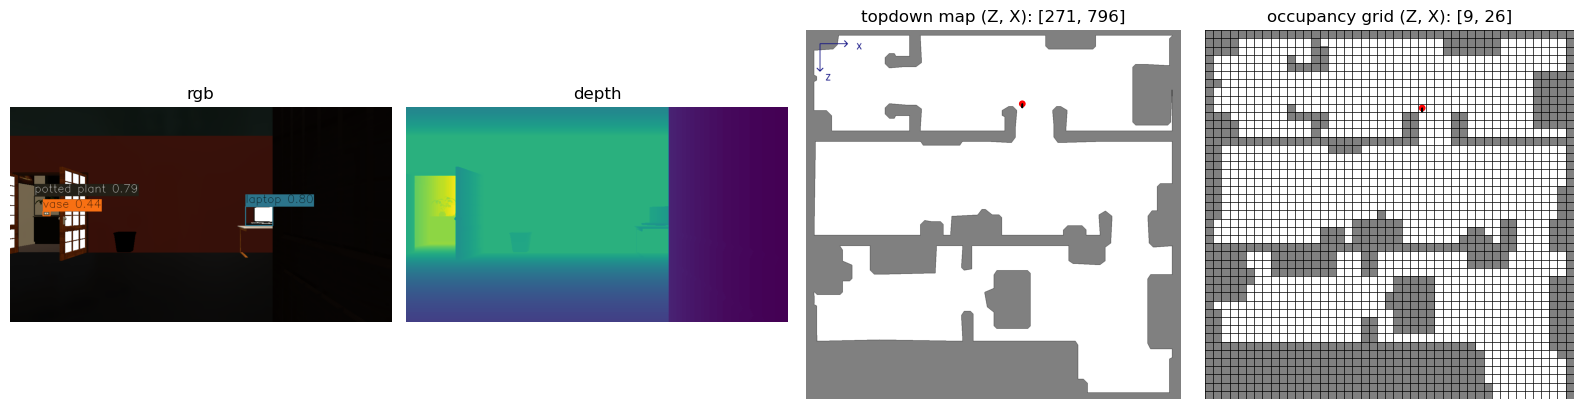


Target object <laptop> found after 160 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 160
Travelled distance: 38.14 m
Computed location error: 0.200 m
Episode reward: -0.60


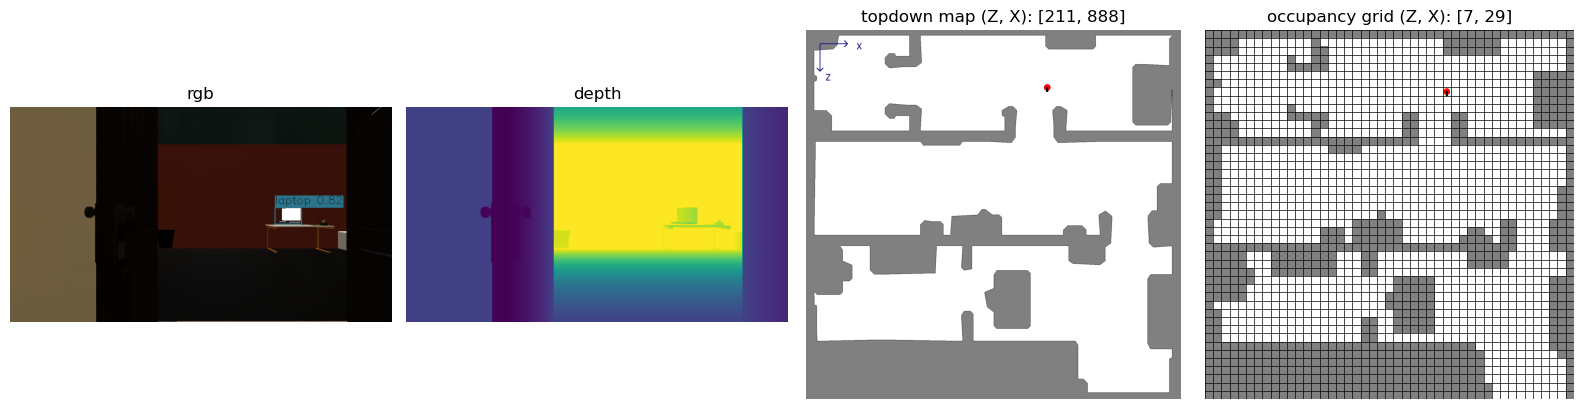


Target object <laptop> found after 158 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 158
Travelled distance: 37.83 m
Computed location error: 0.200 m
Episode reward: -0.58


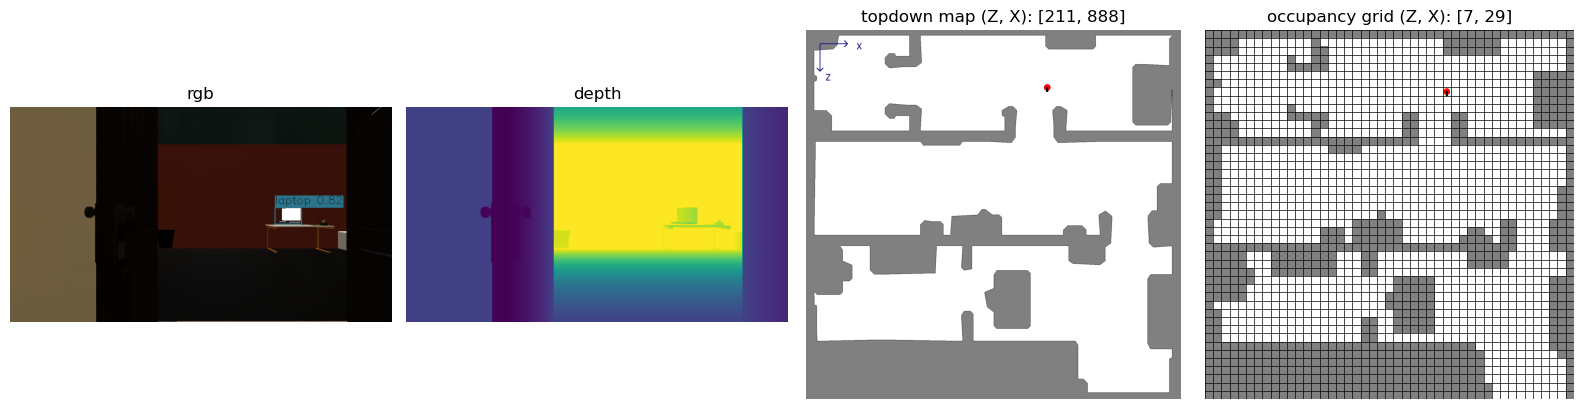


Target object <laptop> found after 33 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 33
Travelled distance: 9.18 m
Computed location error: 0.202 m
Episode reward: 0.67


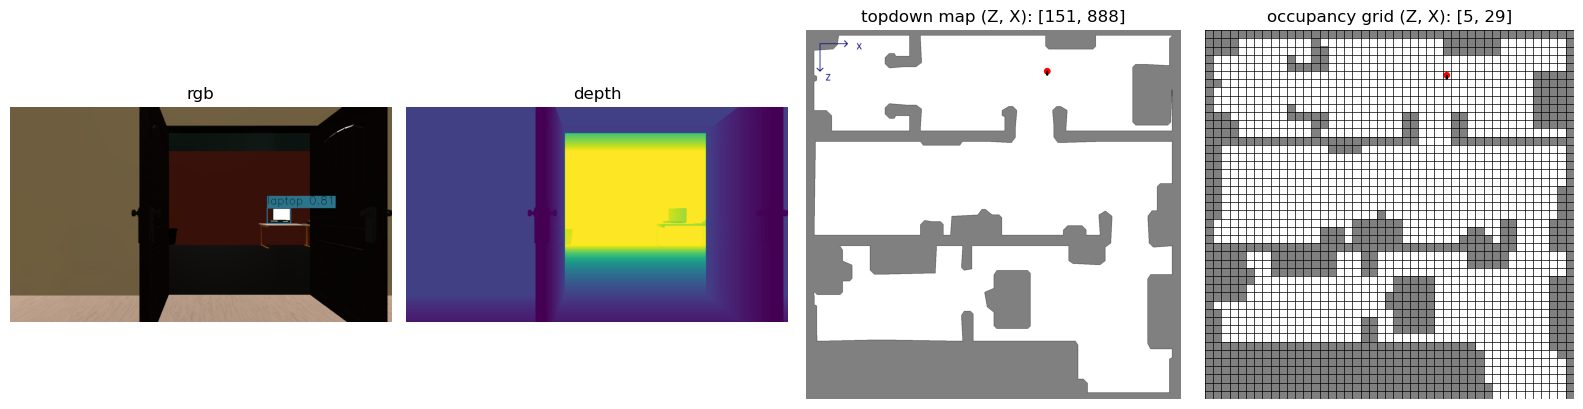


Target object <laptop> found after 47 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 47
Travelled distance: 11.02 m
Computed location error: 0.200 m
Episode reward: 0.53


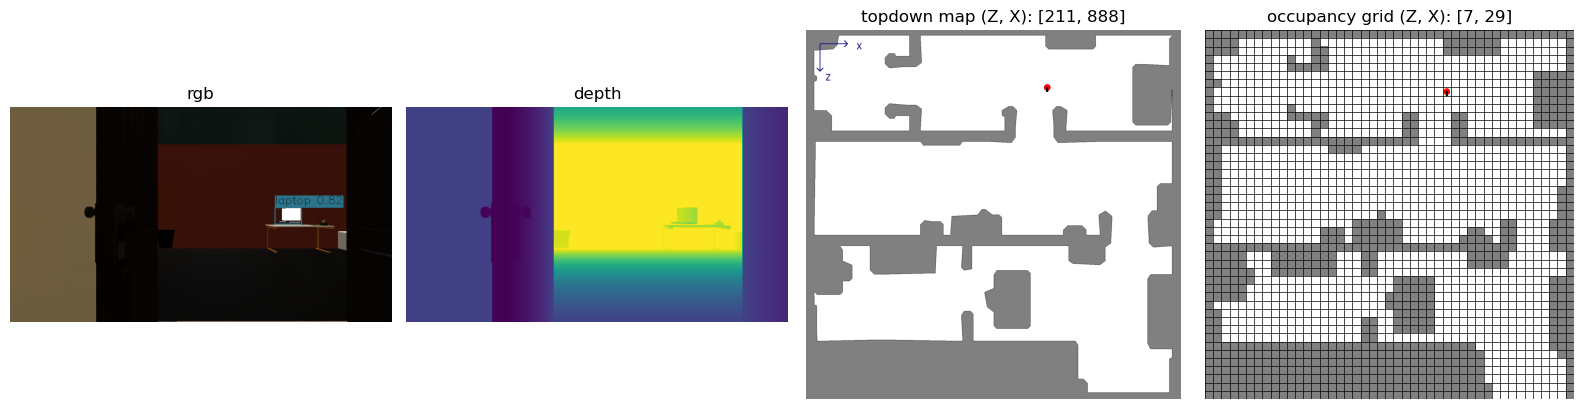


Target object <laptop> found after 95 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 95
Travelled distance: 22.56 m
Computed location error: 0.200 m
Episode reward: 0.05


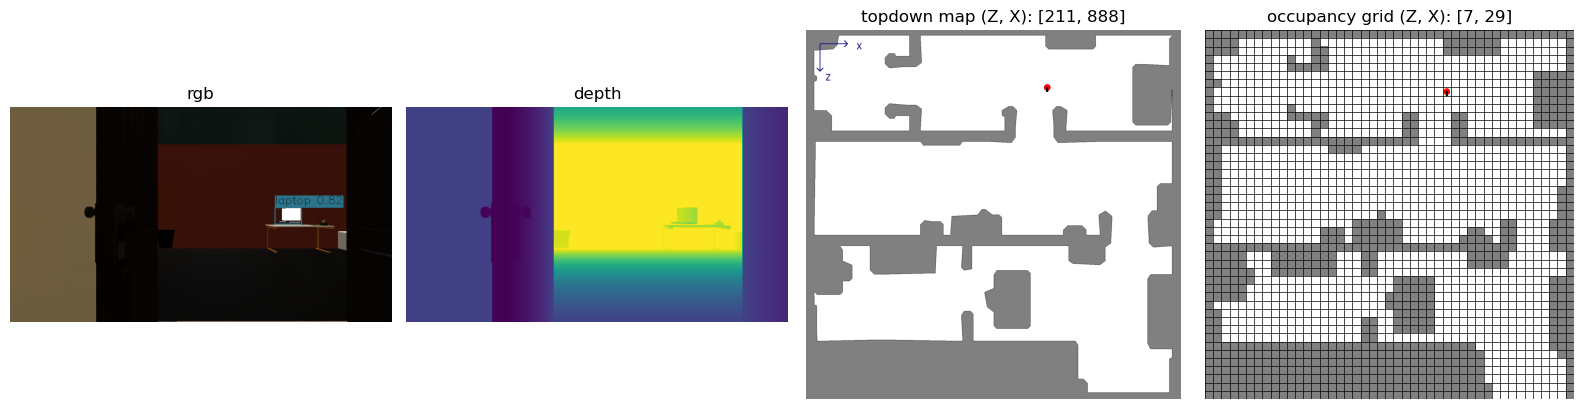


Target object <laptop> found after 190 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 190
Travelled distance: 46.07 m
Computed location error: 0.227 m
Episode reward: -0.90


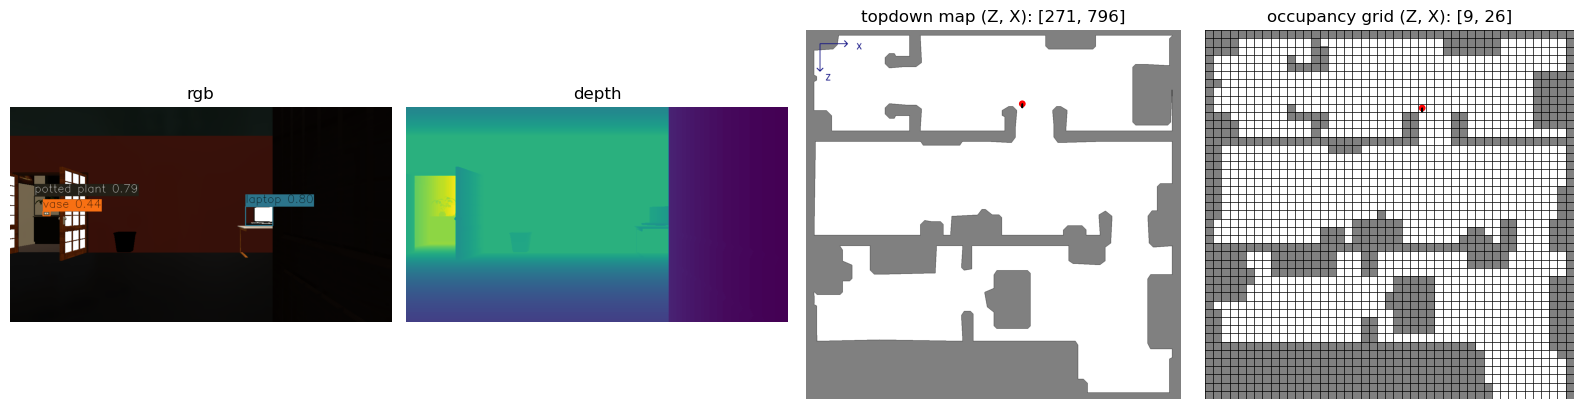


Target object <laptop> found after 243 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 243
Travelled distance: 60.09 m
Computed location error: 0.227 m
Episode reward: -1.43


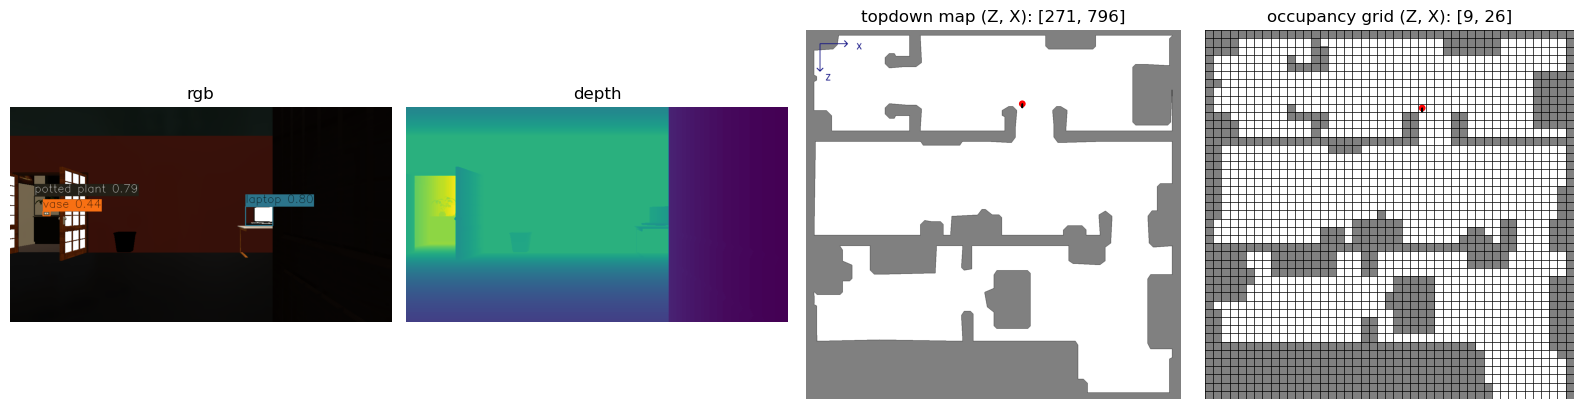


Target object <laptop> found after 177 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 177
Travelled distance: 41.52 m
Computed location error: 0.200 m
Episode reward: -0.77


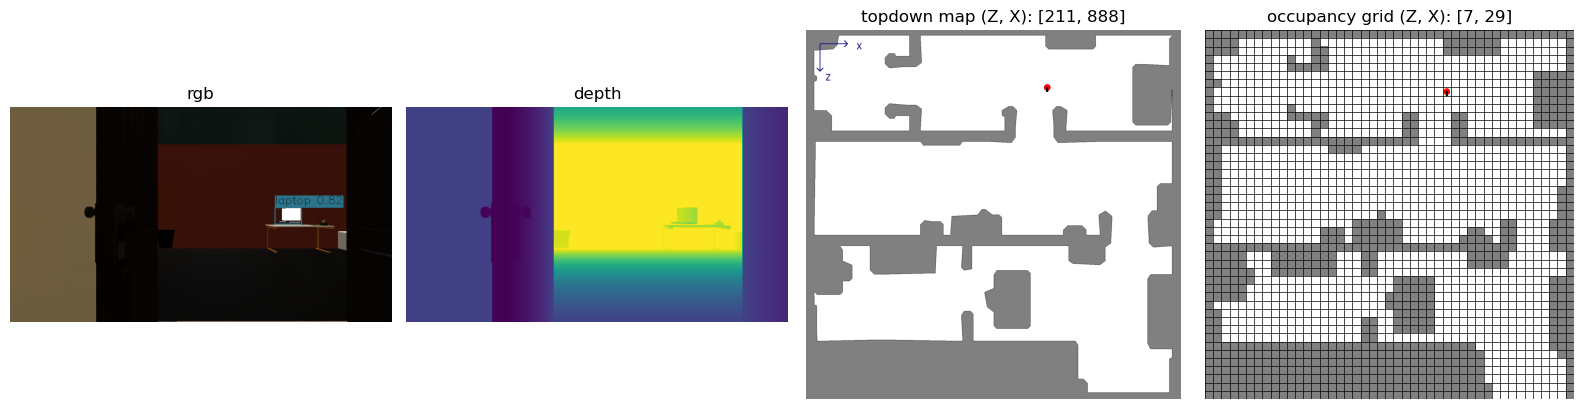


Target object <laptop> found after 29 actions!
Found location: [    -7.1323    0.028353      7.2366]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 29
Travelled distance: 7.34 m
Computed location error: 0.196 m
Episode reward: 0.71


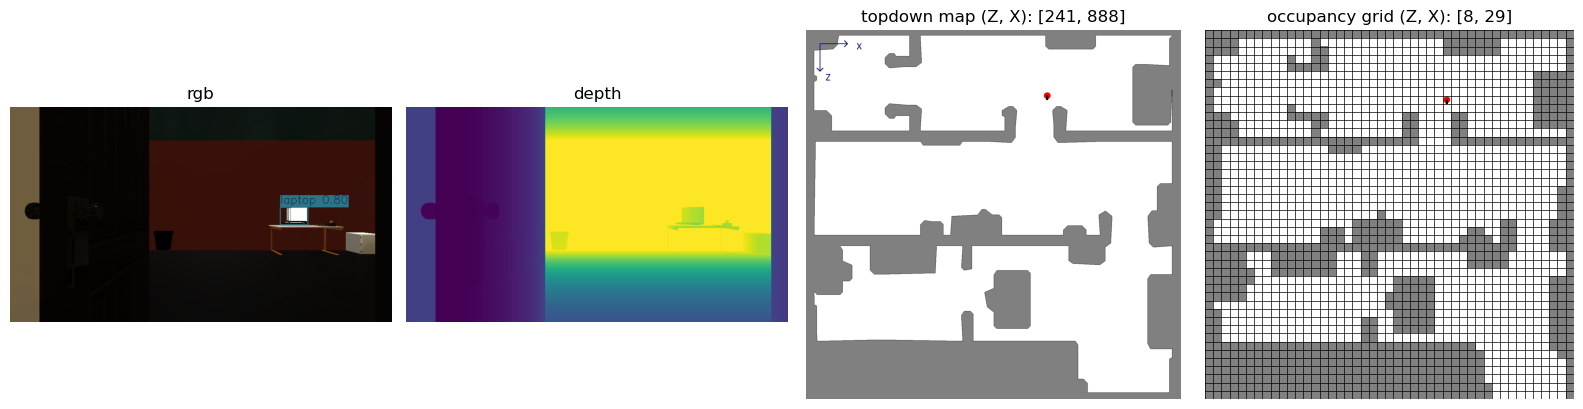


Target object <laptop> found after 69 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 69
Travelled distance: 16.52 m
Computed location error: 0.200 m
Episode reward: 0.31


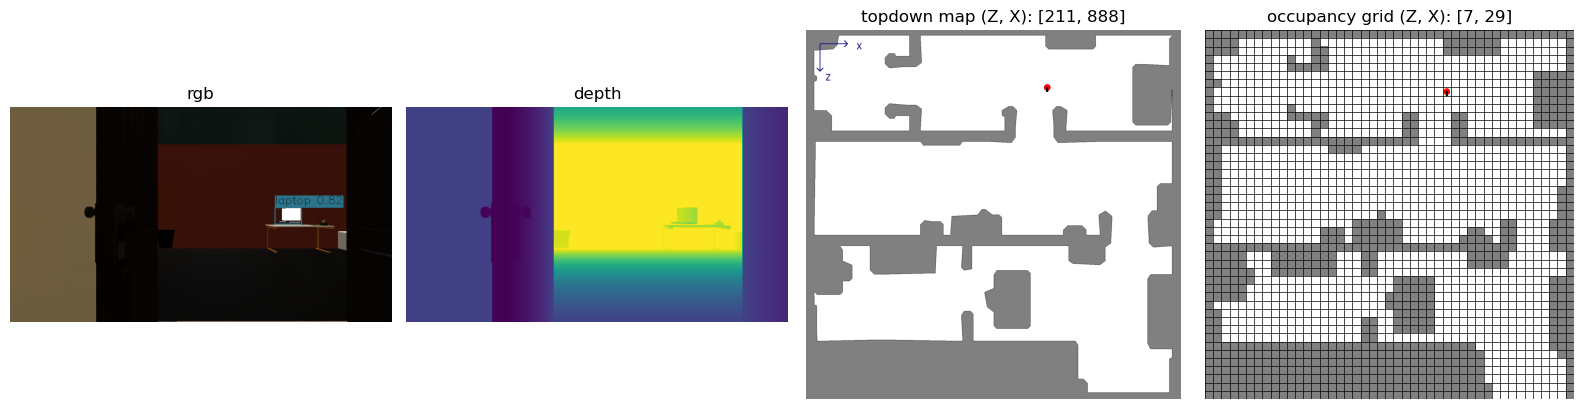


Target object <laptop> found after 168 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 168
Travelled distance: 40.62 m
Computed location error: 0.200 m
Episode reward: -0.68


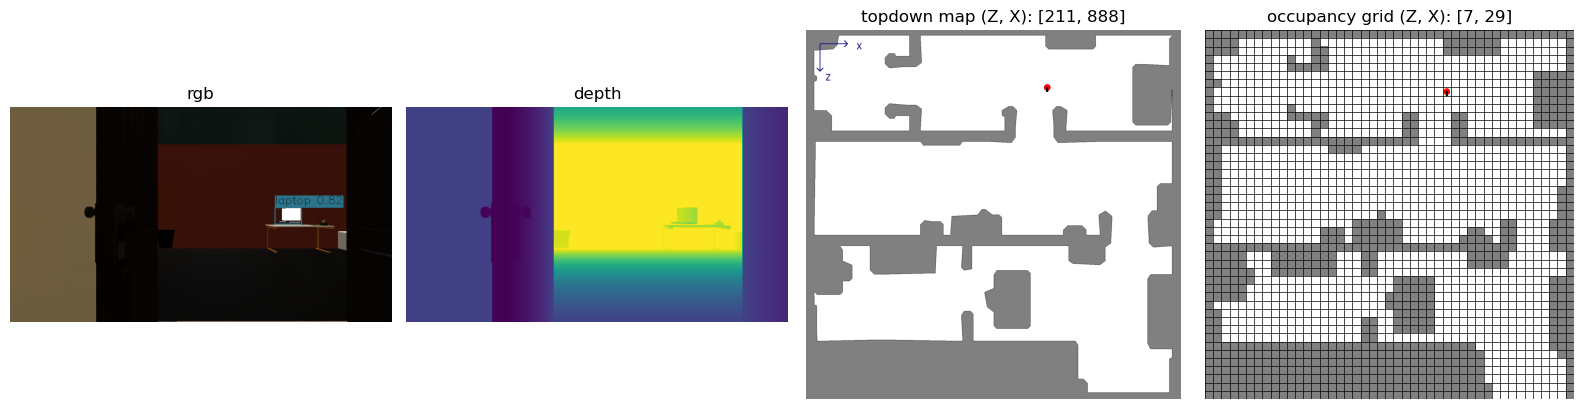


Target object <laptop> found after 190 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 190
Travelled distance: 43.94 m
Computed location error: 0.227 m
Episode reward: -0.90


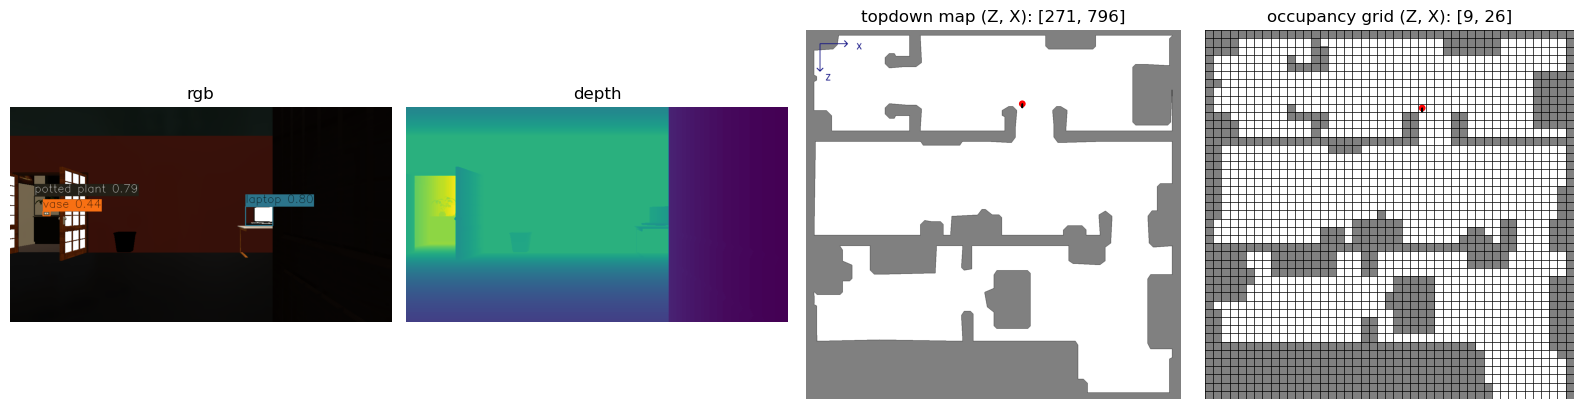


Target object <laptop> found after 188 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 188
Travelled distance: 45.15 m
Computed location error: 0.227 m
Episode reward: -0.88


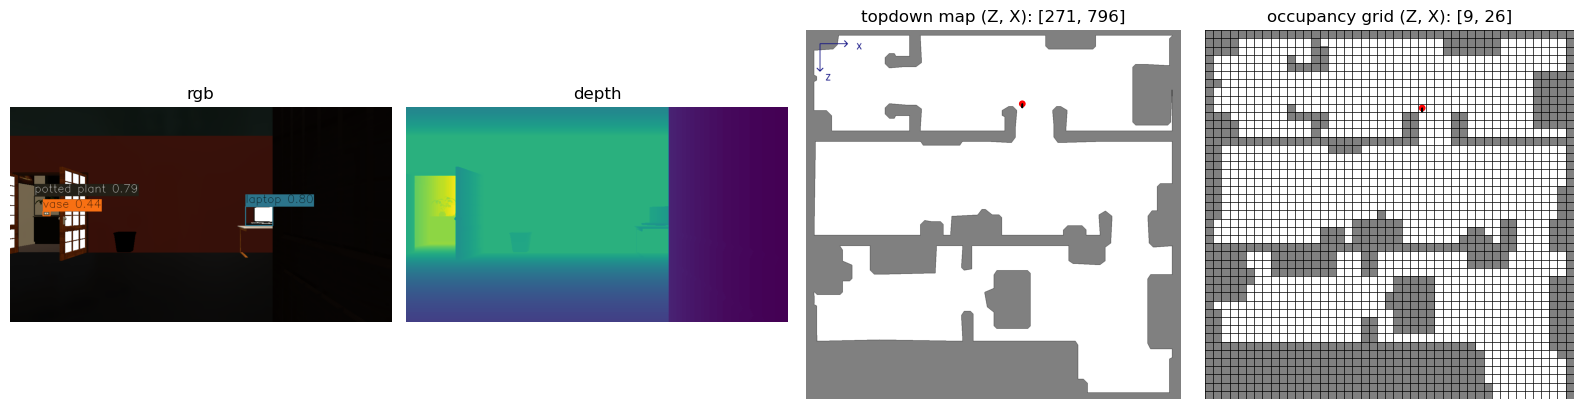


Target object <laptop> found after 187 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 187
Travelled distance: 42.07 m
Computed location error: 0.227 m
Episode reward: -0.87


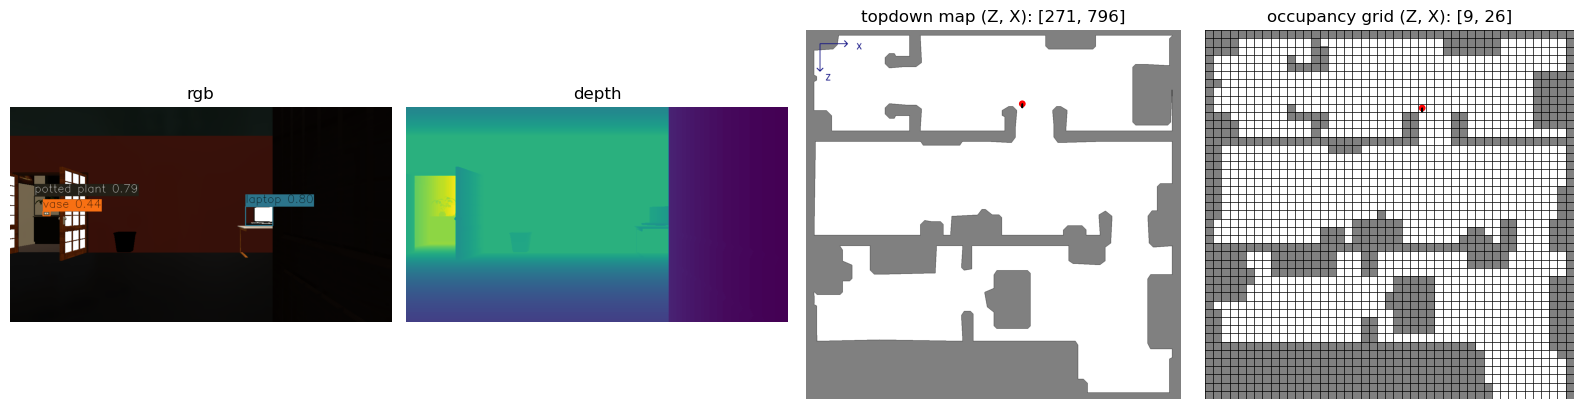


Target object <laptop> found after 15 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 15
Travelled distance: 3.67 m
Computed location error: 0.202 m
Episode reward: 0.85


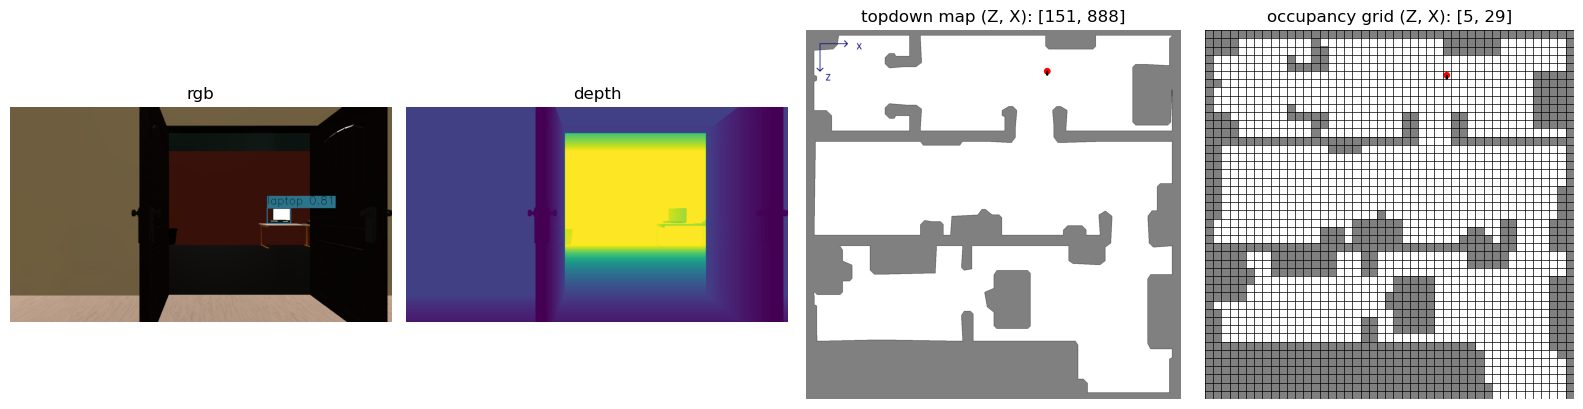


Target object <laptop> found after 93 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 93
Travelled distance: 22.23 m
Computed location error: 0.200 m
Episode reward: 0.07


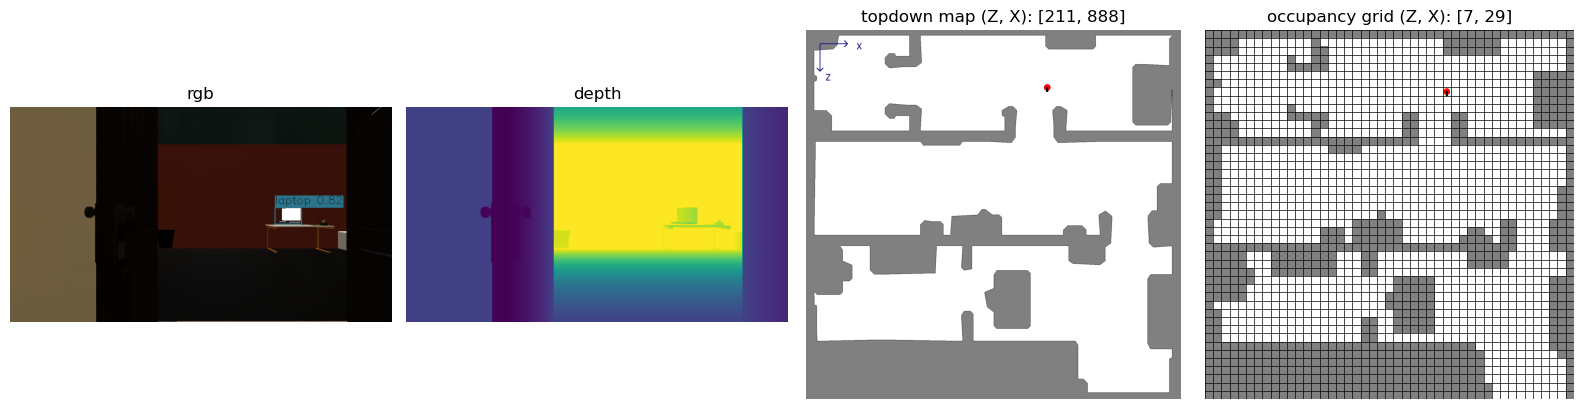


Target object <laptop> found after 172 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 172
Travelled distance: 39.04 m
Computed location error: 0.227 m
Episode reward: -0.72


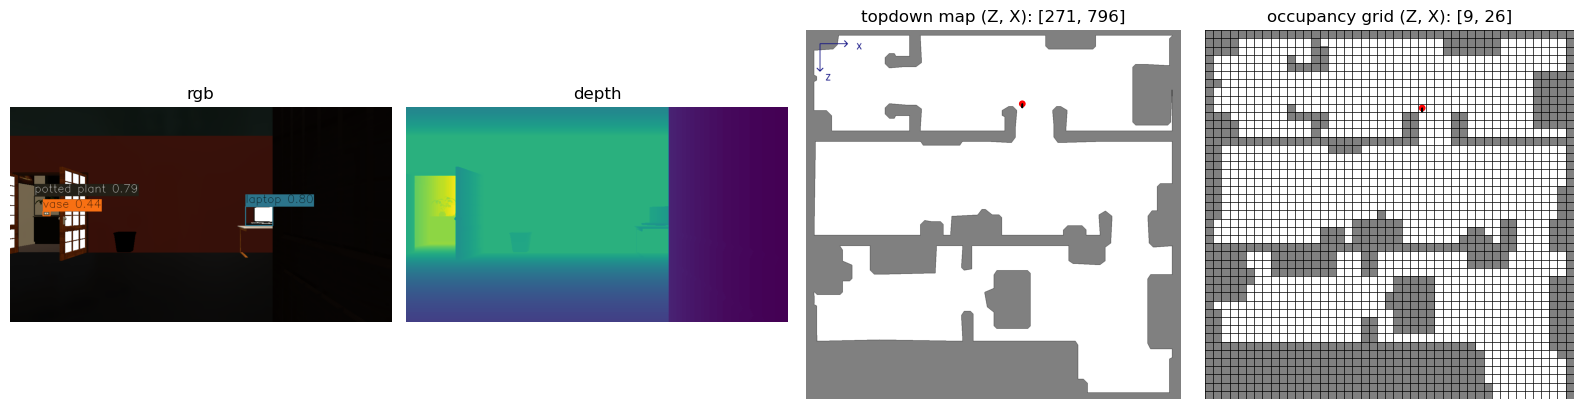


Target object <laptop> found after 190 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 190
Travelled distance: 45.13 m
Computed location error: 0.227 m
Episode reward: -0.90


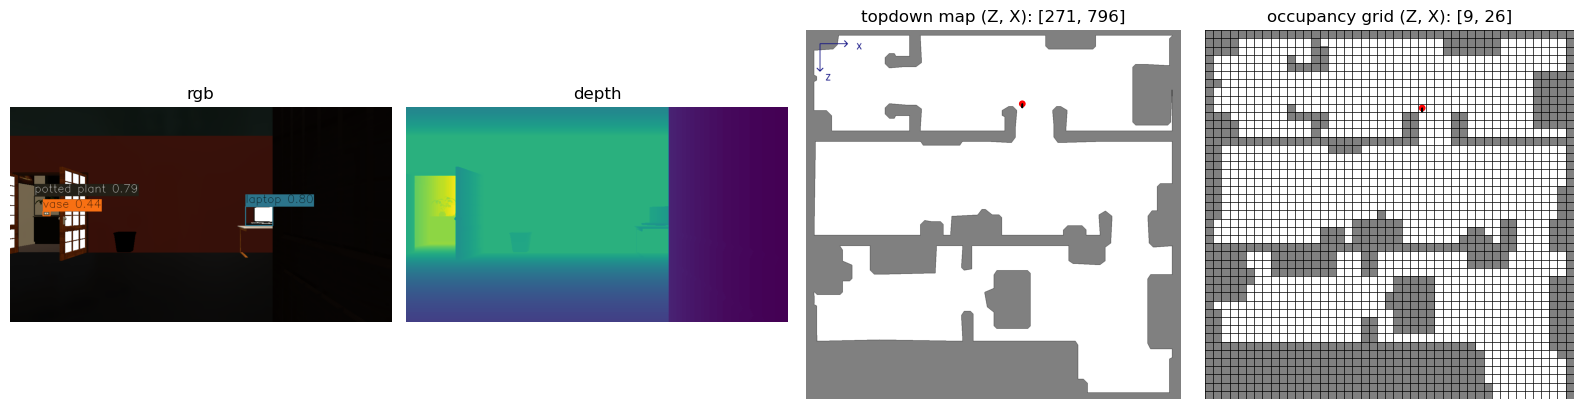


Target object <laptop> found after 50 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 50
Travelled distance: 9.74 m
Computed location error: 0.200 m
Episode reward: 0.50


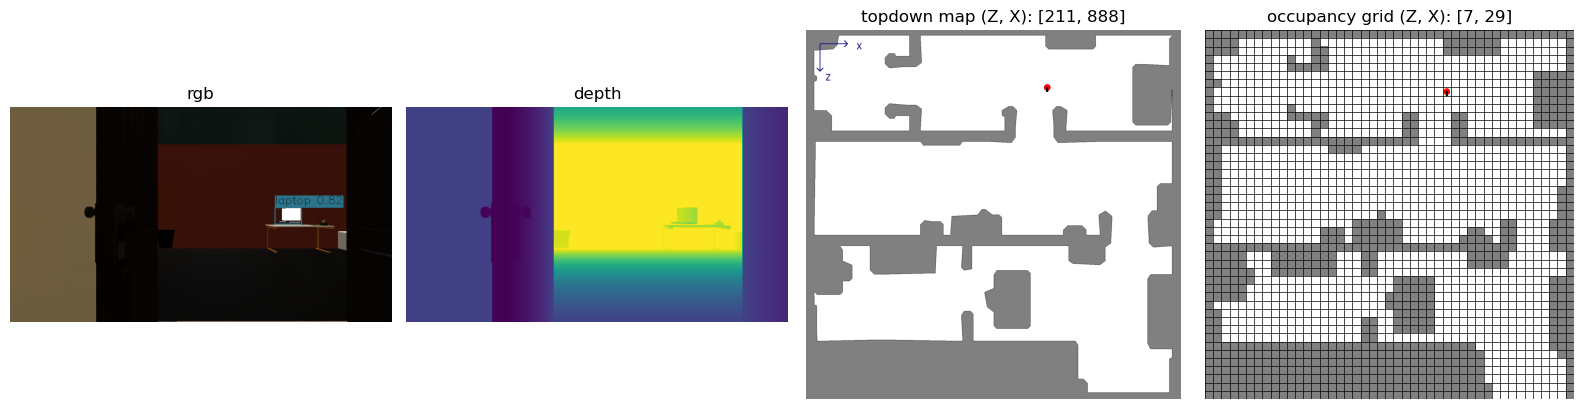


Target object <laptop> found after 113 actions!
Found location: [-7.228852035601935, 0.0, 6.930897272543775]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 113
Travelled distance: 27.40 m
Computed location error: 0.225 m
Episode reward: -0.13


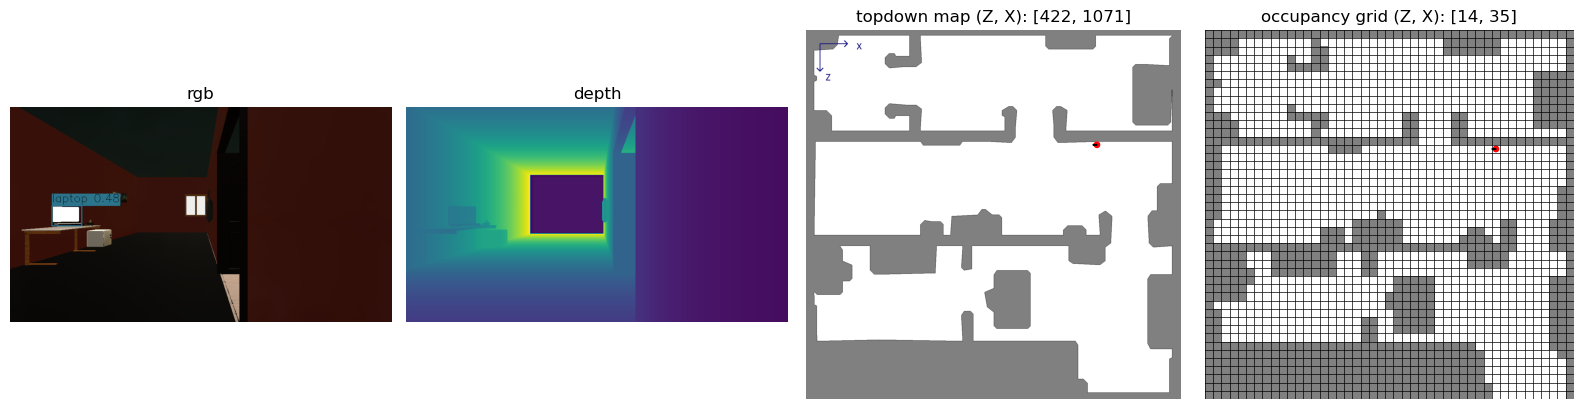


Target object <laptop> found after 18 actions!
Found location: [    -7.1348     0.02657      7.2345]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 18
Travelled distance: 4.89 m
Computed location error: 0.195 m
Episode reward: 0.82


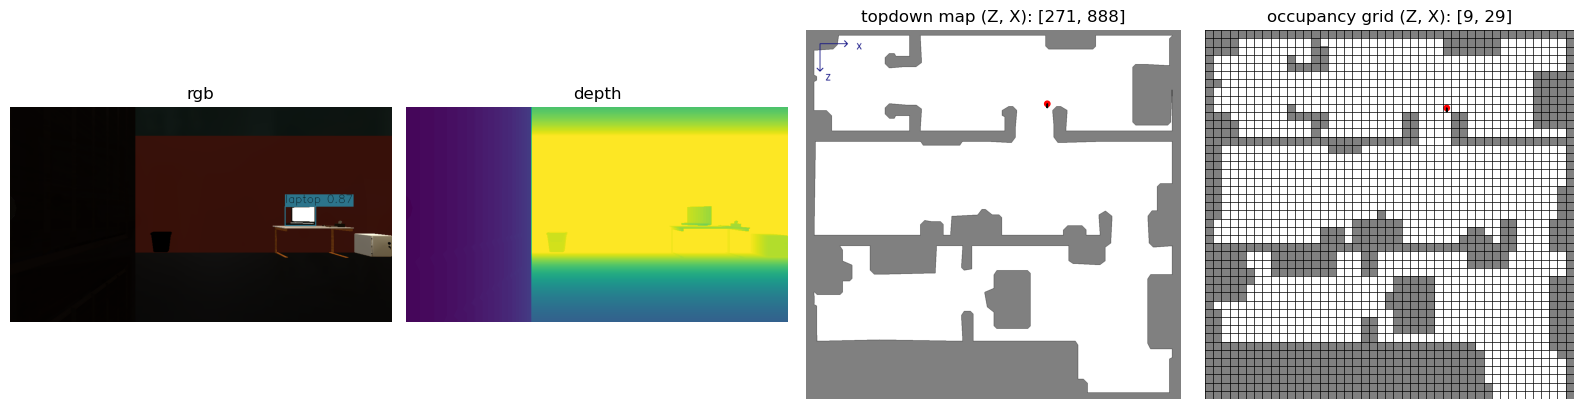


Target object <laptop> found after 17 actions!
Found location: [    -7.1323    0.028353      7.2366]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 17
Travelled distance: 4.59 m
Computed location error: 0.196 m
Episode reward: 0.83


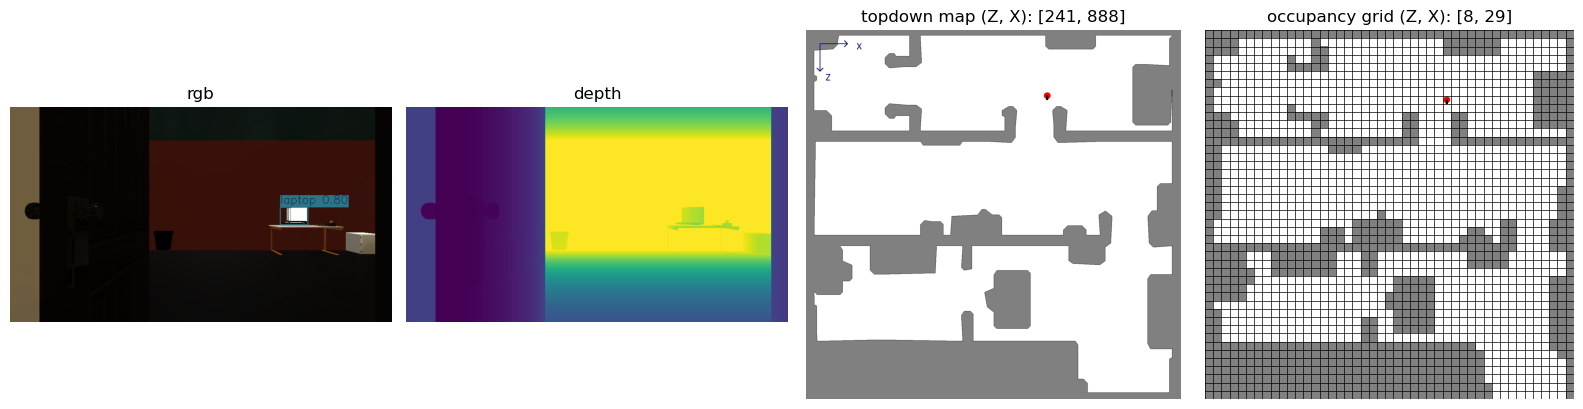


Target object <laptop> found after 30 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 30
Travelled distance: 7.03 m
Computed location error: 0.200 m
Episode reward: 0.70


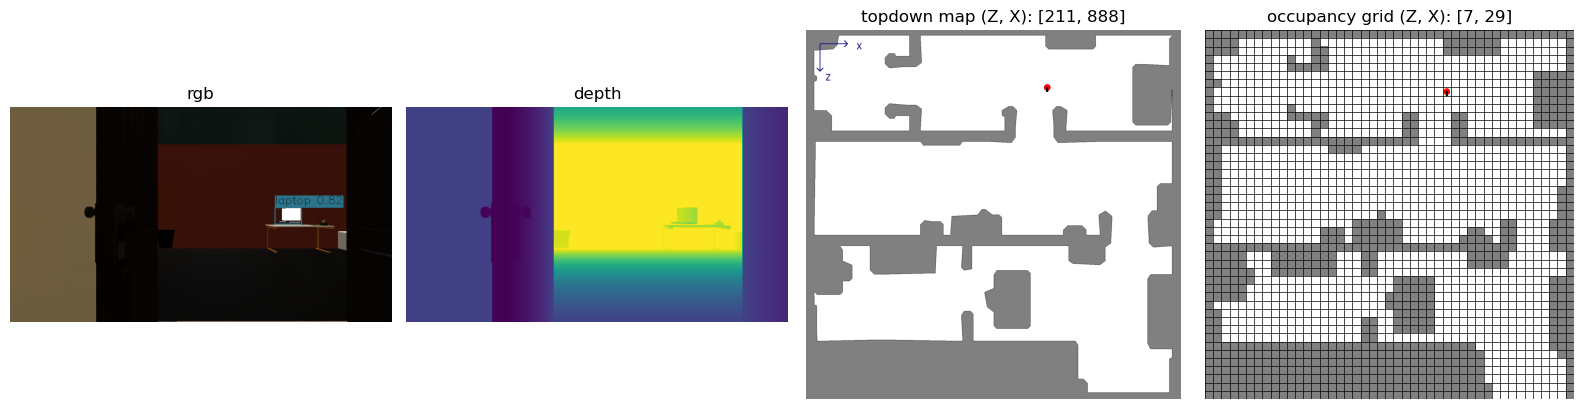


Target object <laptop> found after 193 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 193
Travelled distance: 46.68 m
Computed location error: 0.227 m
Episode reward: -0.93


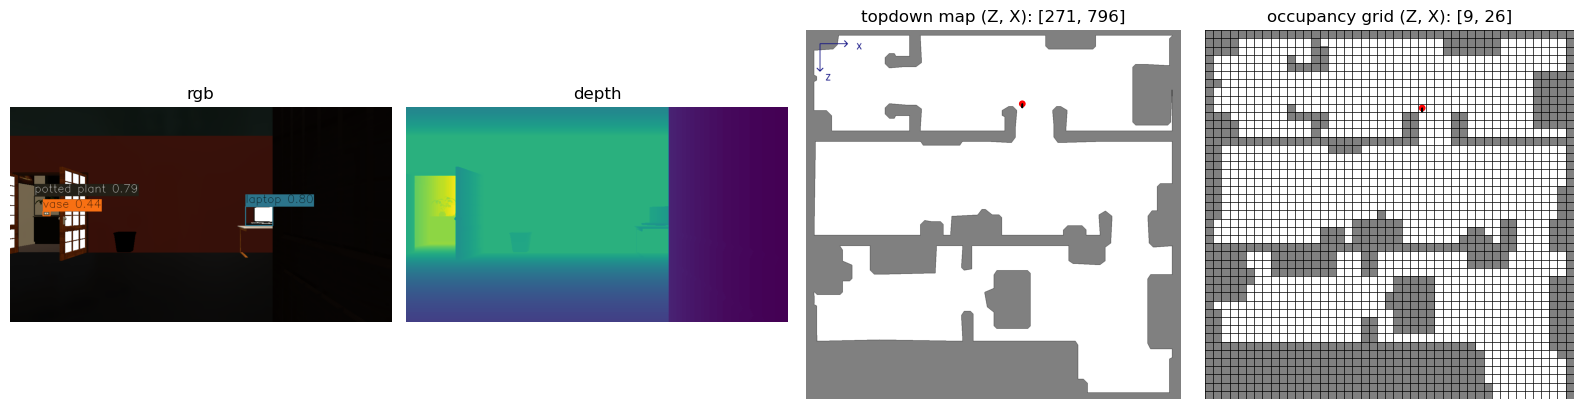


Target object <laptop> found after 181 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 181
Travelled distance: 43.64 m
Computed location error: 0.200 m
Episode reward: -0.81


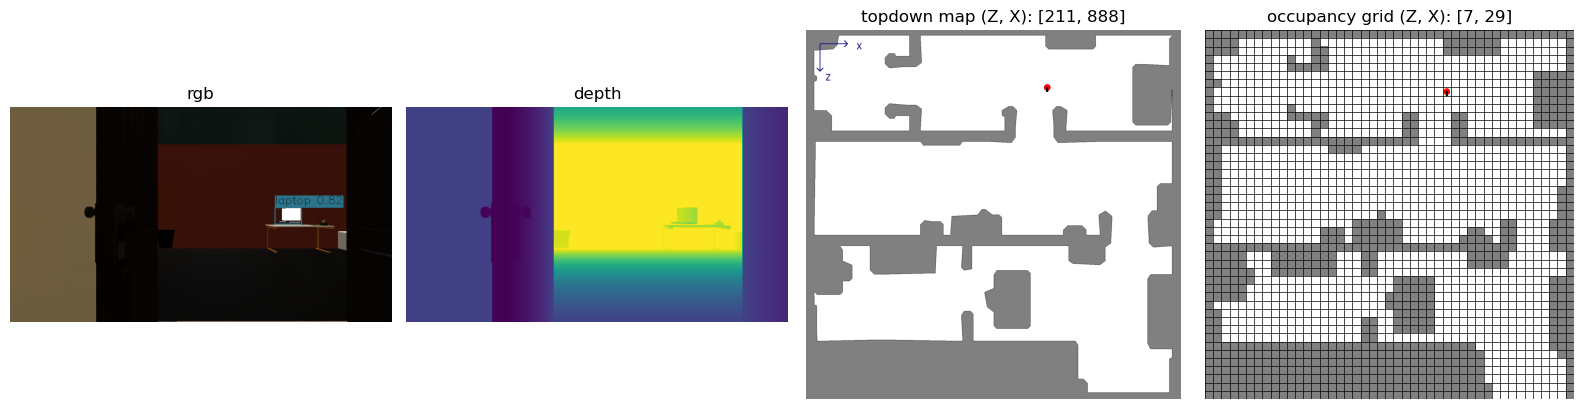


Target object <laptop> found after 26 actions!
Found location: [    -7.1323    0.028353      7.2366]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 26
Travelled distance: 7.33 m
Computed location error: 0.196 m
Episode reward: 0.74


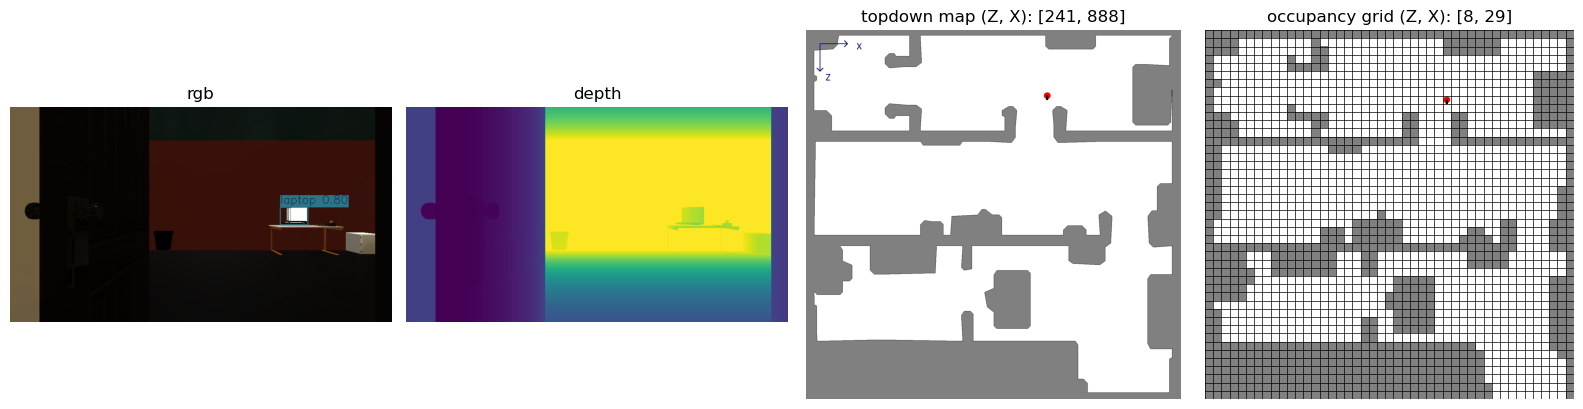


Target object <laptop> found after 208 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 208
Travelled distance: 47.88 m
Computed location error: 0.200 m
Episode reward: -1.08


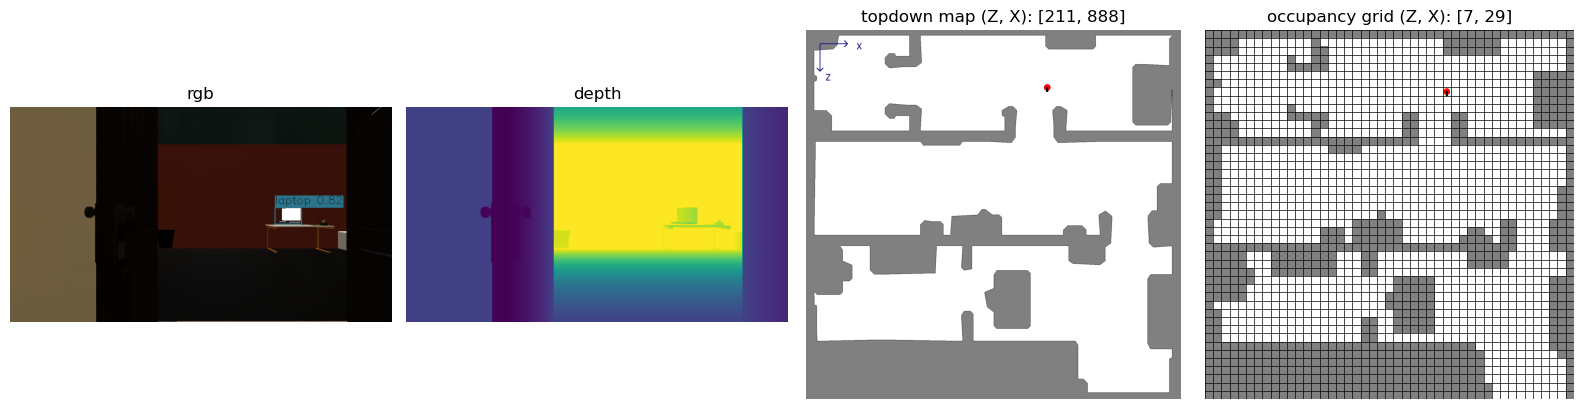


Target object <laptop> found after 188 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 188
Travelled distance: 44.50 m
Computed location error: 0.200 m
Episode reward: -0.88


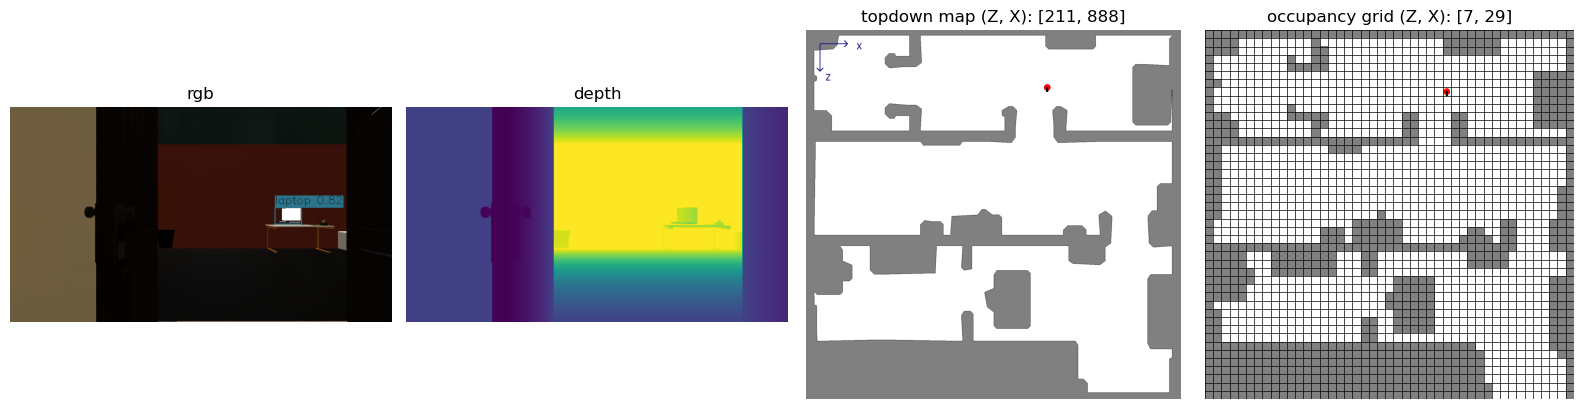


Target object <laptop> found after 139 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 139
Travelled distance: 32.34 m
Computed location error: 0.200 m
Episode reward: -0.39


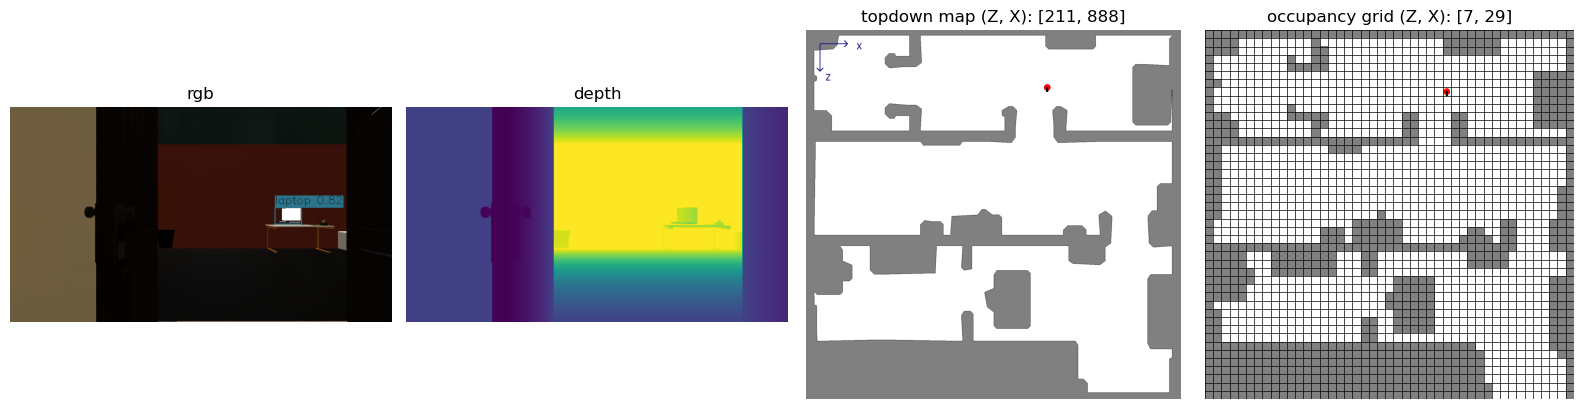


Target object <laptop> found after 173 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 173
Travelled distance: 40.86 m
Computed location error: 0.227 m
Episode reward: -0.73


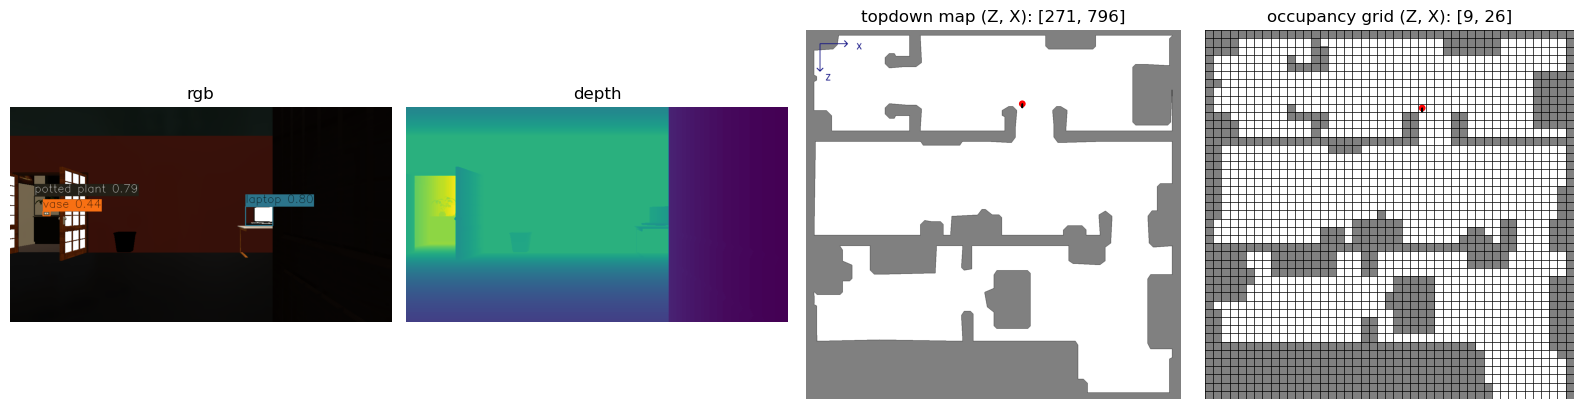


Target object <laptop> found after 179 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 179
Travelled distance: 42.39 m
Computed location error: 0.227 m
Episode reward: -0.79


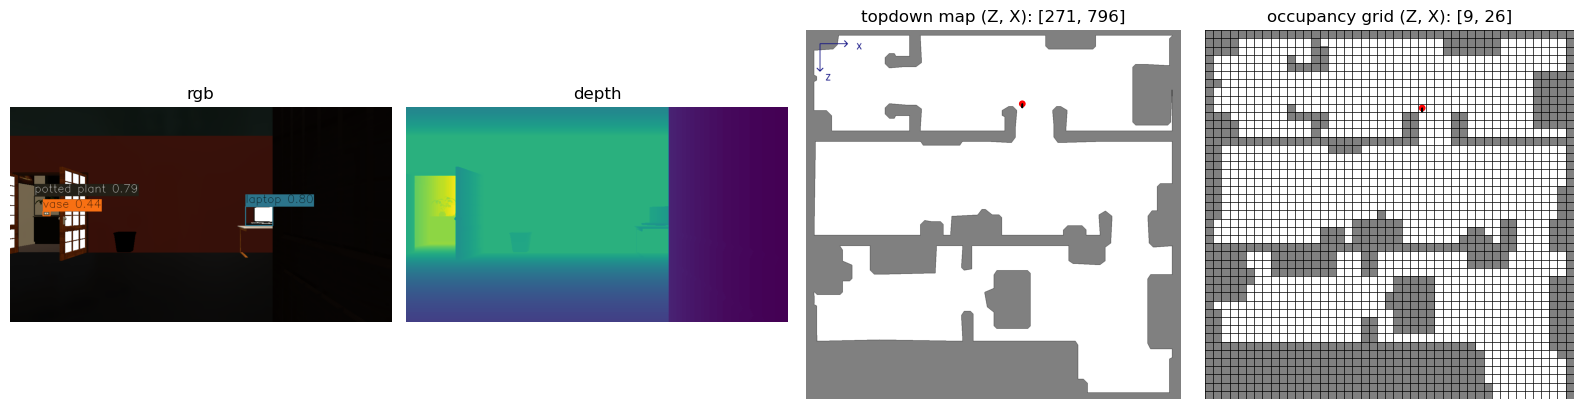


Target object <laptop> found after 169 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 169
Travelled distance: 38.74 m
Computed location error: 0.227 m
Episode reward: -0.69


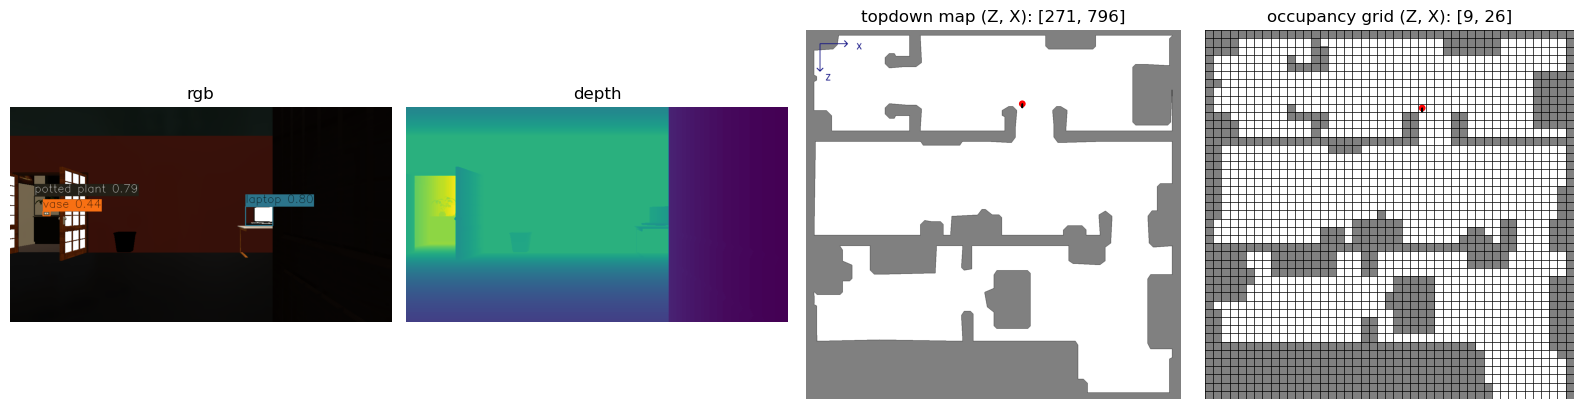


Target object <laptop> found after 184 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 184
Travelled distance: 43.93 m
Computed location error: 0.227 m
Episode reward: -0.84


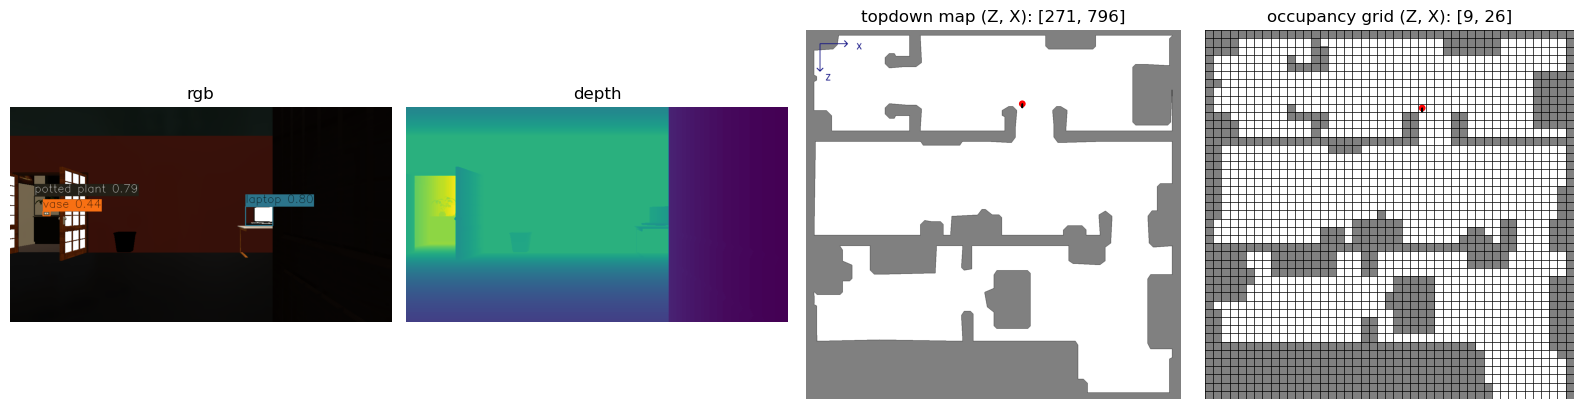


Target object <laptop> found after 195 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 195
Travelled distance: 47.00 m
Computed location error: 0.227 m
Episode reward: -0.95


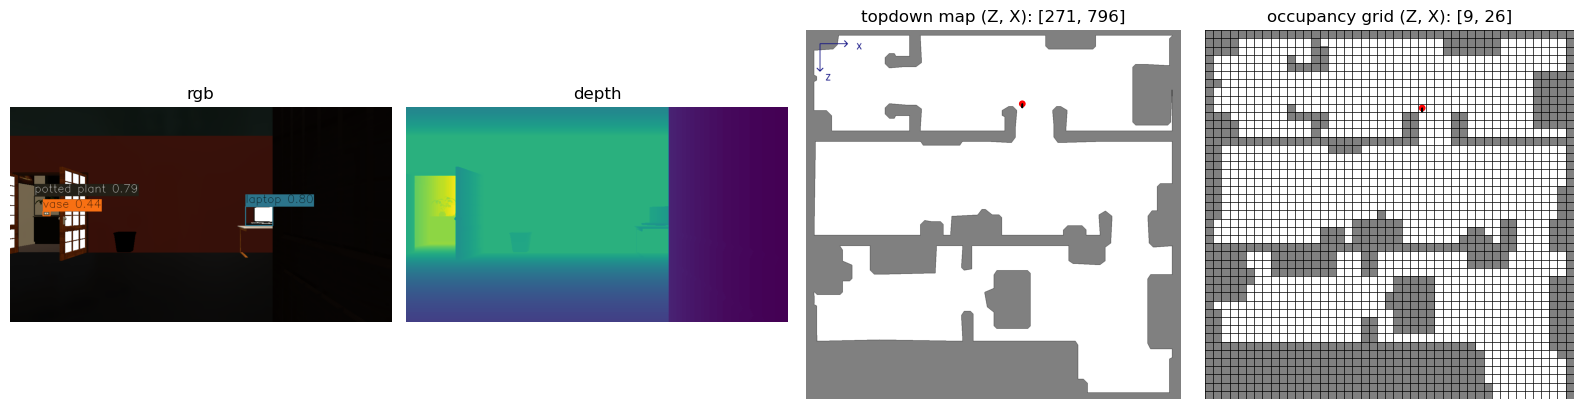


Target object <laptop> found after 63 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 63
Travelled distance: 14.01 m
Computed location error: 0.200 m
Episode reward: 0.37


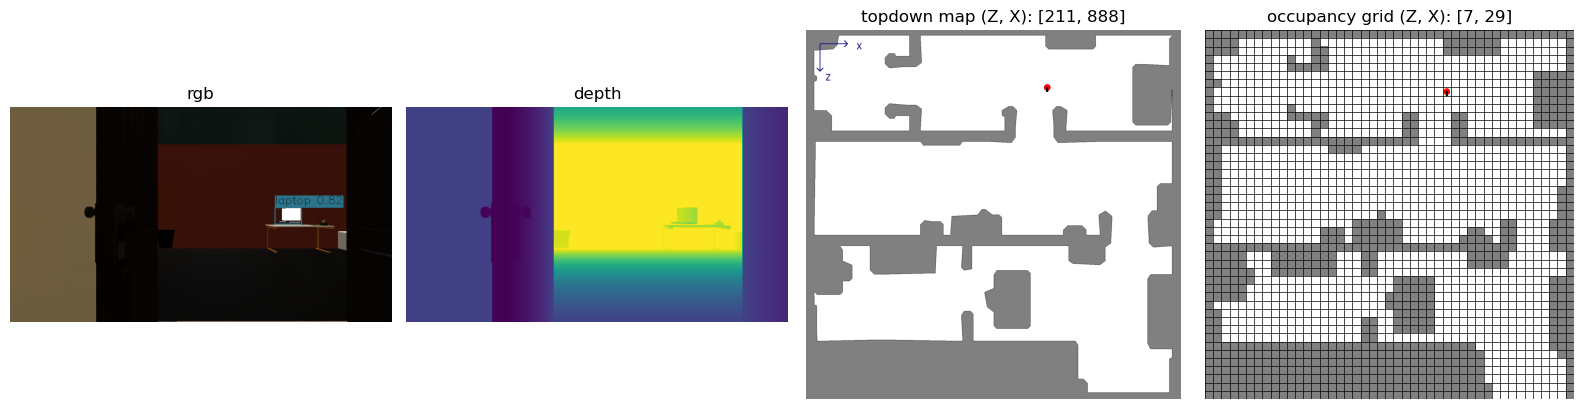


Target object <laptop> found after 193 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 193
Travelled distance: 45.17 m
Computed location error: 0.227 m
Episode reward: -0.93


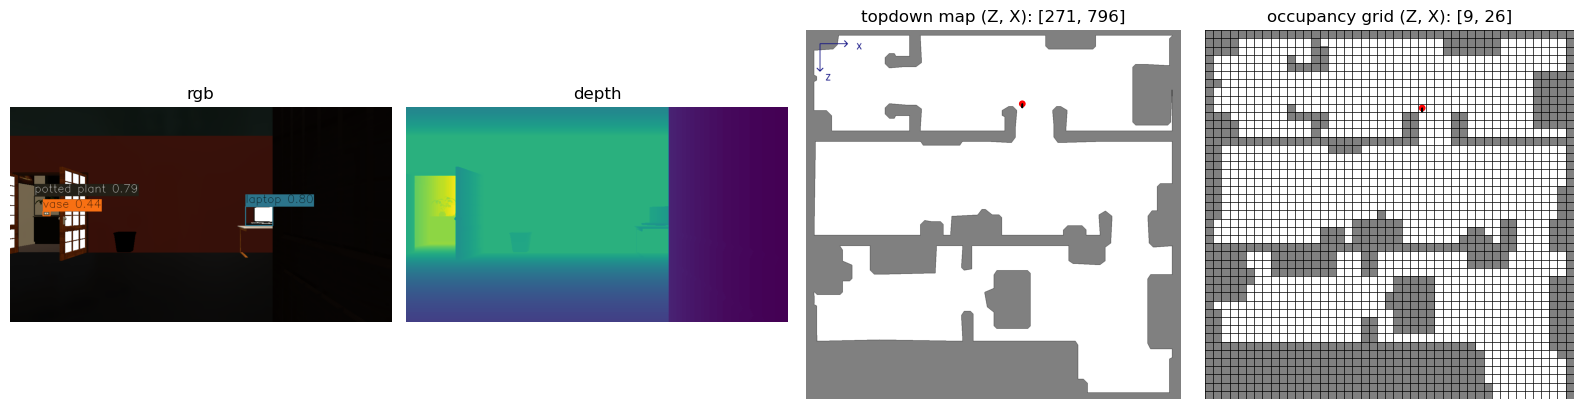


Target object <laptop> found after 191 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 191
Travelled distance: 46.08 m
Computed location error: 0.227 m
Episode reward: -0.91


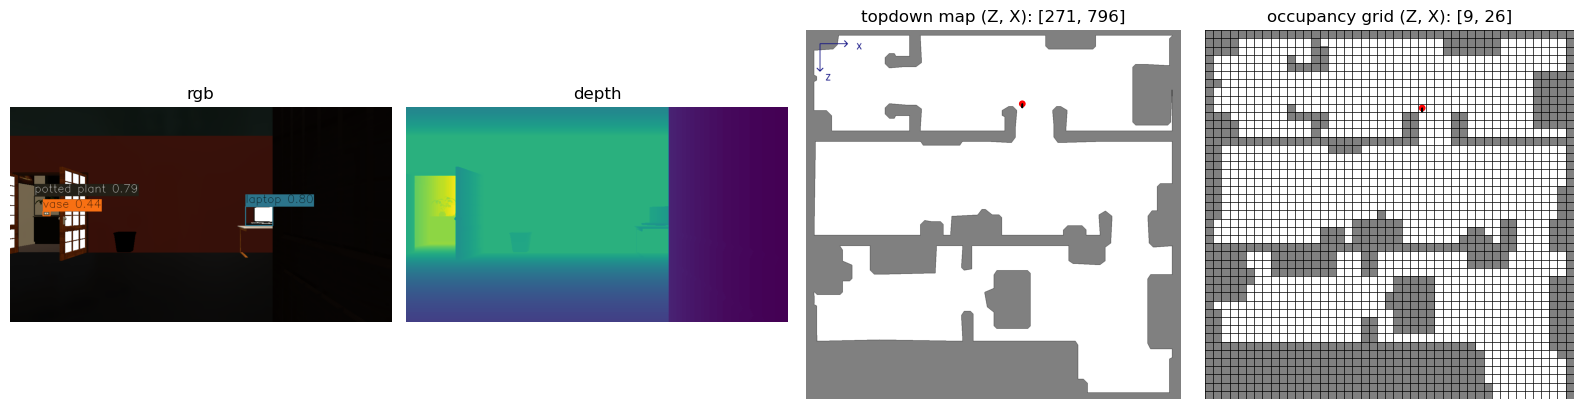


Target object <laptop> found after 7 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 7
Travelled distance: 1.84 m
Computed location error: 0.202 m
Episode reward: 0.93


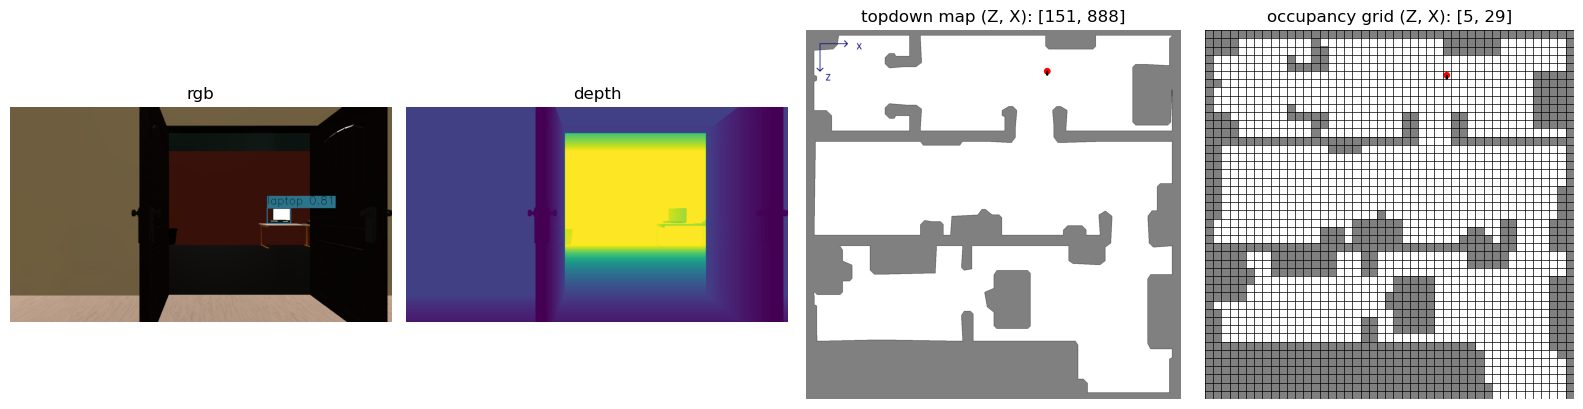


Target object <laptop> found after 1 actions!
Found location: [    -7.0149    0.067063      7.3571]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 1
Travelled distance: 0.00 m
Computed location error: 0.298 m
Episode reward: 0.99


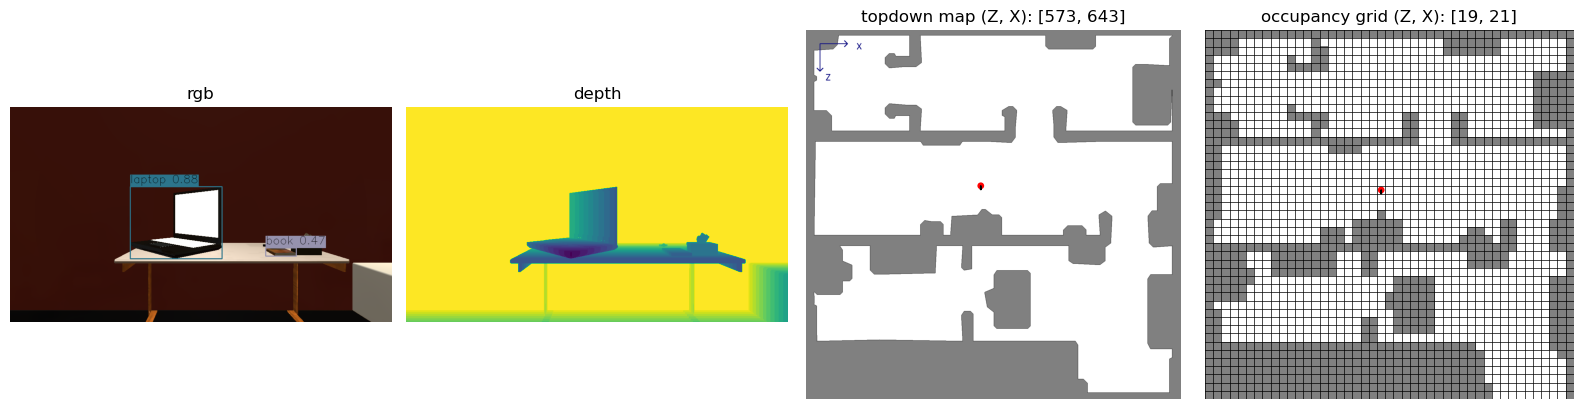


Target object <laptop> found after 6 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 6
Travelled distance: 1.22 m
Computed location error: 0.200 m
Episode reward: 0.94


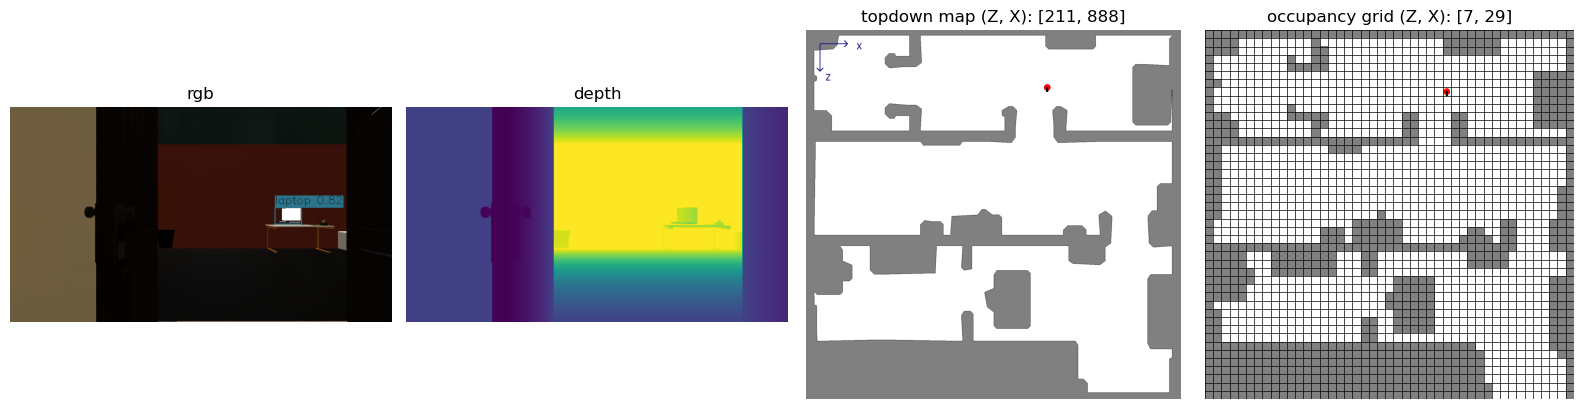


Target object <laptop> found after 30 actions!
Found location: [    -7.1323    0.028353      7.2366]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 30
Travelled distance: 7.64 m
Computed location error: 0.196 m
Episode reward: 0.70


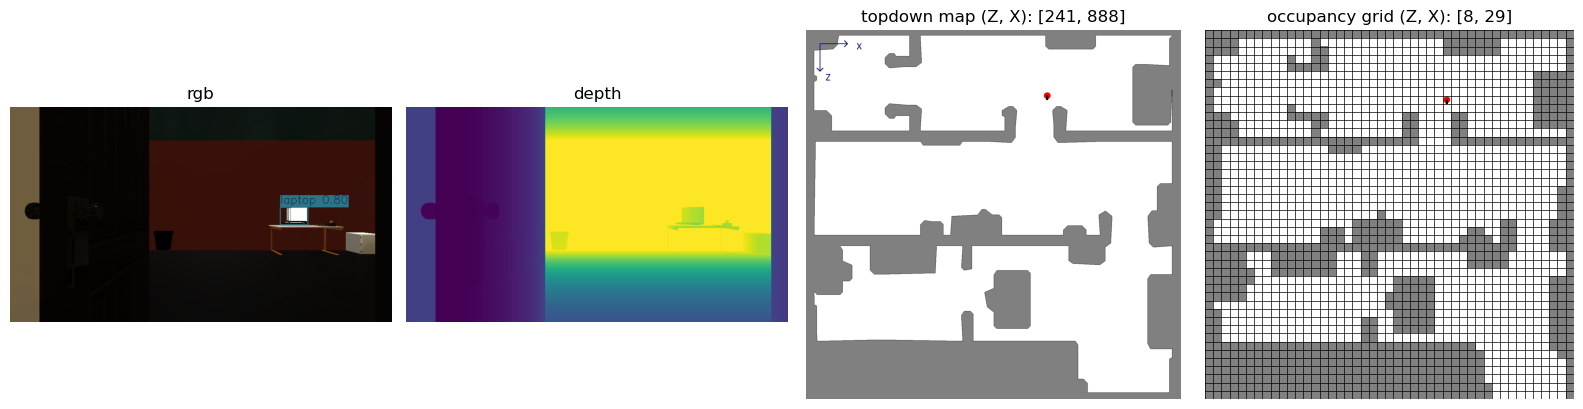


Target object <laptop> found after 8 actions!
Found location: [    -7.1348     0.02657      7.2345]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 8
Travelled distance: 2.14 m
Computed location error: 0.195 m
Episode reward: 0.92


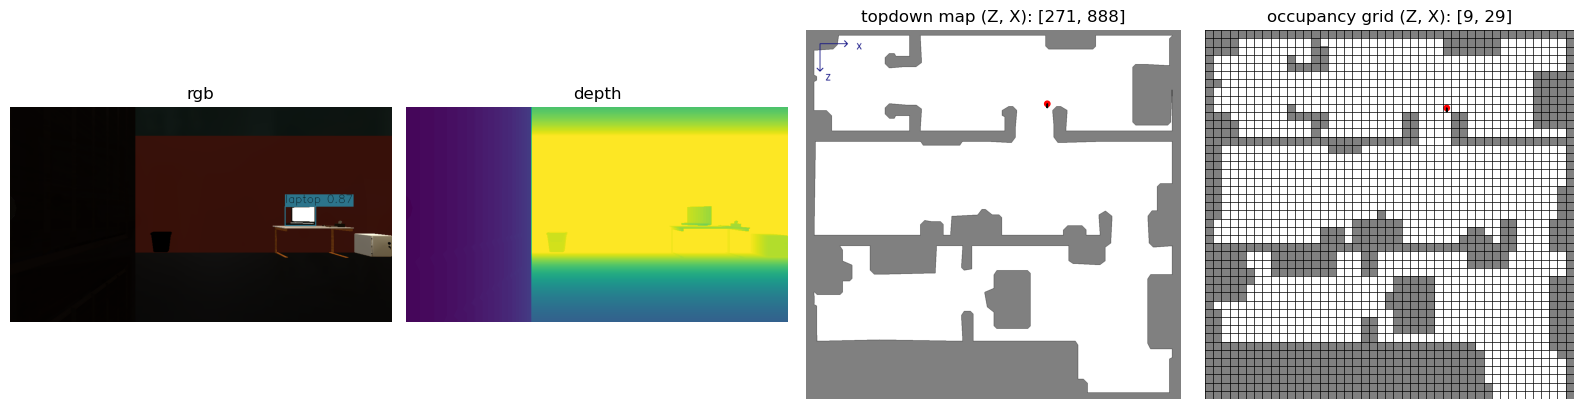


Target object <laptop> found after 30 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 30
Travelled distance: 7.95 m
Computed location error: 0.202 m
Episode reward: 0.70


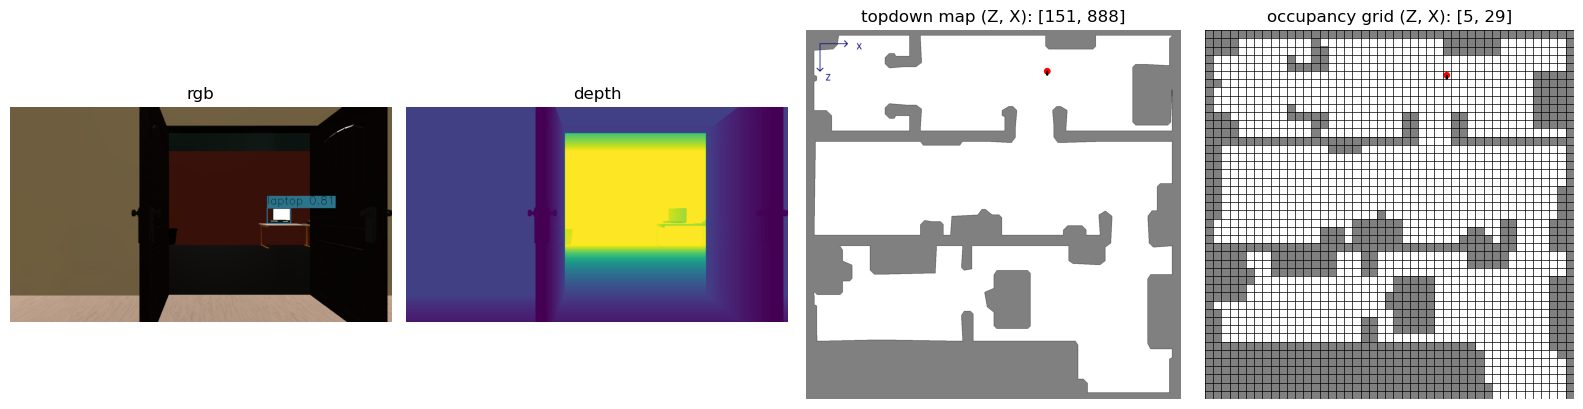


Target object <laptop> found after 5 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 5
Travelled distance: 0.91 m
Computed location error: 0.202 m
Episode reward: 0.95


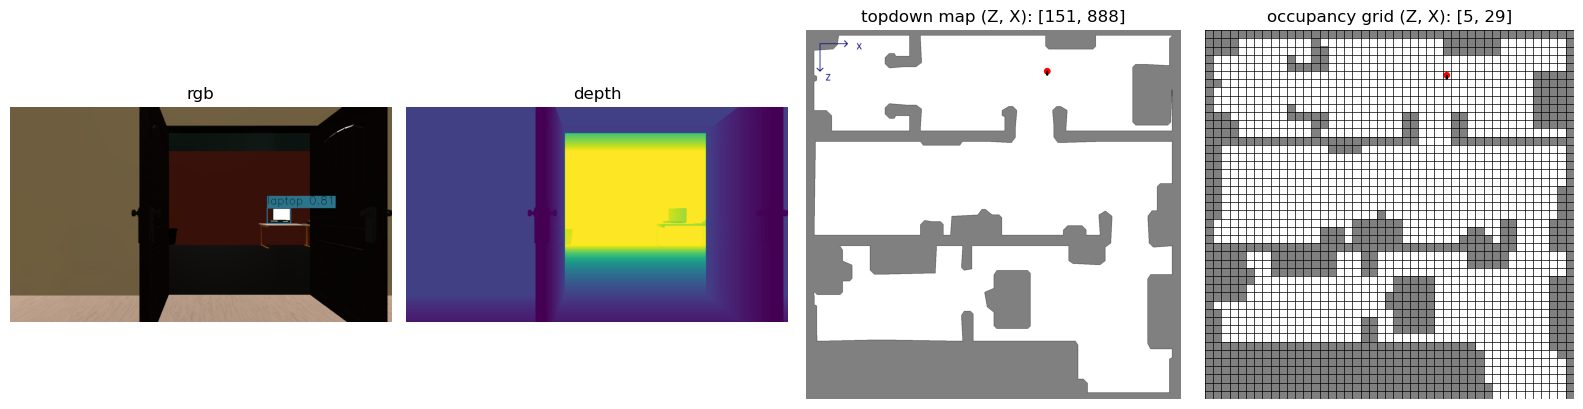


Target object <laptop> found after 176 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 176
Travelled distance: 40.90 m
Computed location error: 0.227 m
Episode reward: -0.76


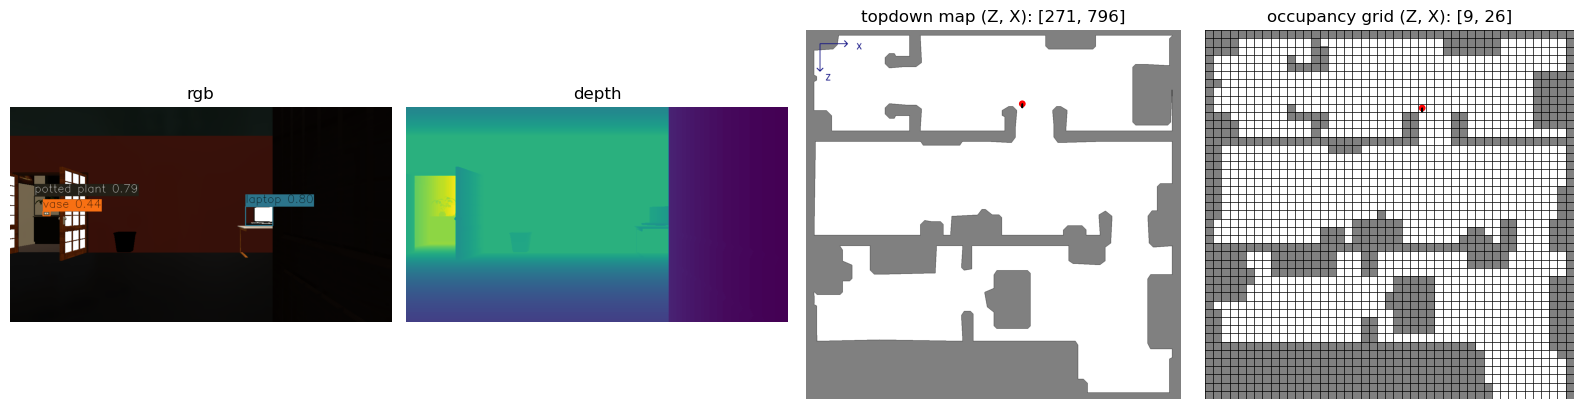


Target object <laptop> found after 231 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 231
Travelled distance: 52.14 m
Computed location error: 0.227 m
Episode reward: -1.31


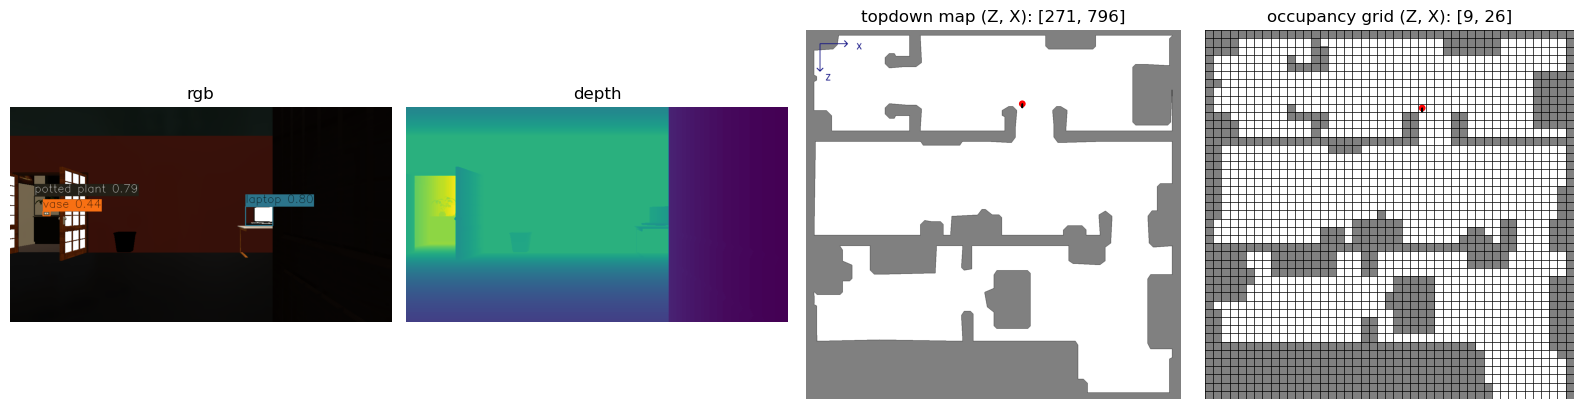


Target object <laptop> found after 44 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 44
Travelled distance: 10.99 m
Computed location error: 0.223 m
Episode reward: 0.56


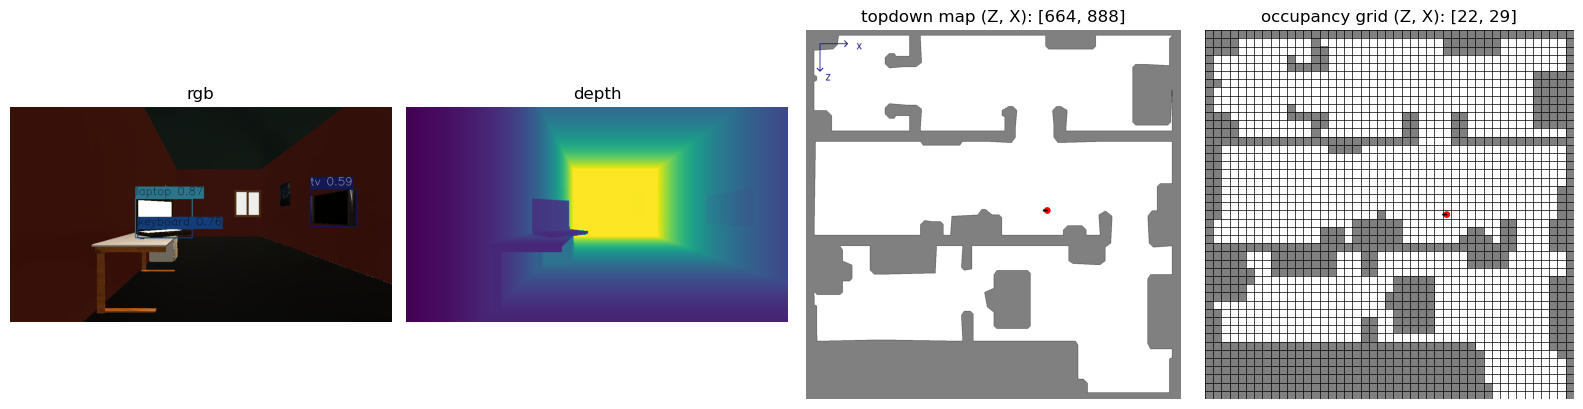


Target object <laptop> found after 10 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 10
Travelled distance: 2.45 m
Computed location error: 0.202 m
Episode reward: 0.90


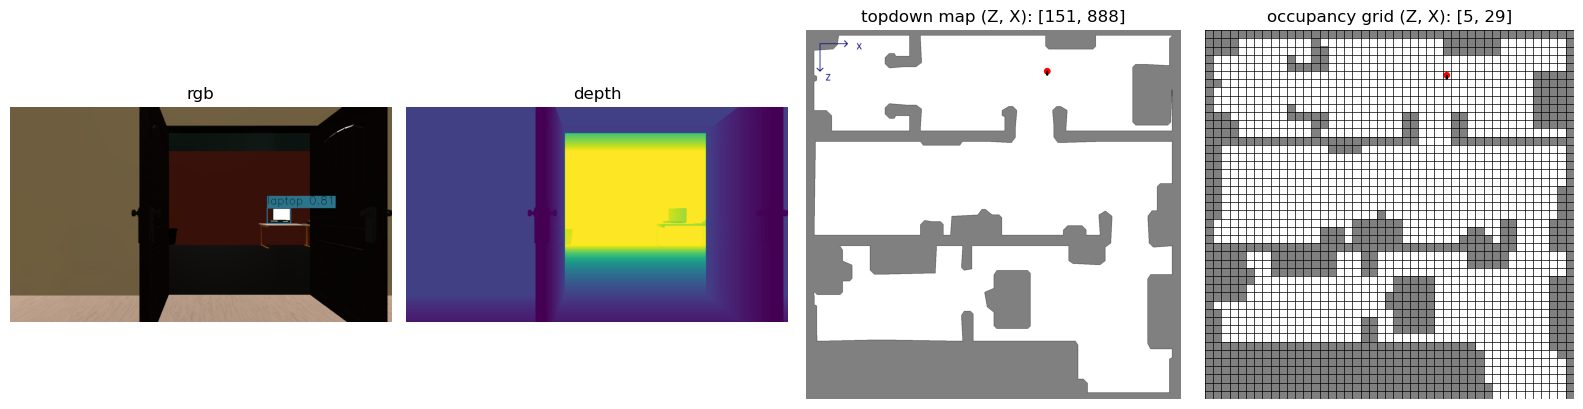


Target object <laptop> found after 104 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 104
Travelled distance: 25.66 m
Computed location error: 0.223 m
Episode reward: -0.04


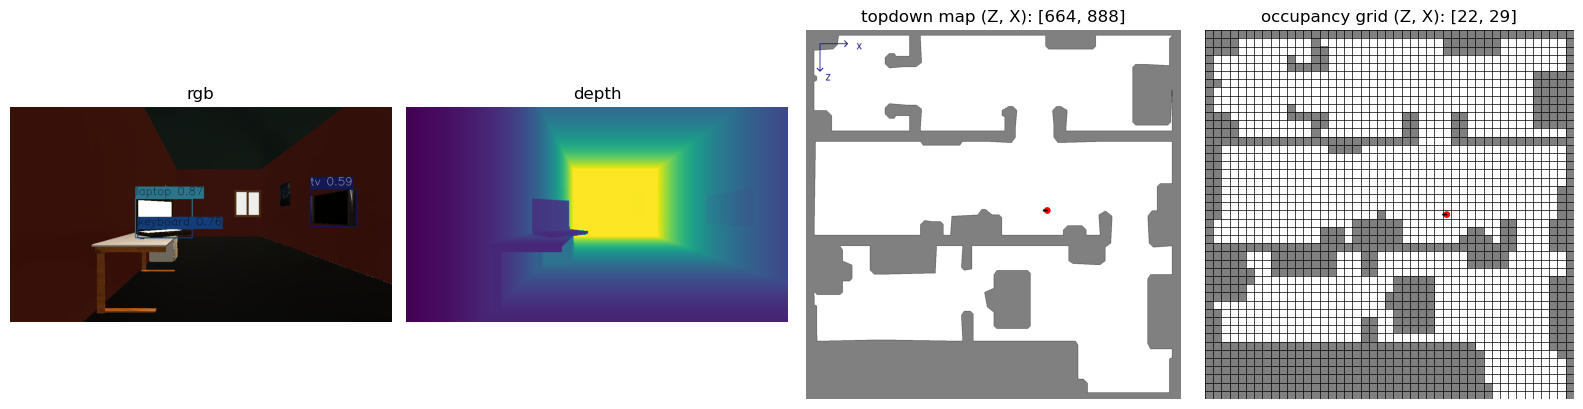


Target object <laptop> found after 10 actions!
Found location: [    -7.1348     0.02657      7.2345]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 10
Travelled distance: 2.14 m
Computed location error: 0.195 m
Episode reward: 0.90


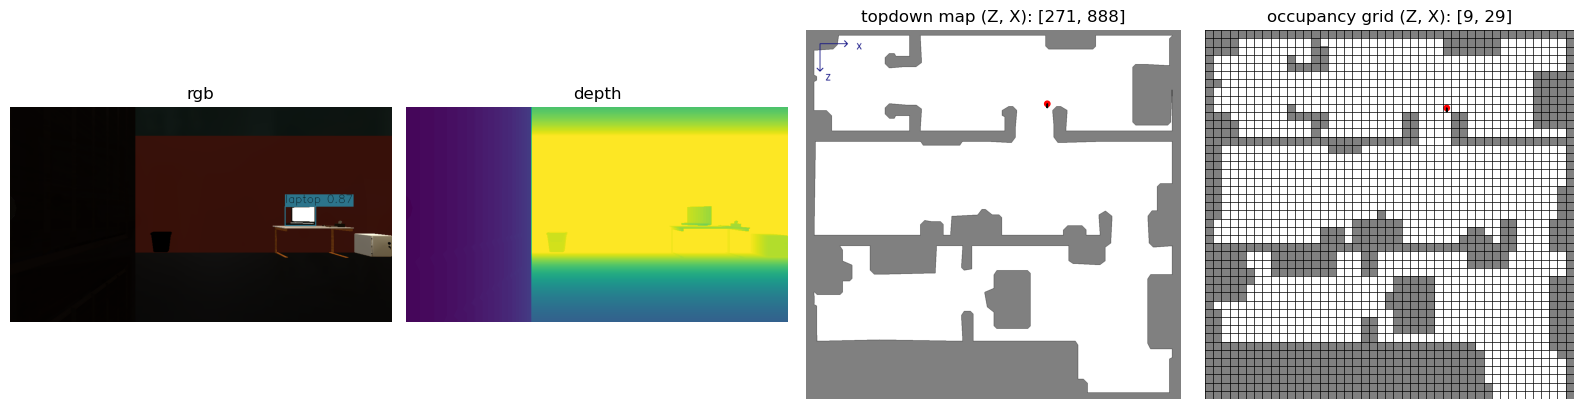


Target object <laptop> found after 150 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 150
Travelled distance: 35.71 m
Computed location error: 0.200 m
Episode reward: -0.50


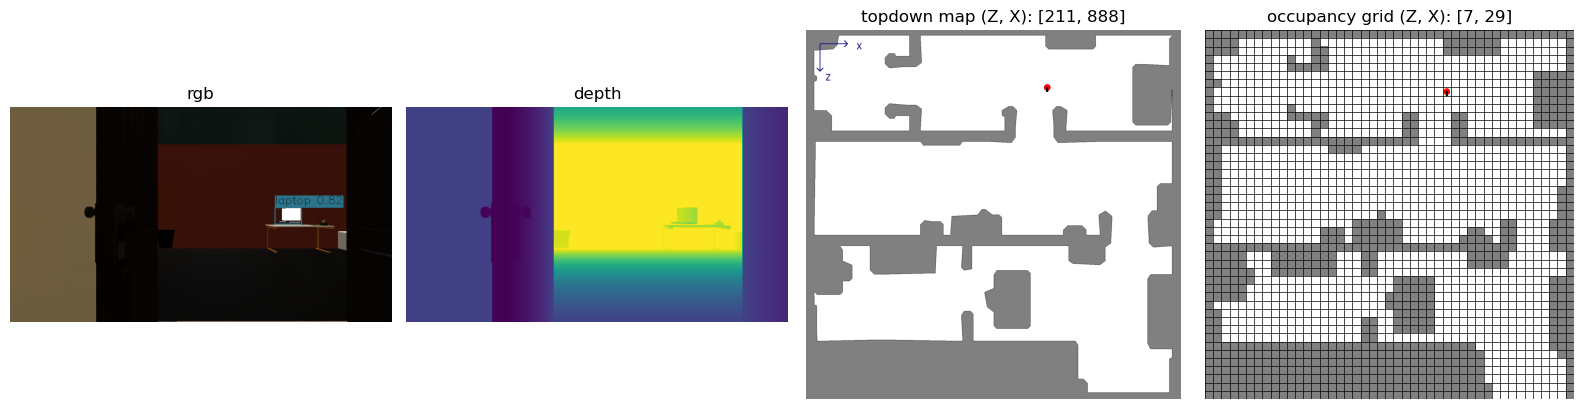


Target object <laptop> found after 121 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 121
Travelled distance: 27.44 m
Computed location error: 0.227 m
Episode reward: -0.21


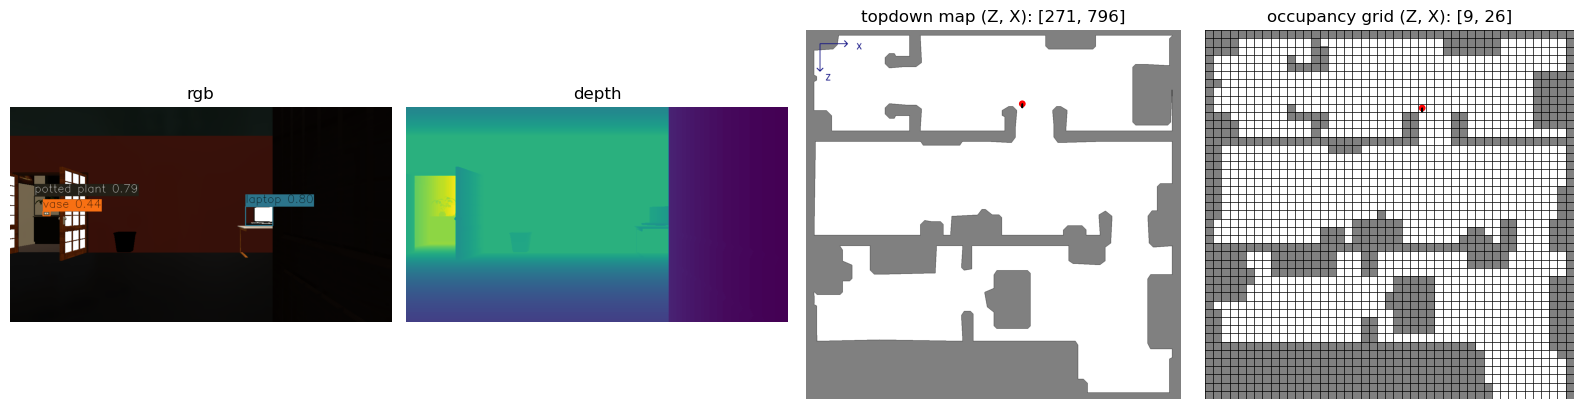


Target object <laptop> found after 17 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 17
Travelled distance: 4.59 m
Computed location error: 0.202 m
Episode reward: 0.83


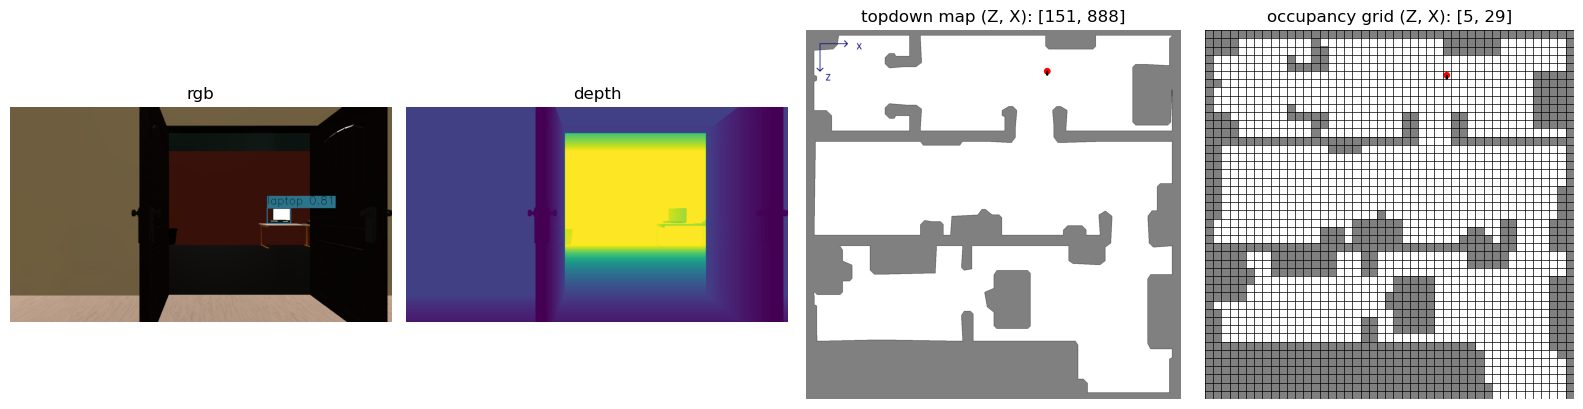


Target object <laptop> found after 9 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 9
Travelled distance: 2.45 m
Computed location error: 0.200 m
Episode reward: 0.91


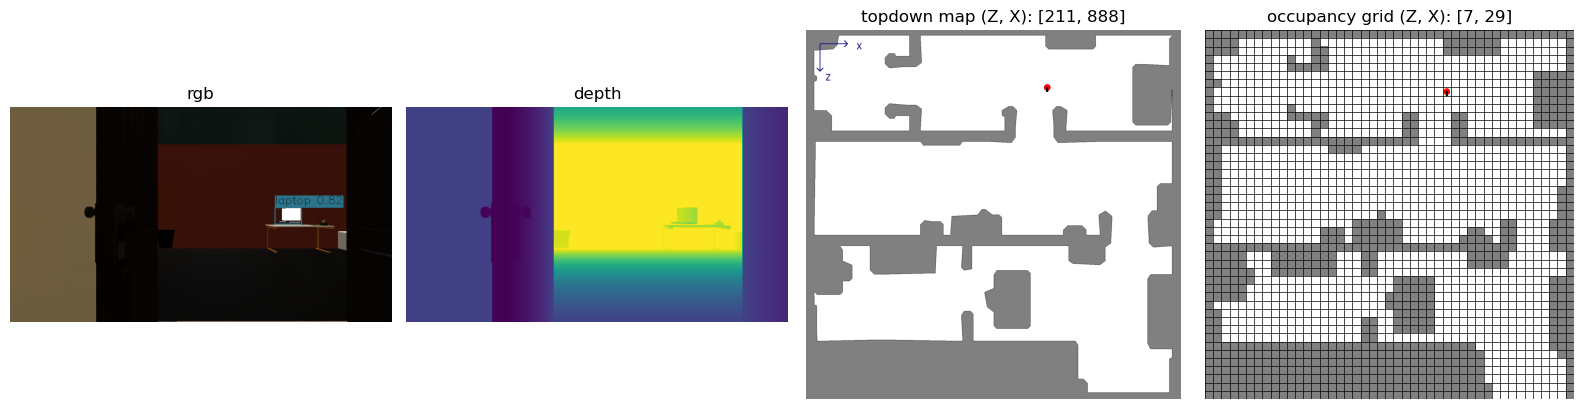


Target object <laptop> found after 13 actions!
Found location: [    -7.1348     0.02657      7.2345]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 13
Travelled distance: 3.06 m
Computed location error: 0.195 m
Episode reward: 0.87


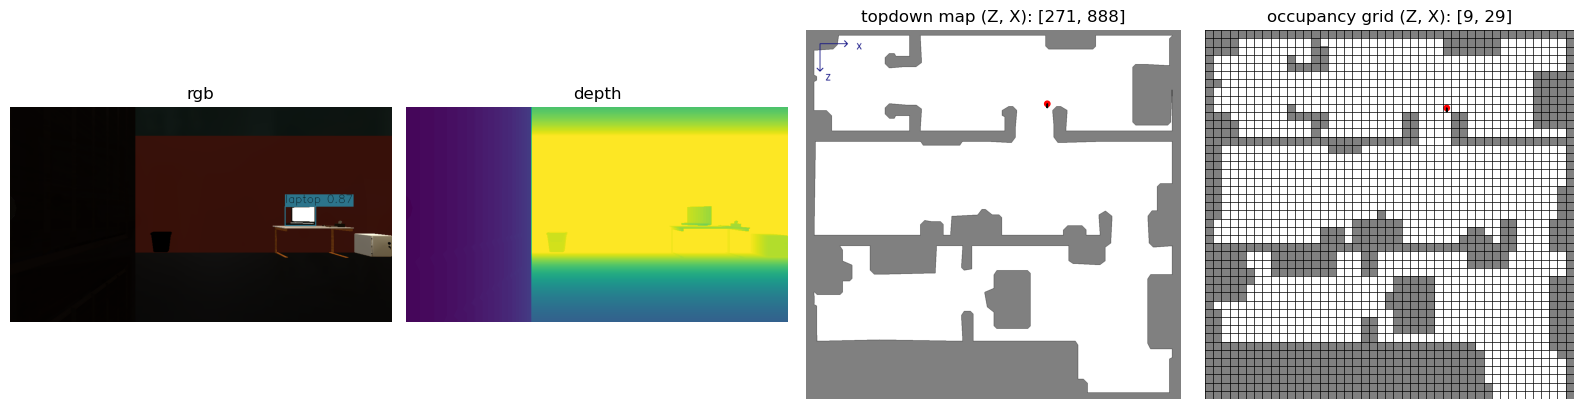


Target object <laptop> found after 180 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 180
Travelled distance: 43.03 m
Computed location error: 0.227 m
Episode reward: -0.80


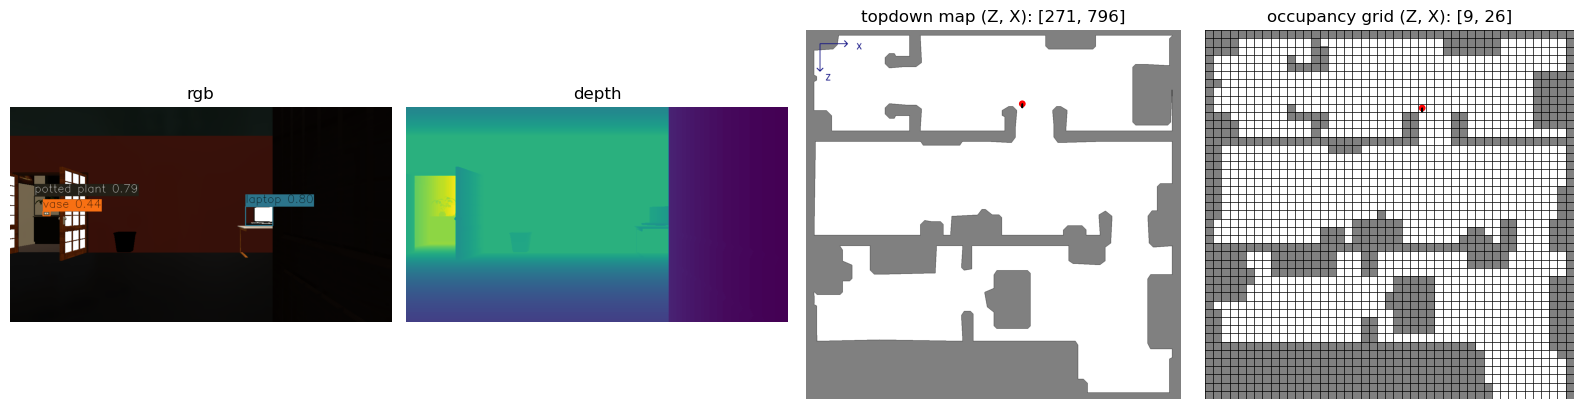


Target object <laptop> found after 21 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 21
Travelled distance: 4.56 m
Computed location error: 0.227 m
Episode reward: 0.79


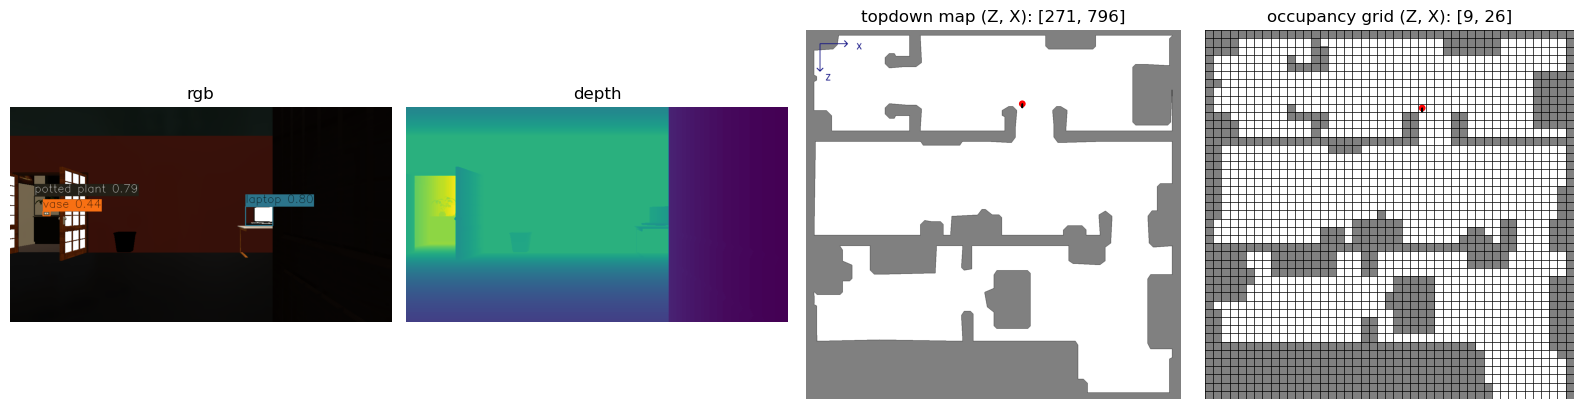


Target object <laptop> found after 183 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 183
Travelled distance: 43.63 m
Computed location error: 0.227 m
Episode reward: -0.83


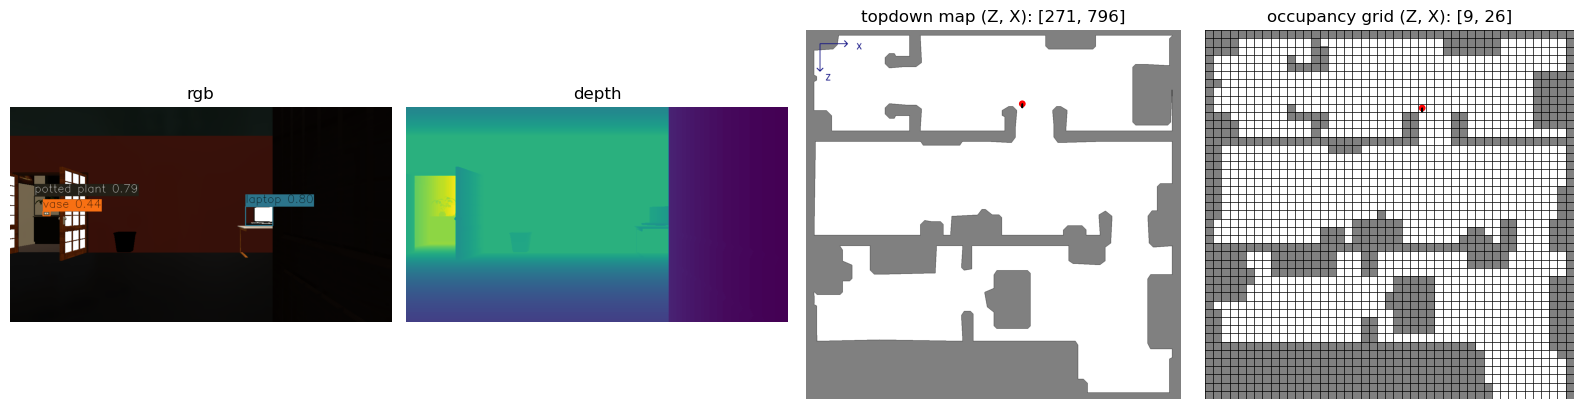


Target object <laptop> found after 15 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 15
Travelled distance: 3.36 m
Computed location error: 0.200 m
Episode reward: 0.85


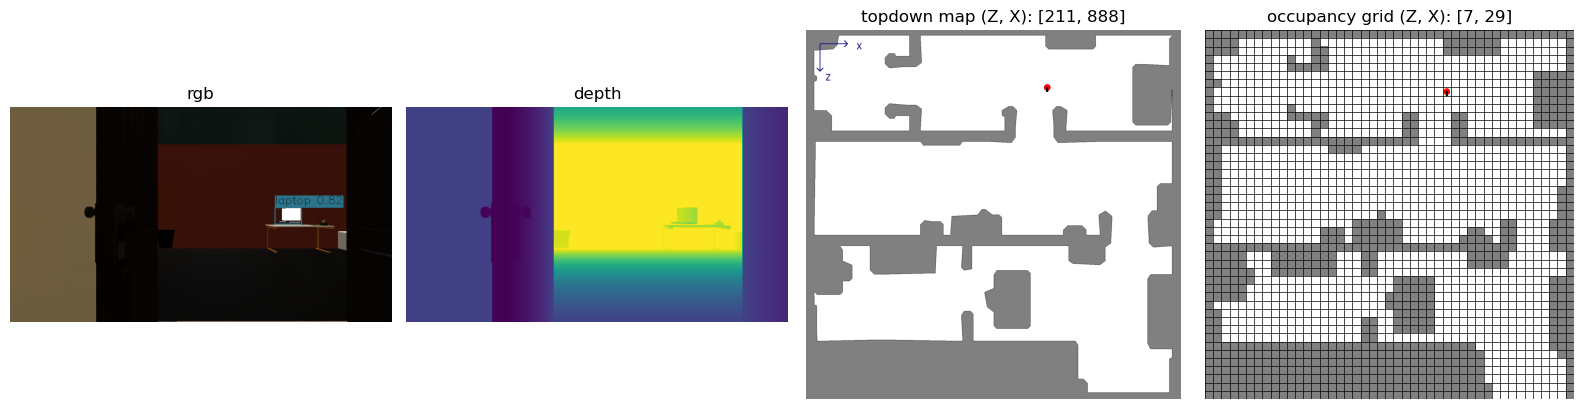


Target object <laptop> found after 6 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 6
Travelled distance: 0.92 m
Computed location error: 0.200 m
Episode reward: 0.94


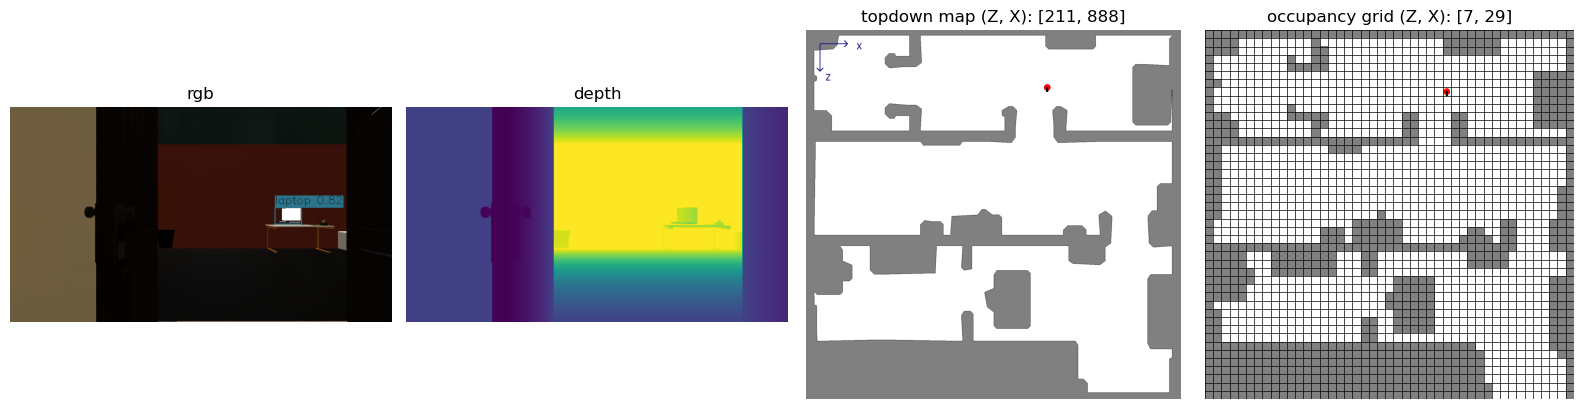


Target object <laptop> found after 171 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 171
Travelled distance: 39.95 m
Computed location error: 0.227 m
Episode reward: -0.71


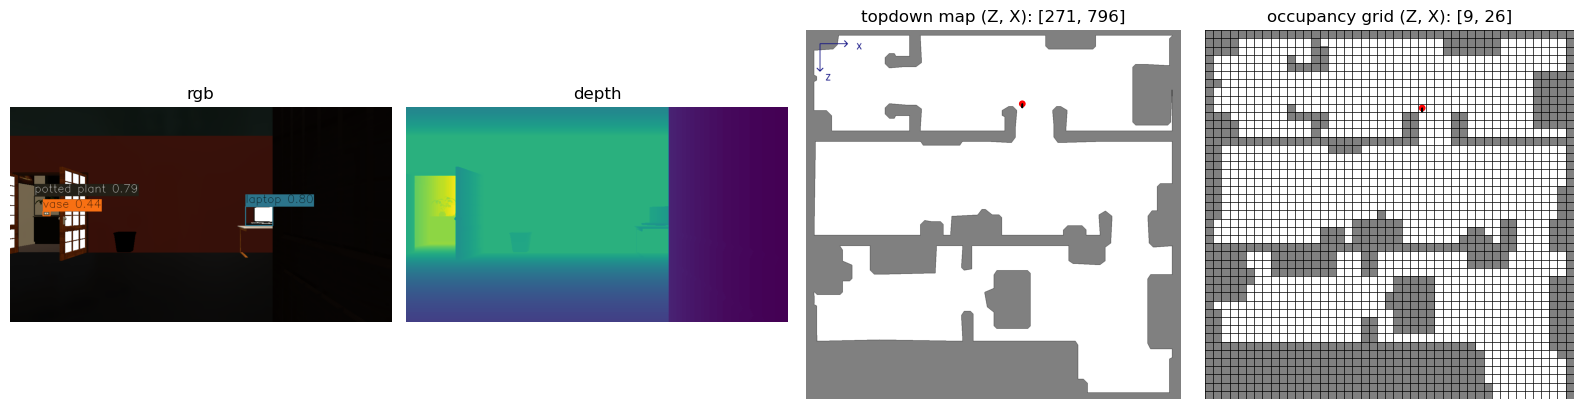


Target object <laptop> found after 197 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 197
Travelled distance: 45.47 m
Computed location error: 0.227 m
Episode reward: -0.97


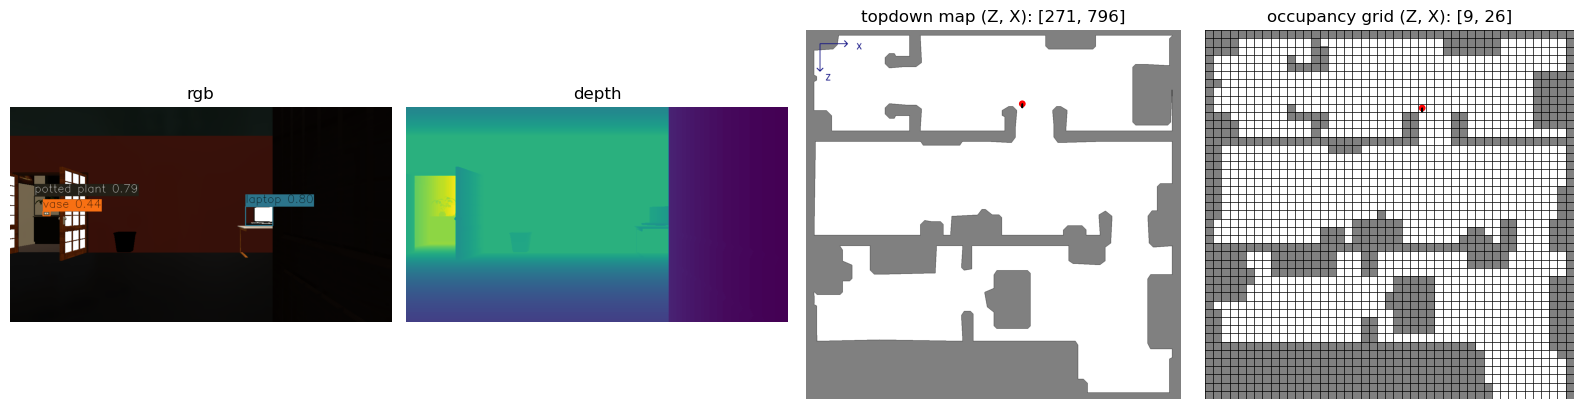


Target object <laptop> found after 80 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 80
Travelled distance: 17.66 m
Computed location error: 0.200 m
Episode reward: 0.20


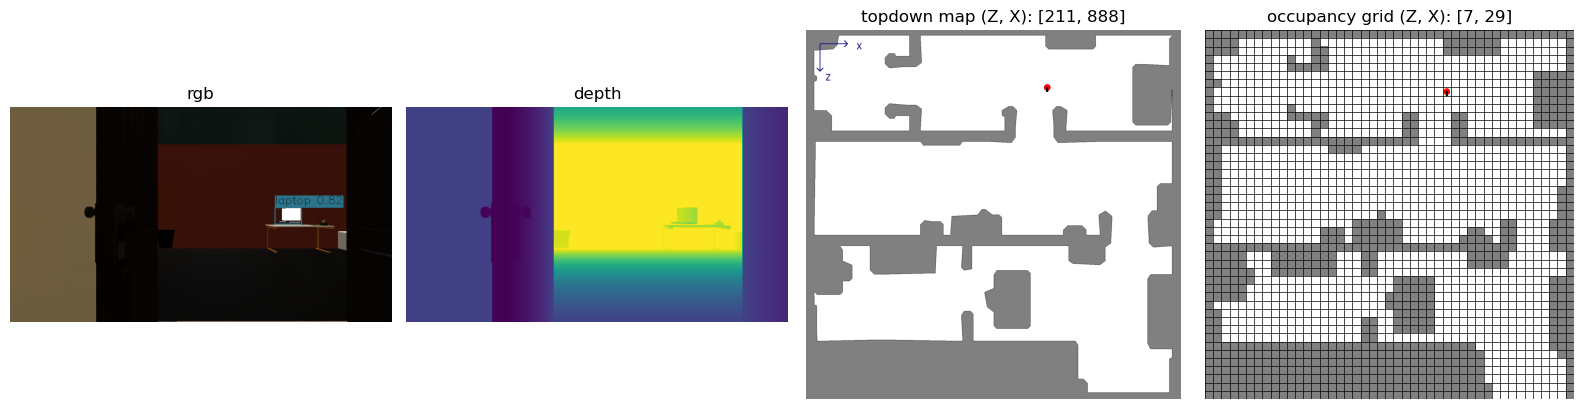


Target object <laptop> found after 199 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 199
Travelled distance: 45.43 m
Computed location error: 0.227 m
Episode reward: -0.99


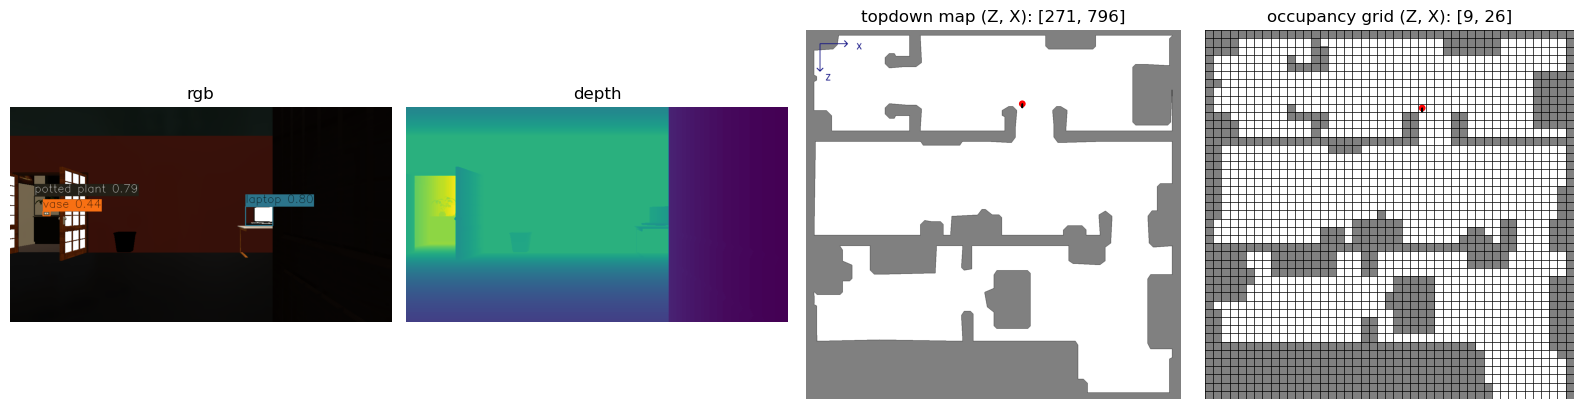


Target object <laptop> found after 10 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 10
Travelled distance: 2.44 m
Computed location error: 0.202 m
Episode reward: 0.90


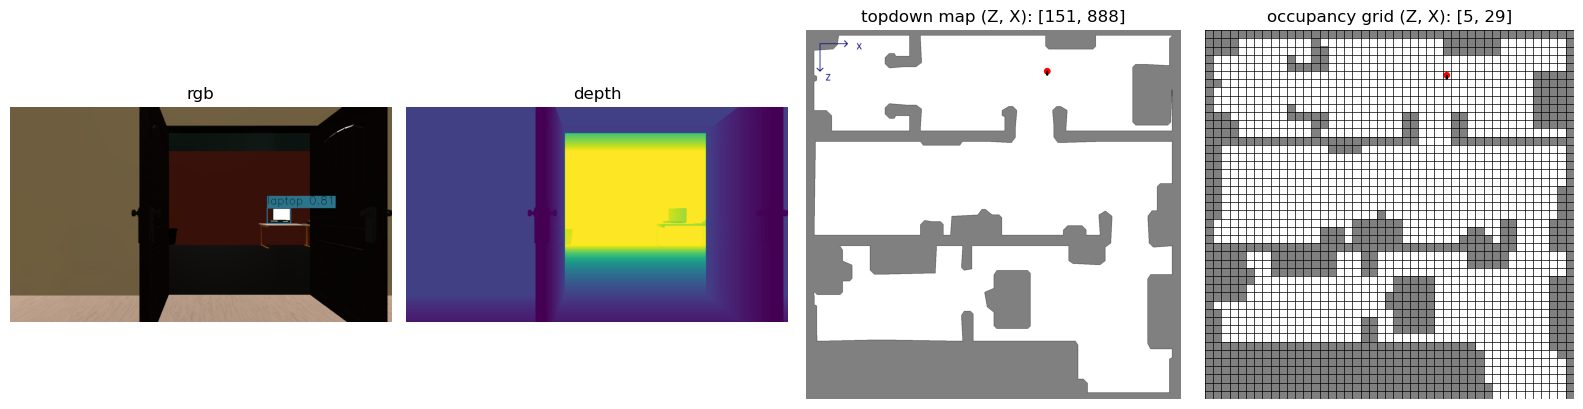


Target object <laptop> found after 185 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 185
Travelled distance: 43.66 m
Computed location error: 0.200 m
Episode reward: -0.85


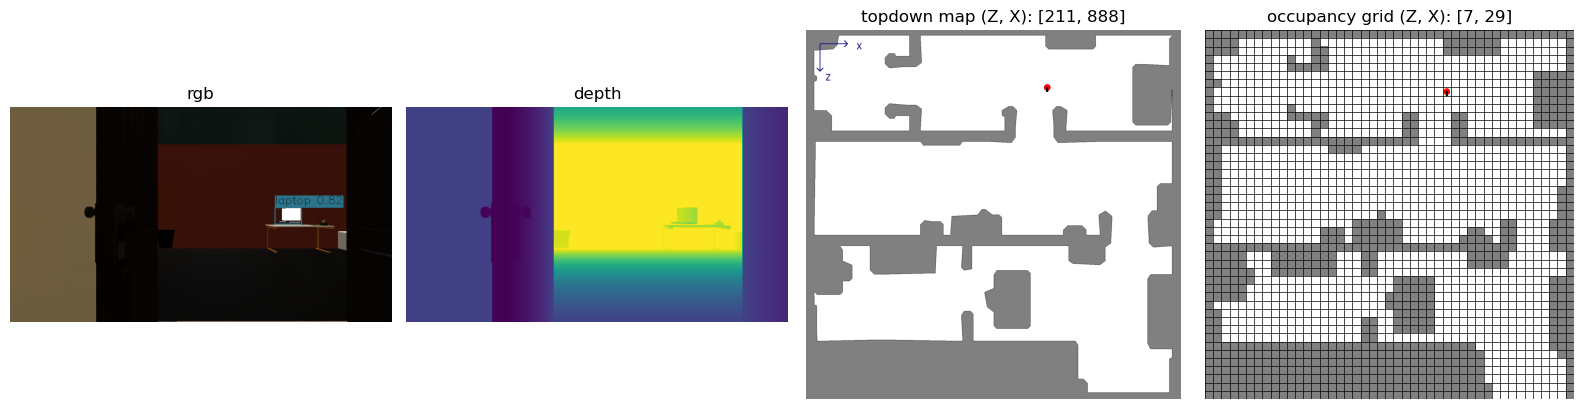


Target object <laptop> found after 166 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 166
Travelled distance: 38.44 m
Computed location error: 0.200 m
Episode reward: -0.66


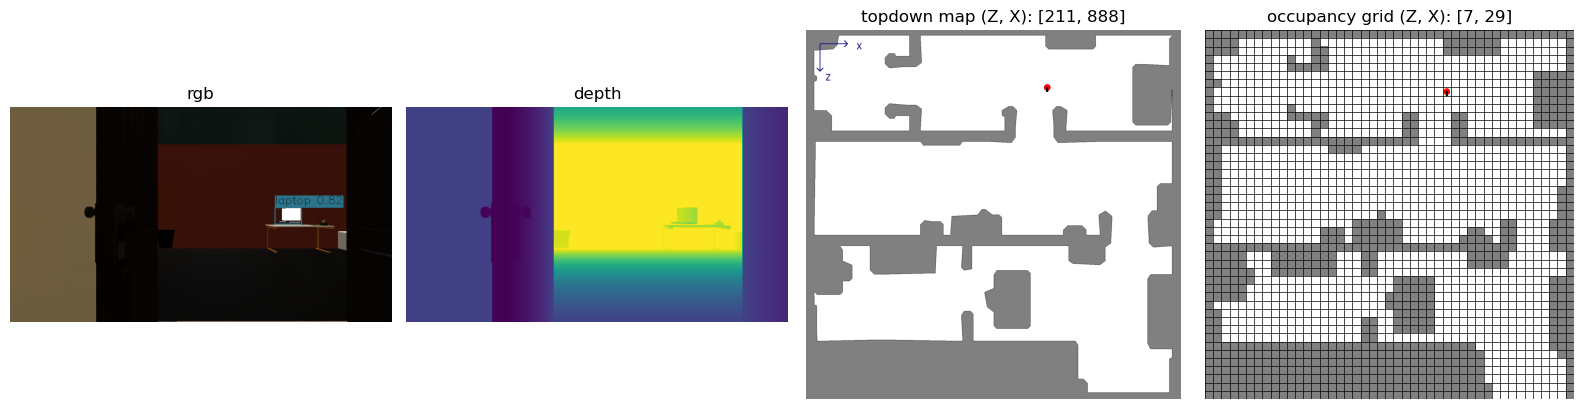


Target object <laptop> found after 160 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 160
Travelled distance: 36.92 m
Computed location error: 0.200 m
Episode reward: -0.60


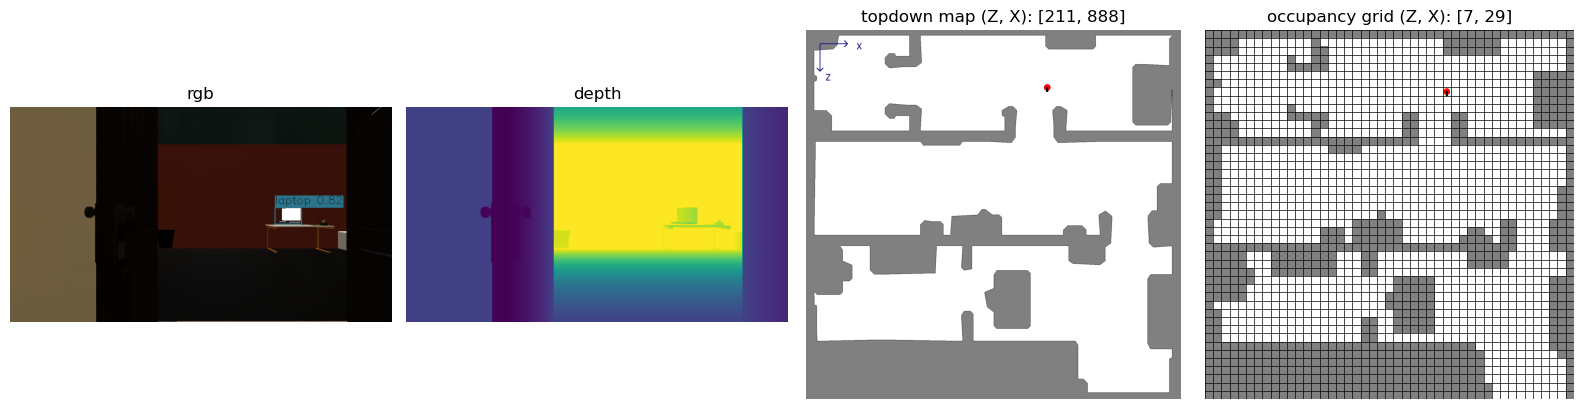

In [9]:
# Main training loop
for index, (GRID_POSITION, AGENT_YAW) in enumerate(zip(starting_grid_positions, starting_orientations)):

    target_grid_position = None
    
    # Metrics init
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")
    episode_reward = 0.0

    # Get epsilon for exploration
    epsilon = 0.1

    # Reset belief map
    belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

    # Reset cluster centers 
    num_clusters = simtools.num_cluster_centers(num_free_cells, max_clusters=num_free_cells)

    # Init agent state
    agent = sim.initialize_agent(sim_settings["default_agent"])

    # Sample a random position (within the possible ones)
    grid_position = GRID_POSITION
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]

    # Sample a random yaw rotation
    agent_yaw = AGENT_YAW
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Set agent state
    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Set observations
    state = dqn_v2.build_fullmap_obs(
        np.array(np.array(belief_map, dtype=np.float32)), 
        TARGET_OBJECT_CLASS_ID, 
        grid_binary_map, 
        tuple(grid_position), 
        NUM_CLASSES+1
    )

    # Plot
    # simtools.display_topdown_maps_with_clusters(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, cluster_map, cluster_centers)

    # Run episode
    while not target_found and num_actions < MAX_ITER and num_clusters <= num_free_cells:

        # Compute clusters
        cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
        cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
        cluster_centers_copy = cluster_centers.copy()

        # Compute valid actions and mask
        mask = np.zeros(num_free_cells, dtype=np.float32)
        for cluster_center in cluster_centers:
            idx = grid_free_cells.index(cluster_center)
            mask[idx] = 1.0

        while not target_found and num_actions < MAX_ITER and mask.sum() > 0:

            # Reset reward
            reward = 0.0

            # Select action using epsilon-greedy 
            q_action = dqn_v2.select_action(policy_net, state, mask, epsilon)
            cluster_center = grid_free_cells[q_action]

            # Select next valid mask (after taking the action)
            next_mask = mask.copy()
            next_mask[q_action] = 0.0  # Remove the selected cluster center from the next valid mask

            # # Print action to debug
            # print(f"\nCurrent position: {grid_position}")
            # print(f"Cluster center selected: {cluster_center}.")

            # Compute path to cluster center
            _, path = simtools.compute_path(grid_position, cluster_center, grid_free_cells)

            # Move through the path
            while (path) and (num_actions < MAX_ITER) and (not target_found):
                
                # Compute actions to move to next path cell
                action_list = simtools.compute_relative_actions(grid_position, agent_yaw, path[0], ACTIONS)

                # Perform the rotation action, if needed
                for action in action_list:

                    # Perform action
                    grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                    idx = grid_free_cells.index(grid_position)
                    map_position, world_position = map_free_cells[idx], world_free_coords[idx]
                    agent_positions = (map_position, grid_position)
                    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

                    # Update metrics
                    num_actions += 1
                    travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

                    # Update reward
                    reward -= 0.01  # Small step penalty to encourage efficiency

                    # Update agent state
                    agent_state.position = world_position
                    agent_state.rotation = agent_quart
                    agent.set_state(agent_state)

                    # Get observations
                    obs = sim.get_sensor_observations(0)
                    rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                    # YOLO Prediction
                    results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                    detections = simtools.parse_yolo_detections(results)
                    simtools.merge_rgb_yolo_outputs(rgb, detections)
                    target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
                    
                    # Initialize processed cells
                    processed_cells = []

                    # Process the observations
                    for det in detections:
                        box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                        scale = myutils.compute_bbox_scale(box, rgb)

                        # Center of bbox and depth value
                        center_x, center_y = simtools.get_box_center(box)
                        depth_value = depth[center_y, center_x]

                        # Project to real world, grid and map coords
                        camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                        object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                        object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                        # Check if projected cell is outside free grid cells
                        if object_grid_position in grid_free_cells:
                            object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                        # Add this cell to processed cells
                        if tuple(object_grid_position) not in processed_cells:
                            processed_cells.append(tuple(object_grid_position))

                        # Likelihood vector: likelihood of each class (Rule 1)
                        likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                        # Kaplan Update to the belief map in that cell
                        grid_x, grid_y = object_grid_position
                        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                    # Compute every theoretically visible occupied cell
                    rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
                    visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
                
                    # Go through every visible occupied cell and update the belief map
                    for cell in visible_occ_cells:
                        if tuple(cell) not in processed_cells:

                            # Compute distance to the cell
                            grid_x, grid_y = cell
                            distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                            # Compute the likelihood vector for the cell (Rule 2)
                            likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                            # Kaplan update to the belief map in that cell
                            belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)
                    
                    # Check if the target object was found in the belief map
                    if not target_found:
                        target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)

                    # Compute the target location if it was found
                    if target_found:
                        if target_grid_position is None: # Not found in the belief map
                            # Real world position
                            center_x, center_y = simtools.get_box_center(target_bbox)
                            depth_value = depth[center_y, center_x]
                            target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)
                        else:
                            # Real world position from grid position
                            target_location = world_coords[grid_cells.index(target_grid_position)]

                    # Evaluating correctness of the target detection
                    if target_found:
                        # Location error
                        location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

                        # Compare with threshold
                        if location_error > LOCATION_ERROR_THRESHOLD:
                            target_found = False
                        else:
                            reward += 1.0  # Positive reward for finding the target
                            break

                # Check if target was found
                if target_found: break

                # Remove the path cell
                path.pop(0)

            # When in cluster center, rotate 3 times to get the full 360 degrees view
            entropy_map = simtools.compute_entropy_map(belief_map, grid_map)
            # simtools.display_sim_observations(rgb, depth)
            # simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, cluster_centers_copy, agent_positions, agent_radius, agent_yaw)
            for i in range(3):
                # Check if target was found
                if target_found: break

                grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Update metrics
                num_actions += 1

                # Update reward
                reward -= 0.01  # Small step penalty to encourage efficiency

                # Get observations
                observations = sim.get_sensor_observations(0)
                rgb = observations["color_sensor"]
                depth = observations["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                detections = simtools.parse_yolo_detections(results)
                simtools.merge_rgb_yolo_outputs(rgb, detections)
                target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

                # Initialize processed cells
                processed_cells = []

                # Process the observations
                for det in detections:
                    box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                    scale = myutils.compute_bbox_scale(box, rgb)

                    # Center of bbox and depth value
                    center_x, center_y = simtools.get_box_center(box)
                    depth_value = depth[center_y, center_x]

                    # Project to real world, grid and map coords
                    camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                    object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                    object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                    # Check if projected cell is outside free grid cells
                    if object_grid_position in grid_free_cells:
                        object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                    # Add this cell to processed cells
                    if tuple(object_grid_position) not in processed_cells:
                        processed_cells.append(tuple(object_grid_position))

                    # Likelihood vector: likelihood of each class (Rule 1)
                    likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                    # Kaplan Update to the belief map in that cell
                    grid_x, grid_y = object_grid_position
                    belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                # Compute every theoretically visible occupied cell
                rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
                visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)

                # Go through every visible occupied cell and update the belief map
                for cell in visible_occ_cells:
                    if tuple(cell) not in processed_cells:

                        # Compute distance to the cell
                        grid_x, grid_y = cell
                        distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                        # Compute the likelihood vector for the cell (Rule 2)
                        likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                        # Kaplan update to the belief map in that cell
                        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                if not target_found:
                    target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)

                # Compute the target location if it was found
                if target_found:
                    if target_grid_position is None: # Not found in the belief map
                        # Real world position
                        center_x, center_y = simtools.get_box_center(target_bbox)
                        depth_value = depth[center_y, center_x]
                        target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)
                    else:
                        # Real world position from grid position
                        target_location = world_coords[grid_cells.index(target_grid_position)]

                # Evaluating correctness of the target detection
                if target_found:
                    # Location error
                    location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

                    # Compare with threshold
                    if location_error > LOCATION_ERROR_THRESHOLD:
                        target_found = False
                    else:
                        reward += 1.0  # Positive reward for finding the target
                        break

            # Compute next observation
            next_state = dqn_v2.build_fullmap_obs(
                np.array(np.array(belief_map, dtype=np.float32)), 
                TARGET_OBJECT_CLASS_ID, 
                grid_binary_map, 
                tuple(grid_position), 
                NUM_CLASSES+1
            )

            # Is it done?
            done = target_found

            # print(f"Action: {action}, Reward: {reward:.2f}, Done: {done}")
            # print(f"Clusters before: {mask.sum()}, after: {next_mask.sum()}")

            state = next_state
            mask = next_mask
            episode_reward += reward

        # Update clusters
        num_clusters *= 2  # Double the number of clusters


    # Display simulation result and metrics
    if target_found:
        print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
        print(f"Found location: {target_location}")
    else:
        print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    print(f"Number of actions: {num_actions}")
    print(f"Travelled distance: {travelled_distance:.2f} m")
    print(f"Computed location error: {location_error:.3f} m")

    print(f"Episode reward: {episode_reward:.2f}")
    simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

    # Append metrics
    episode_lengths.append(num_actions)
    episode_location_errors.append(location_error)
    episode_travelled_distances.append(travelled_distance)
    episode_success_flags.append(target_found)
    episode_rewards.append(episode_reward)

In [10]:
import numpy as np

# Pre-process
num_actions_epochs = np.array(episode_lengths)
travelled_distance_epochs = np.array(episode_travelled_distances)
success_epochs = np.array(episode_success_flags)
location_error_epochs = np.array(episode_location_errors)

# Counting
num_total_epochs = len(num_actions_epochs)
num_success_epochs = np.sum(success_epochs)

# Metrics on all runs
total_avg_num_actions = np.sum(num_actions_epochs) / num_total_epochs
total_avg_tavelled_distance = np.sum(travelled_distance_epochs) / num_total_epochs
success_rate = num_success_epochs / num_total_epochs * 100

# Metrics on successful runs
success_avg_travelled_distance = np.sum(travelled_distance_epochs[success_epochs]) / num_success_epochs
success_avg_num_actions = np.sum(num_actions_epochs[success_epochs]) / num_success_epochs
success_avg_location_error = np.sum(location_error_epochs[success_epochs]) / num_success_epochs

#Print final metrics
print("\n\nMETRICS:\n")
print(f"Total number of epochs: {num_total_epochs}")
print(f"Number of successful epochs: {num_success_epochs}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Average number of actions (epochs): {total_avg_num_actions:.2f}")
print(f"Average travelled distance (epochs): {total_avg_tavelled_distance:.2f} m")
print(f"Average success rate (epochs): {success_rate:.2f}%")
print(f"\nAverage number of actions (successful epochs): {success_avg_num_actions:.2f}")
print(f"Average travelled distance (successful epochs): {success_avg_travelled_distance:.2f} m")
print(f"Average location error (successful epochs): {success_avg_location_error:.3f} m")

# Number of actions max, min and std
print(f"\nMax number of actions (epochs): {np.max(num_actions_epochs)}")
print(f"Min number of actions (epochs): {np.min(num_actions_epochs)}")
print(f"Std number of actions (epochs): {np.std(num_actions_epochs)}")    



METRICS:

Total number of epochs: 100
Number of successful epochs: 100
Success rate: 100.00%
Average number of actions (epochs): 108.15
Average travelled distance (epochs): 25.55 m
Average success rate (epochs): 100.00%

Average number of actions (successful epochs): 108.15
Average travelled distance (successful epochs): 25.55 m
Average location error (successful epochs): 0.212 m

Max number of actions (epochs): 243
Min number of actions (epochs): 1
Std number of actions (epochs): 79.19739579051826


In [11]:
metrics_file = 'results/metrics.json'

# Load existing metrics if the file exists, otherwise start with an empty list
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
else:
    existing_metrics = []

# New metrics entry (convert numpy types to native Python types)
def to_python_type(val):
    if hasattr(val, "item"):
        return val.item()
    return val

new_metrics = {
    "simulation_index": to_python_type(INDEX),
    "scene": SCENE,
    "target_object": TARGET_OBJECT,
    "search_method": METHOD,
    "confidence_threshold": to_python_type(CONFIDENCE_THRESHOLD),
    "max_iter_coefficient": to_python_type(MAX_ITER_COEF),
    "location_error_threshold": to_python_type(LOCATION_ERROR_THRESHOLD),
    "pseudo_count_threshold": to_python_type(PSEUDO_COUNT_THRESHOLD),
    "num_total_epochs": to_python_type(num_total_epochs),
    "num_success_epochs": to_python_type(num_success_epochs),
    "success_rate": to_python_type(success_rate),
    "success_avg_num_actions": to_python_type(success_avg_num_actions),
    "success_avg_travelled_distance": to_python_type(success_avg_travelled_distance),
    "success_avg_location_error": to_python_type(success_avg_location_error),
}

# Check for duplicate (by simulation_index and search_method)
duplicate_exists = any(
    entry["simulation_index"] == new_metrics["simulation_index"] and
    entry["search_method"] == new_metrics["search_method"] 
    for entry in existing_metrics
)

if not duplicate_exists:
    existing_metrics.append(new_metrics)
else:
    print(f"Metrics for simulation_index {new_metrics['simulation_index']} and search_method '{new_metrics['search_method']}' already exist. Skipping append.")

# Save updated metrics list
with open(metrics_file, 'w') as f:
    json.dump(existing_metrics, f, indent=4)

print(f"\nMetrics saved to {metrics_file}")


Metrics saved to results/metrics.json


In [12]:
sim.close()  # Close the simulator